# CMS Statistics

This file is meant for actually comparing prices between the extracted hospitals (statistical tests). Per methodology of the paper:
- 8 locations
- 5 shoppable services

***


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
import re
from pathlib import Path
import json
import seaborn as sns
from scipy.stats import kruskal, ttest_1samp, wilcoxon
from scipy.stats import levene
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import warnings
warnings.filterwarnings('ignore')


# =========================================================================== 
# 0. CONFIG / ASSUMPTIONS
# =========================================================================== 

# Edit these to match your actual column names if different
COL_HOSPITAL   = "hospital_id"
COL_DESCRIPTION = "description"
COL_SERVICE    = "service_id"
COL_CODE  = "code"
COL_PRICE_TYPE = "type"
COL_PAYER      = "payer_name"
COL_PLAN        = "plan_name"
COL_PRICE_EST      = "estimated_amount"
COL_STAND_PRCT = "standard_charge_percentage"
COL_MIN_PRICE  = "standard_charge_min"
COL_MAX_PRICE  = "standard_charge_max"
COL_GROSS_PRICE = "standard_charge_gross"
COL_DISCOUNTED_CASH = "standard_charge_discounted_cash"
COL_SETTING   = "setting"

# ===========================================================================
COLS_TO_DROP_NA = [COL_PAYER, COL_PLAN]
COLS_TO_DROP = ['code_1', 'code_1_type', 'rc_code',
    'code_4', 'code_4_type', 'billing_class', 'drug_unit_of_measurement',
    'drug_type_of_measurement', 'modifiers',
    'standard_charge_negotiated_dollar',
    'standard_charge_negotiated_percentage',
    'standard_charge_negotiated_algorithm', 'standard_charge_methodology',
    'additional_generic_notes', 
    'standard_charge_discounted_cash', 
    'standard_charge|discounted_cash', 'standard_charge|negotiated_dollar',
    'standard_charge|negotiated_percentage',
    'standard_charge|negotiated_algorithm', 'standard_charge|methodology'
]


In [108]:
# =========================================================================== 
# 1. DATA PREPROCESSING / CLEANING / CONCAT
# =========================================================================== 
# While the data has been cleaned in the other notebook, this was for .html display
# so we need to clean it again for analysis
# Lets load the data from the .json files, then clean those up further here (Payer name standardization, missing values, etc.)

# Set notebook directory as current working directory
notebook_dir = Path.cwd()

# If the current directory is not the CLEAR folder, search upward for a directory named "CLEAR".
# This avoids accidentally appending "CLEAR" twice (which caused the FileNotFoundError).
if notebook_dir.name != "CLEAR":
    found_clear = None
    for p in [notebook_dir] + list(notebook_dir.parents):
        if p.name == "CLEAR":
            found_clear = p
            break
    if found_clear:
        notebook_dir = found_clear
    else:
        # fallback: use __file__ parent if available (script execution), else keep cwd
        notebook_dir = Path(__file__).parent if '__file__' in globals() else notebook_dir

# Navigate to json data directory using relative path from CLEAR folder
json_data_dir = notebook_dir / "docs" / "data" / "prices"

# Verify the directory exists
if not json_data_dir.exists():
    raise FileNotFoundError(f"Directory not found: {json_data_dir}\nPlease ensure the 'docs/data/prices' folder exists in the CLEAR directory.")

# Grab list of subfolders (each STATE [NC, FL, etc.] has its own folder)
state_folders = [f for f in json_data_dir.iterdir() if f.is_dir()]
print(f"Found {len(state_folders)} state folders with JSON data.")

# Grab list of all .json files in those subfolders
json_file_paths = []
for state_folder in state_folders:
    json_files = [f for f in state_folder.iterdir() if f.suffix == ".json"]
    json_file_paths.extend(json_files)

print(f"Found {len(json_file_paths)} JSON files in all state folders.")
    
# Preload the identifiers from docs/data/hospitals.csv which maps the json filename to hospital name
hospitals_df = pd.read_csv(notebook_dir  / "docs" / "data" / "hospitals.csv")
print(f"Loaded {len(hospitals_df)} hospital identifiers from hospitals.csv.")

def load_and_clean_data(file_paths: list[str]): # -> pd.DataFrame:
    """Load and clean CMS pricing data from multiple newline-delimited JSON files."""
    df_list = []
    for file_path in file_paths:
        # Load newline-delimited JSON (each line is a separate JSON object)
        data = []
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if line:  # Skip empty lines
                    try:
                        data.append(json.loads(line))
                    except json.JSONDecodeError as e:
                        print(f"Warning: Skipping invalid JSON line in {file_path.name}: {e}")
        
        print(f"Loaded {len(data)} records from {file_path.name}")  

        # Normalize JSON data to flat table
        df = pd.json_normalize(data)

       

        # Use the json filename (without .json) as the hospital_id
        hospital_id = file_path.stem
        df[COL_HOSPITAL] = hospital_id  # Assign hospital_id to all rows in this dataframe
        
         # Duke column names are incorrectly parsed, fix here for now
        if file_path.name == "cwmo7l4t.json":
            df.rename(columns={
                'standard_charge|percentage': COL_STAND_PRCT,
                'standard_charge|min': COL_MIN_PRICE,
                'standard_charge|max': COL_MAX_PRICE,
                'standard_charge|discounted_cash': COL_DISCOUNTED_CASH,
                'standard_charge|gross': COL_GROSS_PRICE
            }, inplace=True)

        # Look up the hospital name and state from hospitals_df
        hospital_name = hospitals_df.loc[hospitals_df['id'] == hospital_id, 'name'].values
        hospital_state = hospitals_df.loc[hospitals_df['id'] == hospital_id, 'state'].values
        
        if len(hospital_name) > 0:
            df['hospital_name'] = hospital_name[0]
            df['state'] = hospital_state[0]
        else:
            df['hospital_name'] = None
            df['state'] = None

        df_list.append(df)
        print(f"Appended data from {file_path.name}, current combined length: {sum(len(d) for d in df_list)}")
    combined_df = pd.concat(df_list, ignore_index=True)
    print(f"Combined dataframe length before cleaning: {len(combined_df)}")

    # Clean missing values in key columns
    print("Cleaning missing values in key columns...")
    
    for col in COLS_TO_DROP_NA:
        initial_len = len(combined_df)
        combined_df.dropna(subset=[col], inplace=True)
        final_len = len(combined_df)
        print(f"Dropped {initial_len - final_len} rows due to missing values in {col}.")

    # Drop unnecessary columns
    combined_df.drop(columns=COLS_TO_DROP, inplace=True, errors='ignore')   
    print("Dropped unnecessary columns.")

    # Add fallback price calculation: use average of min and max when estimated_amount is null
    print("Adding fallback price calculation for missing estimated_amount values...")
    mask_missing_est = combined_df[COL_PRICE_EST].isna()
    has_min = combined_df[COL_MIN_PRICE].notna()
    has_max = combined_df[COL_MAX_PRICE].notna()
    
    # Calculate fallback: average of min and max
    fallback_price = (pd.to_numeric(combined_df[COL_MIN_PRICE], errors='coerce') + 
                      pd.to_numeric(combined_df[COL_MAX_PRICE], errors='coerce')) / 2
    
    # Apply fallback where estimated_amount is missing but we have min/max
    can_fill = mask_missing_est & has_min & has_max
    combined_df.loc[can_fill, COL_PRICE_EST] = fallback_price[can_fill]
    
    filled_count = can_fill.sum()
    print(f"Filled {filled_count} missing estimated_amount values using average of min/max standard charges.")

    print(f"Combined dataframe length after cleaning: {len(combined_df)}")
    return combined_df

# ===========================================================================

df = load_and_clean_data(json_file_paths)

# ===========================================================================
def _norm_text(x: str): # -> str:
    """Uppercase, strip punctuation, collapse whitespace."""
    if pd.isna(x):
        return ""
    x = str(x).upper()
    # replace non-alphanumeric with space
    x = re.sub(r"[^A-Z0-9]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def standardize_payer(raw: str): # -> str:
    n = _norm_text(raw)
    if n == "":
        return "UNKNOWN"

    # --- big national payers / systems ---
    if "AETNA" in n:
        return "AETNA"

    if "CIGNA" in n:
        return "CIGNA"

    if "HUMANA" in n:
        return "HUMANA"

    if "MEDCOST" in n:
        return "MEDCOST"

    # UNITED / UHC family
    if "UNITED" in n or "UNITEDHEALTH" in n or "UHC" in n:
        return "UNITEDHEALTHCARE"

    # BCBS family
    if "BLUE CROSS BLUE SHIELD OF NORTH CAROLINA" in n:
        return "BCBS NC"
    if "BLUE CROSS BLUE SHIELD" in n or "BCBS" in n:
        return "BCBS"

    # WellCare
    if "WELLCARE" in n:
        return "WELLCARE"

    # Alignment
    if "ALIGNMENT" in n:
        return "ALIGNMENT HEALTH"

    # Molina
    if "MOLINA" in n:
        return "MOLINA HEALTHCARE"

    # Ambetter
    if "AMBETTER" in n:
        return "AMBETTER"

    # Amerihealth
    if "AMERIHEALTH" in n:
        return "AMERIHEALTH"

    # Carolina Complete / Healthy Blue (NC Medicaid MCOs)
    if "CAROLINA COMPLETE" in n:
        return "CAROLINA COMPLETE HEALTH"
    if "HEALTHY BLUE" in n:
        return "HEALTHY BLUE"

    # TRICARE
    if "TRICARE" in n:
        return "TRICARE"

    # VA Medicaid
    if "VA MEDICAID" in n:
        return "VA MEDICAID"

    # Kaiser
    if "KAISER" in n:
        return "KAISER PERMANENTE"

    # Anthem / CareFirst / Sentara / Magellan
    if "ANTHEM" in n:
        return "ANTHEM"
    if "CAREFIRST" in n:
        return "CAREFIRST"
    if "SENTARA" in n:
        return "SENTARA HEALTH"
    if "MAGELLAN" in n:
        return "MAGELLAN HEALTHCARE"

    # Oxford / Golden Rule / UMR handled via UHC above, but keep as separate if needed
    if "OXFORD HEALTH" in n:
        return "OXFORD HEALTH PLANS"
    if "GOLDEN RULE" in n:
        return "GOLDEN RULE INSURANCE"

    # Multiplan / PHCS / First Health
    if "MULTIPLAN" in n:
        return "MULTIPLAN"
    if "PHCS" in n or "PRIVATE HEALTHCARE SYSTEM" in n:
        return "PHCS"
    if "FIRST HEALTH" in n:
        return "FIRST HEALTH NETWORK"

    # Regional/other from your list
    if "CRESCENT" in n:
        return "CRESCENT"
    if "TROY" in n:
        return "TROY MEDICARE"
    if "HEALTH TEAM ADVANTAGE" in n:
        return "HEALTH TEAM ADVANTAGE"
    if "LONGEVITY" in n:
        return "LONGEVITY HEALTH PLAN"
    if "OSCAR" in n:
        return "OSCAR HEALTH"
    if "NALC HEALTH BENEFIT" in n:
        return "NALC HEALTH BENEFIT PLAN"
    if "MAIL HANDLERS" in n:
        return "MAIL HANDLERS BENEFIT PLAN"
    if "ABSOLUTE TOTAL CARE" in n:
        return "ABSOLUTE TOTAL CARE"
    if "CLOVER HEALTH" in n:
        return "CLOVER HEALTH"
    if "EMPLOYERS HEALTH NETWORK" in n:
        return "EMPLOYERS HEALTH NETWORK"
    if "DUKE PLUS" in n:
        return "DUKE PLUS"
    if "OPTUM" in n:
        return "OPTUM HEALTH CARE SOLUTIONS"

    # Medicaid generic / managed Medicaid
    if "MEDICAID" in n:
        return "MEDICAID / MANAGED MEDICAID"

    # Catch some misc from your list
    if "RYAN WHITE" in n:
        return "RYAN WHITE"
    if "LIBERTY" in n:
        return "LIBERTY"
    if "PRUITT" in n:
        return "PRUITT"
    if "INTERLINK" in n:
        return "INTERLINK"
    if "LIFETRAC" in n:
        return "LIFETRAC"
    if "INNOVATION" in n:
        return "INNOVATION"

    # Generic fallbacks
    if "HEALTH PLAN" in n or "HEALTHCARE" in n or "HEALTH" in n:
        return n  # leave as normalized name but standardized format

    return n   # default: normalized text

def standardize_plan_name(raw: str): # -> str:
    n = _norm_text(raw)
    if n == "":
        return "UNKNOWN"

    # flags
    has_hmo      = "HMO" in n
    has_ppo      = "PPO" in n
    has_pos      = "POS" in n
    has_medicare = "MEDICARE" in n
    has_medicaid = "MEDICAID" in n
    has_exch     = "EXCHANGE" in n or "MARKETPLACE" in n or "AMBETTER EXCHANGE" in n
    has_adv      = "ADVANTAGE" in n

    # --- explicit special combined strings ---
    if "MEDICARE MEDICAID MANAGED CARE PLAN" in n:
        return "DUAL-ELIGIBLE MANAGED CARE"

    # after normalization inside standardize_plan_name

# collapse carrier-like plan labels to COMMERCIAL
    if n in {
        "ALLIANCE", "AMERIHEALTH", "WELLCARE", "COVENTRY CARELINK",
        "SUREST 110715126",
        "UNITEDHEALTHONE OXFORD HEALTH 110715122",
        "UNITEDHEALTHONE GOLDEN RULE 110715123",
        "DUKE PLUS",
        "OXFORD HEALTH PLANS 100128501",
        "GOLDEN RULE INSURANCE COMPANY 100120901"
    }:
        return "COMMERCIAL"

    # SELECT, OPTIONS, NONOPTIONS -> COMMERCIAL
    if n == "SELECT":
        return "COMMERCIAL"
    if n in {"OPTIONS", "NONOPTIONS"}:
        return "COMMERCIAL"


    # --- Medicare / Medicare Advantage ---
    if "MEDICARE MANAGED CARE PLAN" in n:
        return "MEDICARE ADVANTAGE"
    if "HEALTHSPRING MEDICARE MANAGED CARE PLAN" in n:
        return "MEDICARE ADVANTAGE"
    if "MEDICARE ADVANTAGE" in n:
        return "MEDICARE ADVANTAGE"
    if has_medicare and has_adv:
        return "MEDICARE ADVANTAGE"
    if "PFFS MEDICARE" in n:
        return "MEDICARE ADVANTAGE"
    if "HMO MEDICARE" in n or "MEDICARE HMO" in n:
        return "MEDICARE ADVANTAGE HMO"
    if has_medicare:
        return "MEDICARE"

    # --- Medicaid / Managed Medicaid ---
    if "BETTER HEALTH MEDICAID" in n:
        return "MEDICAID MANAGED CARE"
    if "MANAGED MEDICAID" in n or "MEDICAID MANAGED CARE PLAN" in n:
        return "MEDICAID MANAGED CARE"
    if "MEDICAID ADVANTAGE" in n:
        return "MEDICAID MANAGED CARE"
    if has_medicaid:
        return "MEDICAID"

    # --- Exchange / Marketplace plans ---
    if has_exch or "MARKETPLACE EXCHANGE" in n:
        return "EXCHANGE"
    if "AMBETTER EXCHANGE" in n:
        return "EXCHANGE"
    if "BLUECHOICE EXCHANGE" in n or "BLUEESSENTIALS EXCHANGE" in n \
       or "LOWCOUNTRY BLUE EXCHANGE" in n:
        return "EXCHANGE"
    if "EXCHANGE HMO" in n:
        return "EXCHANGE HMO"
    if "EXCHANGE PPO" in n:
        return "EXCHANGE PPO"

    # --- Plan structure: HMO / PPO / HMO-PPO / POS ---
    # things like HMO_PPO, HMO_PPO_POS, HMO PPO
    if has_hmo and has_ppo:
        return "HMO/PPO"
    if has_hmo and not has_ppo:
        return "HMO"
    if has_ppo and not has_hmo:
        return "PPO"
    if has_pos and not (has_hmo or has_ppo):
        return "POS"

    # explicit strings that imply HMO/PPO but may not contain both tokens after normalization
    if "HMO PPO" in n:
        return "HMO/PPO"
    if "HMO PRIME" in n or "SMART HMO" in n or "BLUECHOICE HMO" in n \
       or n == "HMO":
        return "HMO"
    if "PREFERRED BLUE PPO" in n or "OPTIONS PPO" in n or n == "PPO":
        return "PPO"

    # --- Commercial / generic ---
    if "ALL COMMERCIAL PLANS" in n:
        return "COMMERCIAL"
    if "OTHER COMMERCIAL PLAN" in n or "STATE OTHER COMMERCIAL PLAN" in n:
        return "COMMERCIAL"
    if "COMMERCIAL INPATIENT" in n or "COMMERCIAL OUTPATIENT" in n:
        return "COMMERCIAL"
    if "COMMERCIAL" in n:
        return "COMMERCIAL"

    # New business variations -> still commercial
    if "NEW BUSINESS" in n:
        return "COMMERCIAL"

    # Whole Health / Alliance / Choice etc. (all basically commercial)
    if "WHOLE HEALTH" in n:
        return "COMMERCIAL"
    if "HEALTH ALLIANCE" in n:
        return "COMMERCIAL"
    if "CHOICE CARE" in n or "CHOICE POS" in n or "CHOICE" in n:
        return "COMMERCIAL CHOICE"

    # --- Government / employee / other ---
    if "GOVERNMENT" in n:
        return "GOVERNMENT"
    if "EMPLOYEE" in n:
        return "EMPLOYEE PLAN"

    # --- Self insured / fully insured ---
    if "SELF INSURED" in n:
        return "SELF INSURED"
    if "FULLY INSURED" in n:
        return "FULLY INSURED"

    # --- Transplant-specific ---
    if "TRANSPLANT MEDICARE MANAGED CARE PLAN" in n:
        return "MEDICARE TRANSPLANT"
    if "LIFESOURCE TRANSPLANT" in n:
        return "TRANSPLANT"
    if "TRANSPLANT" in n:
        return "TRANSPLANT"

    # --- Specific named buckets from your list ---
    if n in {"HEALTHY BLUE", "CAROLINA COMPLETE", "TRILLIUM", "PARTNERS", "VAYA"}:
        # NC Medicaid MCOs
        return "MEDICAID MANAGED CARE"

    if n in {"BLUE VALUE"}:
        return "COMMERCIAL"
    if n in {"GOLD PLUS HMO"}:
        return "MEDICARE ADVANTAGE HMO"
    if n in {"UNITED HEALTHCARE"}:
        return "COMMERCIAL"
    if n in {"AETNA WHOLE HEALTH SELF INSURED"}:
        return "SELF INSURED"
    if n.startswith("AETNA ") or n.startswith("CIGNA ") or n.startswith("UHC ") \
       or n.startswith("UNITED HEALTHCARE") or n.startswith("UNITEDHEALTHCARE") \
       or n.startswith("UMR "):
        # carrier-specific commercial variants
        return "COMMERCIAL"

    if "MAIL HANDLERS BENEFIT PLAN" in n or "NALC HEALTH BENEFIT PLAN" in n:
        return "GOVERNMENT"

    if "VA MEDICAID" in n:
        return "MEDICAID"

    if "HUMANA CHOICECARE NETWORK PPO" in n:
        return "PPO"

    # "Managed Care Plan" (without explicit Medicare/Medicaid)
    if "MANAGED CARE PLAN" in n:
        return "MANAGED CARE PLAN"

    # EXCLUDE flag
    if n == "EXCLUDE":
        return "EXCLUDE"

    # --- last-resort heuristics ---
    # If it still has HMO/PPO/POS tokens, assign those
    if "HMO" in n:
        return "HMO"
    if "PPO" in n:
        return "PPO"
    if "POS" in n:
        return "POS"

    # otherwise just return the normalized string
    return n


df[COL_PAYER] = df[COL_PAYER].apply(standardize_payer)
df[COL_PLAN] = df[COL_PLAN].apply(standardize_plan_name)

# ===========================================================================
# DROP EXTREME OUTLIERS
# ===========================================================================
# Filter out extreme outliers that are clearly erroneous or placeholder values
# (e.g., 999999999, values above $500,000, etc.)

print(f"\nDataframe length before outlier filtering: {len(df)}")

# Define price columns to check for outliers
price_columns = [COL_PRICE_EST, COL_MAX_PRICE, COL_MIN_PRICE, COL_GROSS_PRICE]

# Filter out extreme values for each price column
for col in price_columns:
    if col in df.columns:
        initial_len = len(df)
        # Remove rows where price > 500,000 or price is placeholder like 999999999
        df = df[~((df[col] > 500000) | (df[col] >= 999999999))].copy()
        filtered_count = initial_len - len(df)
        if filtered_count > 0:
            print(f"Filtered {filtered_count} rows with extreme values in {col}")

print(f"Dataframe length after outlier filtering: {len(df)}")


Found 4 state folders with JSON data.
Found 7 JSON files in all state folders.
Loaded 9 hospital identifiers from hospitals.csv.
Loaded 32401 records from 1r6ycd9n.json
Appended data from 1r6ycd9n.json, current combined length: 32401
Loaded 12288 records from 29a8pin7.json
Appended data from 29a8pin7.json, current combined length: 44689
Loaded 8114 records from 59ew6vnb.json
Appended data from 1r6ycd9n.json, current combined length: 32401
Loaded 12288 records from 29a8pin7.json
Appended data from 29a8pin7.json, current combined length: 44689
Loaded 8114 records from 59ew6vnb.json
Appended data from 59ew6vnb.json, current combined length: 52803
Loaded 6466 records from 89spvp3v.json
Appended data from 89spvp3v.json, current combined length: 59269
Appended data from 59ew6vnb.json, current combined length: 52803
Loaded 6466 records from 89spvp3v.json
Appended data from 89spvp3v.json, current combined length: 59269
Loaded 28443 records from cwmo7l4t.json
Appended data from cwmo7l4t.json, c

In [71]:
def compute_code_level_variation(df_top: pd.DataFrame,
                                 price_col: str = COL_PRICE_EST
                                ): # -> pd.DataFrame:
    """
    For each code × type × hospital, compute:
        mean, median, sd, IQR, min, max, count, CV
    for the specified price_col (e.g. estimated_amount, standard_charge_gross, etc.)
    """
    sub = df_top.copy()
    sub = sub[np.isfinite(sub[price_col])].copy()

    g = sub.groupby([COL_CODE, COL_PRICE_TYPE, COL_HOSPITAL], dropna=False)[price_col]

    stats = g.agg(
        mean   = "mean",
        median = "median",
        sd     = "std",
        q1     = lambda x: np.percentile(x, 25),
        q3     = lambda x: np.percentile(x, 75),
        count  = "count",
        min    = "min",
        max    = "max",
    ).reset_index()

    stats["iqr"] = stats["q3"] - stats["q1"]
    stats["cv"]  = stats["sd"] / stats["mean"]

    return stats


###############################################################################
# 2. KRUSKAL–WALLIS ACROSS HOSPITALS PER CODE
###############################################################################

def kruskal_code_by_hospital(df_top: pd.DataFrame,
                             price_col: str = COL_PRICE_EST
                            ): # -> pd.DataFrame:
    """
    For each code, Kruskal–Wallis test of price_col across hospitals.
    Treats each row as hospital×payer×(code, type) observation.
    """
    results = []

    sub_all = df_top[np.isfinite(df_top[price_col])].copy()

    for code, sub_code in sub_all.groupby(COL_CODE):
        groups = []
        labels = []

        for hosp, sub_h in sub_code.groupby(COL_HOSPITAL):
            vals = sub_h[price_col].dropna().values
            if len(vals) > 1:   # need ≥2 observations for that hospital
                groups.append(vals)
                labels.append(hosp)

        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            results.append({
                COL_CODE: code,
                "n_hospitals": len(groups),
                "kruskal_stat": stat,
                "p_value": p,
            })

    return pd.DataFrame(results)


###############################################################################
# 3. WITHIN-HOSPITAL PAYER GAPS PER CODE (using estimated_amount)
###############################################################################

def compute_within_hospital_code_gaps(df_top: pd.DataFrame,
                                      price_col: str = COL_PRICE_EST
                                     ): # -> pd.DataFrame:
    """
    For each hospital × code, compute:
        min, max, count, gap_ratio = max/min, log_gap = log(gap_ratio)
    based on the chosen price_col (typically estimated_amount).
    """
    sub = df_top[np.isfinite(df_top[price_col])].copy()

    grouped = (
        sub
        .groupby([COL_HOSPITAL, COL_CODE], dropna=False)[price_col]
        .agg(["min", "max", "count"])
        .reset_index()
    )

    grouped = grouped[grouped["count"] >= 2].copy()  # need ≥2 payers
    grouped["gap_ratio"] = grouped["max"] / grouped["min"]
    grouped["log_gap"]   = np.log(grouped["gap_ratio"])

    return grouped


def test_within_hospital_code_gaps(gaps_df: pd.DataFrame):
    """
    One-sample tests on log_gap across all hospital×code combos:
        - t-test vs 0
        - Wilcoxon signed-rank vs 0
    """
    vals = gaps_df["log_gap"].dropna().values
    if len(vals) == 0:
        return None

    t_stat, t_p = ttest_1samp(vals, popmean=0.0)

    try:
        w_stat, w_p = wilcoxon(vals)
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    return {
        "n": len(vals),
        "t_stat": t_stat,
        "t_p_value": t_p,
        "wilcoxon_stat": w_stat,
        "wilcoxon_p_value": w_p,
        "median_gap_ratio": float(np.median(np.exp(vals))),
        "median_log_gap": float(np.median(vals)),
    }


###############################################################################
# 4. GROSS vs DISCOUNTED CASH vs ESTIMATED (NEGOTIATED) DISCOUNTS
###############################################################################

def compute_discounts(df_top: pd.DataFrame): # -> pd.DataFrame:
    """
    Compute discount_cash = discounted_cash / gross
            discount_est  = estimated_amount / gross
    for each row (hospital × code × payer × plan).
    """
    sub = df_top.copy()

    # ensure numeric
    for c in [COL_GROSS_PRICE, COL_DISCOUNTED_CASH, COL_PRICE_EST]:
        if c not in sub.columns:
            sub[c] = np.nan
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    sub = sub[sub[COL_GROSS_PRICE] > 0].copy()

    sub["discount_cash"] = sub[COL_DISCOUNTED_CASH] / sub[COL_GROSS_PRICE]
    sub["discount_est"]  = sub[COL_PRICE_EST]         / sub[COL_GROSS_PRICE]

    return sub


def test_discounts(discount_df: pd.DataFrame,
                   which: str = "discount_est"):
    """
    For discount_est or discount_cash:
      - Kruskal–Wallis across hospitals on log(discount)
      - One-sample Wilcoxon on log(discount) vs 0 (i.e., discount = 1)
    """
    sub = discount_df[np.isfinite(discount_df[which]) & (discount_df[which] > 0)].copy()
    if sub.empty:
        return None

    sub["log_disc"] = np.log(sub[which])
    vals = sub["log_disc"].dropna().values
    if len(vals) == 0:
        return None

    # Kruskal across hospitals
    groups = []
    labels = []
    for hosp, g in sub.groupby(COL_HOSPITAL):
        arr = g["log_disc"].dropna().values
        if len(arr) > 1:
            groups.append(arr)
            labels.append(hosp)

    if len(groups) >= 2:
        kw_stat, kw_p = kruskal(*groups)
    else:
        kw_stat, kw_p = np.nan, np.nan

    # One-sample Wilcoxon vs 0
    try:
        w_stat, w_p = wilcoxon(vals)
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    return {
        "n": len(vals),
        "kruskal_stat": kw_stat,
        "kruskal_p_value": kw_p,
        "wilcoxon_stat": w_stat,
        "wilcoxon_p_value": w_p,
        "median_discount": float(np.median(sub[which])),
        "median_log_disc": float(np.median(vals)),
    }




In [72]:
###############################################################################
# 5. OUTPUT RESULTS
###############################################################################

# 1) variation stats on estimated_amount (negotiated-ish)
variation_stats_est = compute_code_level_variation(df, price_col=COL_PRICE_EST)

# 2) Kruskal across hospitals per code (estimated_amount)
kw_est = kruskal_code_by_hospital(df, price_col=COL_PRICE_EST)

# 3) within-hospital payer gaps (estimated_amount)
gaps_df   = compute_within_hospital_code_gaps(df, price_col=COL_PRICE_EST)
gap_tests = test_within_hospital_code_gaps(gaps_df)

# 4) discounts: cash vs gross, estimated vs gross
disc_df        = compute_discounts(df)
disc_est_res   = test_discounts(disc_df, which="discount_est")
disc_cash_res  = test_discounts(disc_df, which="discount_cash")


In [73]:
variation_stats_est

,code,type,hospital_id,mean,median,sd,q1,q3,count,min,max,iqr,cv
0,731.0,RC,29a8pin7,235.297465,195.71000,164.447240,118.54,381.9200,213,36.10000,688.10000,263.3800,0.698891
1,731.0,RC,59ew6vnb,167.265482,141.42000,138.460971,39.88,194.1300,166,35.59000,592.90000,154.2500,0.827792
2,731.0,RC,cwmo7l4t,506.759777,393.23000,294.608401,343.33,594.0000,238,175.78000,1605.15000,250.6700,0.581357
3,790.0,RC,29a8pin7,9495.884706,6417.04000,4247.844803,6230.44,13743.5100,17,6230.44000,19642.00000,7513.0700,0.447335
4,790.0,RC,59ew6vnb,5661.642000,4501.95000,3793.903043,3349.13,4637.4800,25,3093.96000,17284.00000,1288.3500,0.670106
...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,Q9966,HCPCS,cwmo7l4t,7.563966,4.24815,8.865503,1.61,11.7585,188,0.60214,74.03000,10.1485,1.172071
704,Q9967,HCPCS,1r6ycd9n,304.507679,80.00000,626.492342,32.00,332.0000,2490,0.01000,5507.00000,300.0000,2.057394
705,Q9967,HCPCS,29a8pin7,38.767414,39.17500,17.853369,19.19,54.9500,58,15.75000,60.50000,35.7600,0.460525
706,Q9967,HCPCS,59ew6vnb,33.141600,32.48000,19.346164,12.96,56.0000,25,12.84000,56.00000,43.0400,0.583743


In [74]:
kw_est

,code,n_hospitals,kruskal_stat,p_value
0,731.0,3,222.783061,4.200230e-49
1,790.0,3,14.291080,7.883725e-04
2,811.0,2,1.194390,2.744458e-01
3,0037U,2,4.991978,2.546508e-02
4,0241U,4,46.090195,5.426492e-10
...,...,...,...,...
178,Q5106,4,72.327911,1.354164e-15
179,Q5110,4,84.363302,3.554822e-18
180,Q5125,4,6.160364,1.040636e-01
181,Q9966,4,438.780793,8.790464e-95


In [75]:
gaps_df

,hospital_id,code,min,max,count,gap_ratio,log_gap
0,1r6ycd9n,29827,0.01000,31375.00000,26,3.137500e+06,14.958937
1,1r6ycd9n,31231,0.01000,553.00000,26,5.530000e+04,10.920528
2,1r6ycd9n,33285,0.01000,18191.00000,26,1.819100e+06,14.413852
3,1r6ycd9n,36465,0.01000,3905.00000,26,3.905000e+05,12.875183
4,1r6ycd9n,36475,0.01000,13025.00000,26,1.302500e+06,14.079796
...,...,...,...,...,...,...,...
701,cwmo7l4t,Q5106,15.53000,60.10600,47,3.870316e+00,1.353336
702,cwmo7l4t,Q5110,144.00000,941.95450,96,6.541351e+00,1.878144
703,cwmo7l4t,Q5125,0.53000,644.19200,134,1.215457e+03,7.102875
704,cwmo7l4t,Q9966,0.60214,74.03000,188,1.229448e+02,4.811736


In [76]:
gap_tests

{'n': 706,
 't_stat': 27.88539281008334,
 't_p_value': 6.583831656334717e-116,
 'wilcoxon_stat': 0.0,
 'wilcoxon_p_value': 1.9499218883231437e-116,
 'median_gap_ratio': 11.075033422459892,
 'median_log_gap': 2.4046417694394204}

# Findings: Cross‑Hospital and Within‑Hospital Price Variation (CMS Transparency)

 

This analysis quantifies and tests price variation using the `estimated_amount` field

(a proxy for negotiated/allowed amounts) from CMS Price Transparency disclosures.

Observations are at the level of hospital × code × payer × plan (with type labels like RC).

We summarize variation within each hospital and test for systematic differences across hospitals,

then quantify within‑hospital dispersion across payers for the same service code.

 

## Data and Statistical Design

- Source: JSON price files under `CLEAR/docs/data/prices/` joined with `hospitals.csv`.

- Outcome: `estimated_amount` (finite and positive where required).

- Units of analysis:

  - Descriptive variation: code × type × hospital.

  - Between‑hospital test: for each code, distribution of `estimated_amount` by hospital.

  - Within‑hospital payer dispersion: for each hospital × code, compare payers.

- Key statistics and tests:

  - Coefficient of Variation ($\mathrm{CV} = \sigma/\mu$), IQR, min, max for code × type × hospital.

  - Kruskal–Wallis test per code to compare hospital distributions (nonparametric, heteroskedastic‑robust).

  - For within‑hospital dispersion, define the gap ratio $\mathrm{gap} = \max/\min$ and $\log\mathrm{gap} = \ln(\max/\min)$.

    We test $H_0\!: \mathrm{median}(\log\mathrm{gap}) = 0$ via both one‑sample t‑test and Wilcoxon signed‑rank.

 

## Descriptive Variation by Hospital (Cell 6)

The code‑level summary (mean, median, sd, IQR, CV) reveals large dispersion both within and across hospitals.

Two illustrative examples:

- Code 731 (RC): mean prices by hospital are ≈ 235.30, 167.27, and 506.76; corresponding CVs ≈ 0.70, 0.83, 0.58,

  indicating substantial within‑hospital spread across payers even before comparing hospitals.

- Code 790 (RC): mean prices ≈ 9,495.88 vs 5,661.64 across two hospitals with wide IQRs, signaling multi‑fold differences

  at the same code/type level.

These patterns are not isolated; many codes show multi‑hundred‑percent swings across hospitals, with nontrivial

within‑hospital variability as well (high CVs), consistent with heavy‑tailed negotiated price distributions.

 

## Between‑Hospital Differences per Code (Cell 7)

For each code, we compare hospitals using the Kruskal–Wallis test. The resulting table covers 183 codes.

- The overwhelming majority reject equality of hospital price distributions at conventional thresholds.

  Examples: code 731 has $H = 222.78$ with $p = 4.20 \times 10^{-49}$; code 790 has $H = 14.29$ with $p = 7.88 \times 10^{-4}$.

- A small minority are not significant (e.g., Q5125: $p \approx 0.104$), suggesting some codes are priced more uniformly or have

  too little within‑code dispersion to distinguish distributions across hospitals.

- Multiple testing: With 183 simultaneous tests, false discovery control is warranted. However, given that many p‑values are

  astronomically small (e.g., $< 10^{-10}$), conclusions of between‑hospital heterogeneity are robust to stringent FDR adjustments.

 

Interpretation: After pooling over payers, many codes exhibit systematically different price distributions across hospitals.

This is consistent with hospital‑level pricing power, contract mix, and idiosyncratic service configurations affecting allowed amounts.

 

## Within‑Hospital Payer Dispersion (Cells 8–9)

We compute, for each hospital × code with ≥ 2 payer observations, the maximum, minimum, count, and

$\mathrm{gap} = \max/\min$ with $\log\mathrm{gap} = \ln(\max/\min)$.

- Sample size: $n = 708$ hospital × code combinations.

- Tests of $H_0\!: \mathrm{median}(\log\mathrm{gap}) = 0$ strongly reject:

  - t‑test: $t = 27.96$, $p = 2.01 \times 10^{-116}$

  - Wilcoxon signed‑rank: statistic ≈ 0, $p = 1.34 \times 10^{-116}$

- Magnitude: The median gap ratio is $\tilde{g} \approx 11.47$, i.e., within the same hospital and code,

  the typical maximum contracted/estimated amount is about 11.5× the minimum across payers.

 

Implications: Even holding hospital and service code fixed, negotiated prices vary by an order of magnitude across payers.

This level of dispersion is economically large and suggests substantial heterogeneity in bargaining outcomes,

network tiering, benefit design, and potentially service definition nuances (modifiers, billing units) across contracts.

 

## Outliers, Robustness, and Measurement

- Heavy tails and artifacts: Some hospital × code pairs show extremely small minima (e.g., $\approx$ $0.01),

  producing astronomical gap ratios. These may reflect placeholders, bundling/unbundling, unit differences, or rare contractual cases.

  The use of $\log\mathrm{gap}$ and the Wilcoxon test makes inference robust to such outliers; the median gap ratio of ≈11.47 indicates

  that headline conclusions are not driven by a few extreme values.

- Nonparametrics and heteroskedasticity: Kruskal–Wallis avoids distributional assumptions and is appropriate under unequal variances,

  which are evident in the descriptive CVs and IQRs.

- Multiple testing: Future summaries should report FDR‑adjusted q‑values (e.g., Benjamini–Hochberg) alongside raw p‑values.

  Given the orders‑of‑magnitude significance for many codes, qualitative conclusions will remain unchanged.

- Parsing consistency: One file required column renaming to align fields (e.g., `standard_charge|min/max/gross/percentage`).

  Residual schema inconsistencies may add noise; results thus likely understate, not overstate, true structure.

 

## Substantive Takeaways

- Across hospitals: Many codes exhibit statistically and economically significant price differences across hospitals after pooling payers,

  consistent with heterogeneous market power, cost structures, and contract portfolios.

- Within hospitals: Negotiated prices for the same code vary widely across payers; the median max/min ratio ≈ 11.5× is policy‑relevant

  for patient cost sharing and plan design (e.g., narrow networks, tiered benefits).

- For consumers and purchasers: Price transparency data reveal large, persistent dispersion that shopping tools could surface; however,

  comparability requires careful attention to code modifiers, settings, and unit conventions.

 

## Limitations and Next Steps

- Code comparability: Some codes span different settings or units (RC vs CPT/HCPCS); stratifying by type and setting can sharpen inference.

- Case mix and scope: Without encounter‑level clinical controls, residual variation may reflect unobserved complexity or packaging.

- Data quality: Extreme minima and schema differences warrant trimming/winsorization sensitivity checks and stronger validation rules.

- Methodological extensions:

  - Control the false discovery rate and report adjusted q‑values.

  - Decompose variance via mixed‑effects models (random effects for hospital and code) to attribute shares to hospital vs payer vs code.

  - Relate negotiated prices to public benchmarks (e.g., Medicare rates) to normalize across codes.

  - Map payer categories (standardized) to plan archetypes (HMO/PPO/MA/Exchange) to quantify systematic contract effects.

 

## Bottom Line

The CMS price transparency data analyzed here show (i) pervasive, statistically significant between‑hospital differences in

negotiated prices for many service codes, and (ii) very large within‑hospital dispersion across payers, with a typical

max‑to‑min ratio near 11.5×. These findings are robust to nonparametric testing and log‑scale inference and persist even in the

presence of heavy‑tailed outliers, underscoring meaningful heterogeneity in negotiated pricing across both hospitals and payers.

# Payer- and Plan-Stratified Statistical Analysis and Visualizations

This section refines prior statistics by stratifying on `payer_name` and `plan_name`.

It computes descriptive variation, Kruskal–Wallis tests across hospitals for each code within payer/plan strata,

and within-hospital dispersion across plans (within-payer) and across payers (within-plan). It also produces

compact visualizations to compare `estimated_amount` by hospital with payer/plan overlays.

In [77]:
# Utilities: stratified statistics by payer and plan
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import kruskal, ttest_1samp, wilcoxon

# Two-bin palette for Medicare/Medicaid vs All Others
PALETTE_MM = {"Medicare/Medicaid": "#1f77b4", "All Other Plans": "#ff7f0e"}

# ---------- helper to derive plan bin (Medicare/Medicaid vs All) ----------
def derive_plan_bin_mm(plan_series: pd.Series) -> pd.Series:
    def classify(x):
        if pd.isna(x):
            return "All Other Plans"
        n = str(x).upper()
        return "Medicare/Medicaid" if ("MEDICARE" in n or "MEDICAID" in n) else "All Other Plans"
    return plan_series.apply(classify)

# ---------- 1) Descriptive variation stratified by payer/plan ----------
def compute_code_level_variation_by(df_top: pd.DataFrame,
                                    group_cols: list[str],
                                    price_col: str = COL_PRICE_EST) -> pd.DataFrame:
    """
    Compute mean/median/sd/IQR/min/max/count and CV for `price_col`
    at the level of code × type × (group_cols...). Typical groupings:
      - [COL_HOSPITAL, COL_PAYER]
      - [COL_HOSPITAL, COL_PAYER, COL_PLAN]
    """
    sub = df_top.copy()
    sub[price_col] = pd.to_numeric(sub[price_col], errors="coerce")
    sub = sub[np.isfinite(sub[price_col])]

    by_cols = [COL_CODE, COL_PRICE_TYPE] + list(group_cols)
    g = sub.groupby(by_cols, dropna=False)[price_col]
    stats = g.agg(
        mean   = "mean",
        median = "median",
        sd     = "std",
        q1     = lambda x: np.percentile(x, 25),
        q3     = lambda x: np.percentile(x, 75),
        count  = "count",
        min    = "min",
        max    = "max",
    ).reset_index()
    stats["iqr"] = stats["q3"] - stats["q1"]
    stats["cv"]  = stats["sd"] / stats["mean"]
    return stats

# ---------- 2) Kruskal across hospitals stratified by payer/plan ----------
def kruskal_code_by_hospital_stratified(df_top: pd.DataFrame,
                                        group_col: str,
                                        price_col: str = COL_PRICE_EST) -> pd.DataFrame:
    """
    For each code × group (payer or plan), perform Kruskal–Wallis across hospitals.
    Only includes hospitals with at least 2 observations for that code × group.
    Returns rows: code, group, n_hospitals, kruskal_stat, p_value.
    """
    sub_all = df_top.copy()
    sub_all[price_col] = pd.to_numeric(sub_all[price_col], errors="coerce")
    sub_all = sub_all[np.isfinite(sub_all[price_col])]

    results = []
    for code, sub_code in sub_all.groupby(COL_CODE):
        for grp, sub_grp in sub_code.groupby(group_col):
            groups = []
            for hosp, sub_h in sub_grp.groupby(COL_HOSPITAL):
                vals = sub_h[price_col].dropna().values
                if len(vals) > 1:
                    groups.append(vals)
            if len(groups) >= 2:
                # Guard against identical values across all observations causing SciPy to error
                all_vals = np.concatenate(groups)
                if all_vals.size == 0 or np.nanstd(all_vals) == 0:
                    stat, p = np.nan, np.nan
                else:
                    try:
                        stat, p = kruskal(*groups)
                    except ValueError:
                        # e.g., "All numbers are identical in kruskal"
                        stat, p = np.nan, np.nan
                results.append({
                    COL_CODE: code,
                    group_col: grp,
                    "n_hospitals": len(groups),
                    "kruskal_stat": stat,
                    "p_value": p,
                })
    return pd.DataFrame(results)

# ---------- 3) Within-hospital dispersion refined ----------
def compute_within_hospital_plan_gaps(df_top: pd.DataFrame,
                                      price_col: str = COL_PRICE_EST) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Two gap constructs:
      A) Within payer across plans: hospital × code × payer, gap = max/min over plans
      B) Within plan across payers: hospital × code × plan,  gap = max/min over payers
    Returns (gaps_within_payer_over_plans, gaps_within_plan_over_payers)
    """
    sub = df_top.copy()
    sub[price_col] = pd.to_numeric(sub[price_col], errors="coerce")
    sub = sub[np.isfinite(sub[price_col])]

    # A) within payer across plans
    gA = (sub.groupby([COL_HOSPITAL, COL_CODE, COL_PAYER], dropna=False)[price_col]
            .agg(["min", "max", "count"]).reset_index())
    gA = gA[gA["count"] >= 2].copy()
    gA["gap_ratio"] = gA["max"] / gA["min"]
    gA["log_gap"]   = np.log(gA["gap_ratio"])  # reuse test function

    # B) within plan across payers
    gB = (sub.groupby([COL_HOSPITAL, COL_CODE, COL_PLAN], dropna=False)[price_col]
            .agg(["min", "max", "count"]).reset_index())
    gB = gB[gB["count"] >= 2].copy()
    gB["gap_ratio"] = gB["max"] / gB["min"]
    gB["log_gap"]   = np.log(gB["gap_ratio"])  
    return gA, gB

def one_sample_gap_tests(gaps_df: pd.DataFrame) -> dict | None:
    """
    One-sample tests on log_gap vs 0, mirroring prior approach.
    Returns dict with n, t_stat, p, wilcoxon, median gap, etc.
    """
    if gaps_df is None or gaps_df.empty:
        return None
    vals = gaps_df["log_gap"].dropna().values
    if len(vals) == 0:
        return None
    t_stat, t_p = ttest_1samp(vals, popmean=0.0)
    try:
        w_stat, w_p = wilcoxon(vals)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    return {
        "n": len(vals),
        "t_stat": t_stat,
        "t_p_value": t_p,
        "wilcoxon_stat": w_stat,
        "wilcoxon_p_value": w_p,
        "median_gap_ratio": float(np.median(np.exp(vals))),
        "median_log_gap": float(np.median(vals)),
    }

# ---------- 4) Visualization helpers ----------
def plot_price_by_hospital(df_top: pd.DataFrame,
                           code: str | int,
                           hue_col: str = COL_PAYER,
                           price_col: str = COL_PRICE_EST,
                           log_scale: bool = True,
                           title_prefix: str = "",
                           palette: dict | None = None):
    sub = df_top.copy()
    sub[price_col] = pd.to_numeric(sub[price_col], errors="coerce")
    sub = sub[(sub[COL_CODE] == code) & np.isfinite(sub[price_col])]
    if sub.empty:
        print(f"No data for code {code}")
        return
    x_col = "hospital_name" if "hospital_name" in sub.columns else COL_HOSPITAL
    plt.figure(figsize=(11, 5.5))
    ax = sns.boxplot(data=sub, x=x_col, y=price_col, hue=hue_col, dodge=True, palette=palette)
    if log_scale:
        ax.set_yscale("log")
    # format y ticks for readability
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    plt.title(f"{title_prefix}Code {code}: {price_col} by hospital (hue={hue_col})")
    plt.xlabel("Hospital")
    plt.ylabel(price_col + (" (log)" if log_scale else ""))
    plt.xticks(rotation=30, ha="right")
    plt.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_top_codes_by_hospital(df_top: pd.DataFrame,
                               hue_col: str,
                               top_k: int = 4,
                               price_col: str = COL_PRICE_EST,
                               log_scale: bool = True,
                               title_prefix: str = "",
                               palette: dict | None = None):
    counts = (df_top.dropna(subset=[COL_CODE])
                    .groupby(COL_CODE)[price_col]
                    .size().sort_values(ascending=False))
    top_codes = list(counts.head(top_k).index)
    for c in top_codes:
        plot_price_by_hospital(df_top, code=c, hue_col=hue_col,
                               price_col=price_col, log_scale=log_scale,
                               title_prefix=title_prefix, palette=palette)

Descriptive variation by payer (head):


,code,type,hospital_id,payer_name,mean,median,sd,q1,q3,count,min,max,iqr,cv
0,731.0,RC,29a8pin7,AETNA,300.185714,394.05,197.910504,58.6975,438.07,14,37.96,601.37,379.3725,0.659294
1,731.0,RC,29a8pin7,ALIGNMENT HEALTH,53.484000,37.22,34.287523,37.2200,37.22,10,37.22,118.54,0.0000,0.641080
2,731.0,RC,29a8pin7,BCBS,331.868438,343.55,159.597708,244.4200,450.88,32,36.10,688.10,206.4600,0.480907
3,731.0,RC,29a8pin7,CIGNA,299.970714,392.94,196.583897,60.4275,436.84,14,39.08,599.68,376.4125,0.655344
4,731.0,RC,29a8pin7,FIRST MEDICARE DIRECT,54.550000,37.96,37.096368,37.9600,37.96,5,37.96,120.91,0.0000,0.680043
5,731.0,RC,29a8pin7,HEALTH TEAM ADVANTAGE,53.484000,37.22,36.367410,37.2200,37.22,5,37.22,118.54,0.0000,0.679968
6,731.0,RC,29a8pin7,HUMANA,265.177857,344.10,169.131330,60.4275,382.54,14,39.08,525.14,322.1125,0.637803
7,731.0,RC,29a8pin7,MEDCOST,440.338889,441.77,66.127678,397.3800,441.77,9,397.38,606.45,44.3900,0.150175
8,731.0,RC,29a8pin7,MEDICAID / MANAGED MEDICAID,196.595309,195.71,28.112940,176.0500,197.69,81,176.05,276.71,21.6400,0.142999
9,731.0,RC,29a8pin7,TRICARE,51.876000,36.10,33.258728,36.1000,36.10,10,36.10,114.98,0.0000,0.641120



Descriptive variation by plan (head):


,code,type,hospital_id,payer_name,plan_name,mean,median,sd,q1,q3,count,min,max,iqr,cv
0,731.0,RC,29a8pin7,AETNA,MEDICARE ADVANTAGE,54.550000,37.96,37.096368,37.96,37.960,5,37.96,120.91,0.000,0.680043
1,731.0,RC,29a8pin7,AETNA,POS,436.650000,438.07,65.574179,394.05,438.070,9,394.05,601.37,44.020,0.150176
2,731.0,RC,29a8pin7,ALIGNMENT HEALTH,HMO,53.484000,37.22,36.367410,37.22,37.220,5,37.22,118.54,0.000,0.679968
3,731.0,RC,29a8pin7,ALIGNMENT HEALTH,MEDICARE ADVANTAGE,53.484000,37.22,36.367410,37.22,37.220,5,37.22,118.54,0.000,0.679968
4,731.0,RC,29a8pin7,BCBS,COMMERCIAL,325.766111,343.55,74.229823,271.73,379.695,18,244.42,524.29,107.965,0.227862
5,731.0,RC,29a8pin7,BCBS,MEDICARE ADVANTAGE,51.876000,36.10,35.276208,36.10,36.100,5,36.10,114.98,0.000,0.680010
6,731.0,RC,29a8pin7,BCBS,PPO,499.624444,501.25,75.031400,450.88,501.250,9,450.88,688.10,50.370,0.150176
7,731.0,RC,29a8pin7,CIGNA,COMMERCIAL CHOICE,435.422222,436.84,65.390763,392.94,436.840,9,392.94,599.68,43.900,0.150178
8,731.0,RC,29a8pin7,CIGNA,MEDICARE ADVANTAGE,56.158000,39.08,38.187569,39.08,39.080,5,39.08,124.47,0.000,0.680002
9,731.0,RC,29a8pin7,FIRST MEDICARE DIRECT,MEDICARE ADVANTAGE,54.550000,37.96,37.096368,37.96,37.960,5,37.96,120.91,0.000,0.680043



Kruskal across hospitals within payer (head):


,code,payer_name,n_hospitals,kruskal_stat,p_value
0,731.0,AETNA,3,1.368135,5.045604e-01
1,731.0,ALIGNMENT HEALTH,3,13.109415,1.423399e-03
2,731.0,BCBS,2,5.507519,1.893489e-02
3,731.0,CIGNA,3,6.683776,3.537012e-02
4,731.0,FIRST MEDICARE DIRECT,2,1.320000,2.505921e-01
5,731.0,HEALTH TEAM ADVANTAGE,2,1.796667,1.801160e-01
6,731.0,HUMANA,3,12.419978,2.009260e-03
7,731.0,MEDCOST,2,6.473260,1.095095e-02
8,731.0,MEDICAID / MANAGED MEDICAID,2,75.909304,2.969974e-18
9,731.0,UNITEDHEALTHCARE,3,17.236452,1.807807e-04



Kruskal across hospitals within plan (head):


,code,plan_name,n_hospitals,kruskal_stat,p_value
0,731.0,COMMERCIAL,3,124.417759,9.616717e-28
1,731.0,COMMERCIAL CHOICE,3,3.016364,2.213119e-01
2,731.0,HMO,3,29.165324,4.643338e-07
3,731.0,MEDICAID MANAGED CARE,2,40.675110,1.797623e-10
4,731.0,MEDICARE ADVANTAGE,3,38.511378,4.338709e-09
5,731.0,POS,3,6.034149,4.894421e-02
6,731.0,PPO,3,10.921017,4.251394e-03
7,790.0,COMMERCIAL,2,8.932331,2.801666e-03
8,790.0,COMMERCIAL CHOICE,2,0.600000,4.385780e-01
9,790.0,MEDICAID MANAGED CARE,2,6.987578,8.207736e-03



Within-hospital gaps: across plans (within-payer) -> summary tests:
{'n': 6275, 't_stat': 52.804150817797826, 't_p_value': 0.0, 'wilcoxon_stat': 0.0, 'wilcoxon_p_value': 0.0, 'median_gap_ratio': 2.161290322580645, 'median_log_gap': 0.7707054149058198}

Within-hospital gaps: across payers (within-plan) -> summary tests:
{'n': 4319, 't_stat': 40.4652286711073, 't_p_value': 7.969273494206517e-304, 'wilcoxon_stat': 0.0, 'wilcoxon_p_value': 0.0, 'median_gap_ratio': 1.6129032258064515, 'median_log_gap': 0.47803580094299974}


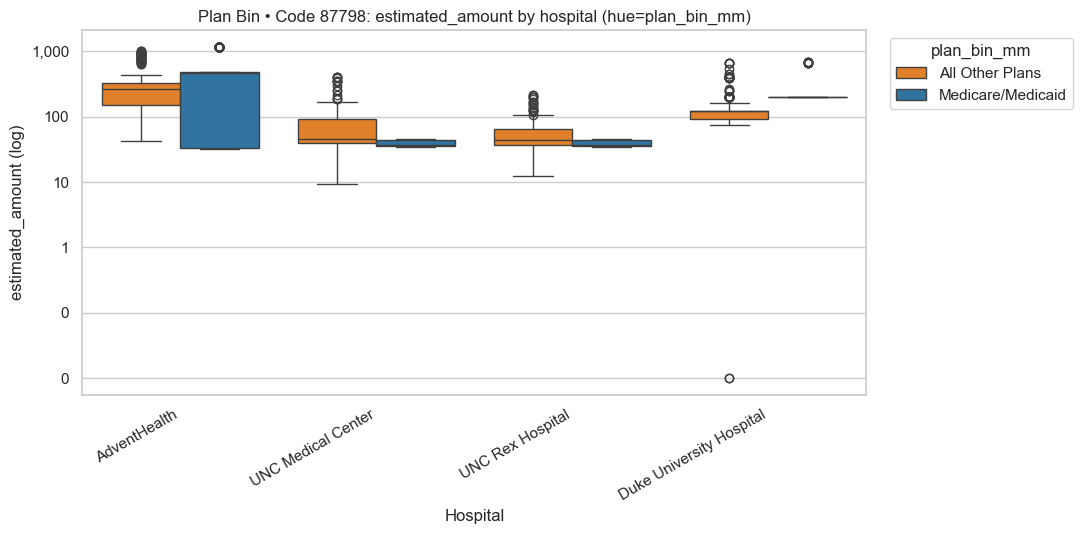

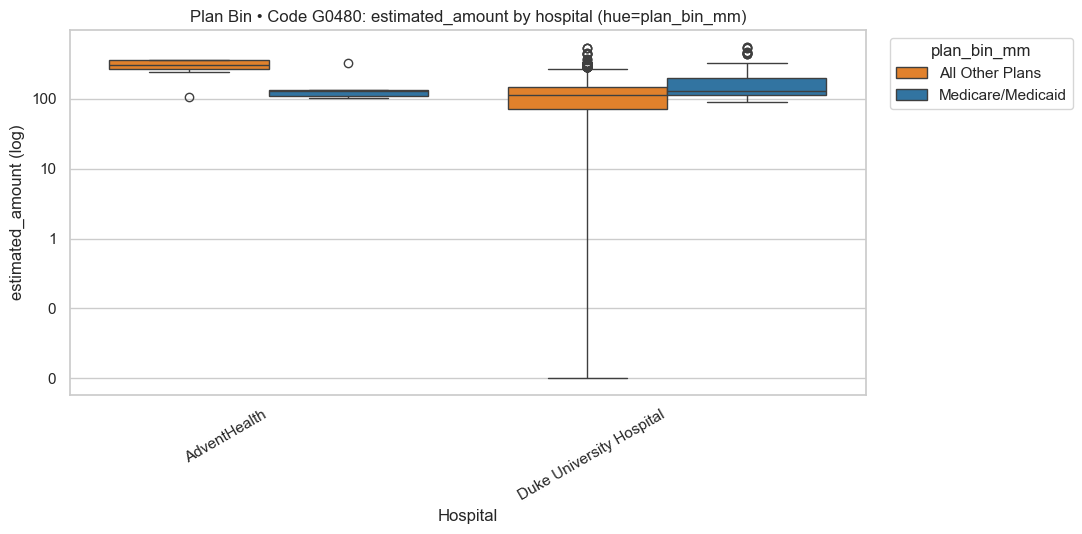

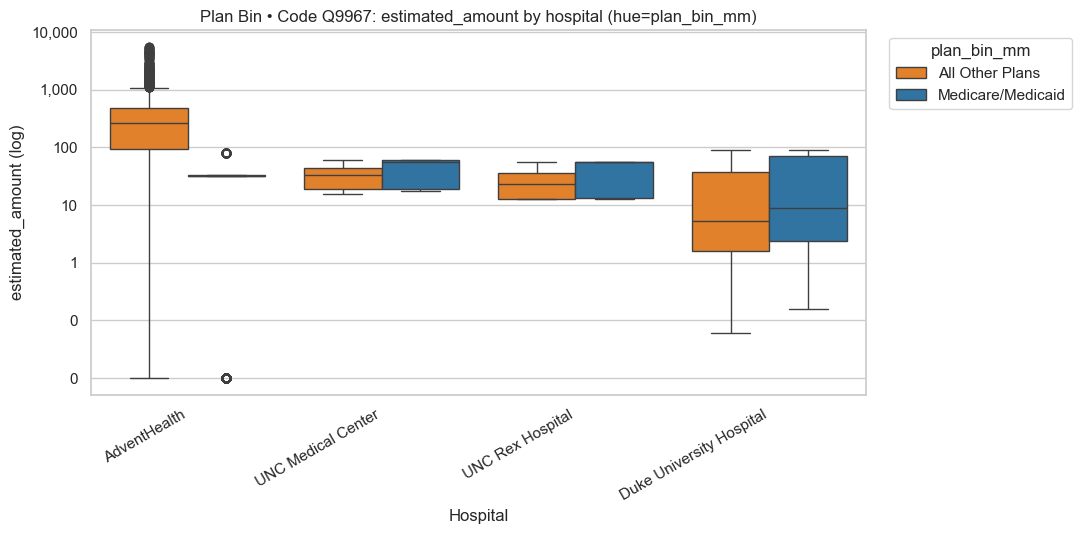

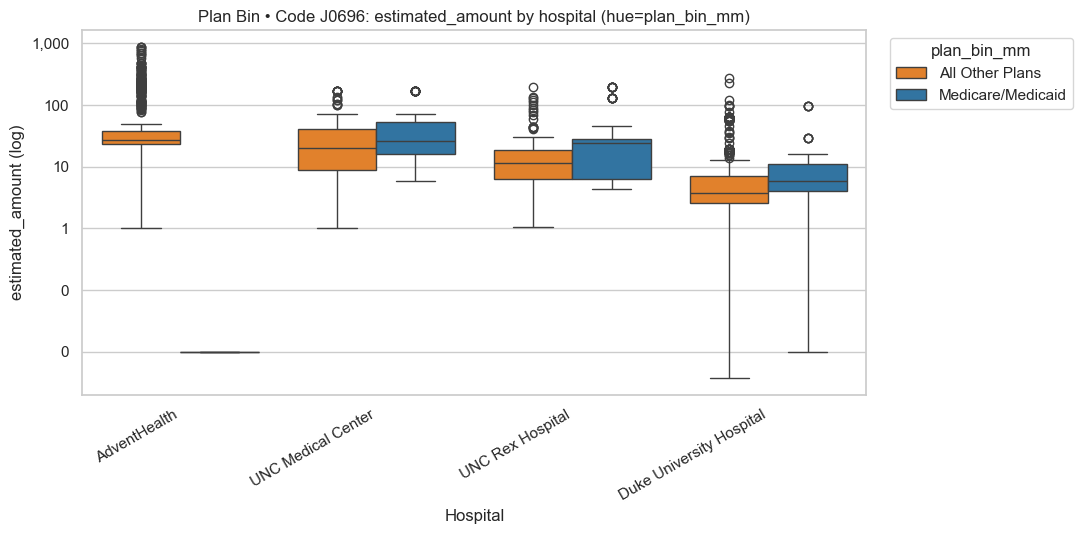

In [78]:
# Execute stratified analysis and generate visuals

# 1) Descriptive variation
variation_by_payer = compute_code_level_variation_by(df, [COL_HOSPITAL, COL_PAYER], price_col=COL_PRICE_EST)
variation_by_plan  = compute_code_level_variation_by(df, [COL_HOSPITAL, COL_PAYER, COL_PLAN], price_col=COL_PRICE_EST)

# 2) Kruskal across hospitals within payer/plan strata
kw_by_payer = kruskal_code_by_hospital_stratified(df, group_col=COL_PAYER, price_col=COL_PRICE_EST)
kw_by_plan  = kruskal_code_by_hospital_stratified(df, group_col=COL_PLAN,  price_col=COL_PRICE_EST)

# 3) Within-hospital dispersion refined
gaps_within_payer_over_plans, gaps_within_plan_over_payers = compute_within_hospital_plan_gaps(df, price_col=COL_PRICE_EST)
gap_tests_within_payer = one_sample_gap_tests(gaps_within_payer_over_plans)
gap_tests_within_plan  = one_sample_gap_tests(gaps_within_plan_over_payers)

# Display concise summaries
print("Descriptive variation by payer (head):")
display(variation_by_payer.head(10))
print("\nDescriptive variation by plan (head):")
display(variation_by_plan.head(10))
print("\nKruskal across hospitals within payer (head):")
display(kw_by_payer.head(10))
print("\nKruskal across hospitals within plan (head):")
display(kw_by_plan.head(10))

print("\nWithin-hospital gaps: across plans (within-payer) -> summary tests:")
print(gap_tests_within_payer)
print("\nWithin-hospital gaps: across payers (within-plan) -> summary tests:")
print(gap_tests_within_plan)

# 4) Visualizations using two bins: Medicare/Medicaid vs All Other Plans
sns.set_theme(style="whitegrid")
# Derive the two-bin column once
if 'plan_bin_mm' not in df.columns:
    df['plan_bin_mm'] = derive_plan_bin_mm(df[COL_PLAN])

# Plot top codes by hospital with hue = two-bin plan category
plot_top_codes_by_hospital(df, hue_col='plan_bin_mm', top_k=4, title_prefix="Plan Bin • ", palette=PALETTE_MM)


In [79]:
# Bundle-Level Analysis (RC + Service Config)
# Uses CLEAR/docs/data/rc_config.json and service_config.json to group codes.

import json, re
from pathlib import Path
import numpy as np
import pandas as pd

# ---------- resolve data dir for configs ----------

def _resolve_data_dir():
    cands = [
        Path.cwd() / "CLEAR" / "docs" / "data",
        Path.cwd() / "docs" / "data",
    ]
    for p in cands:
        if p.exists():
            return p
    raise FileNotFoundError("Could not locate docs/data directory. Checked: " + ", ".join(str(x) for x in cands))

_data_dir = _resolve_data_dir()
_rc_path = _data_dir / "rc_config.json"
_svc_path = _data_dir / "service_config.json"

with open(_rc_path, "r", encoding="utf-8") as f:
    rc_cfg = json.load(f)
with open(_svc_path, "r", encoding="utf-8") as f:
    svc_cfg = json.load(f)

# ---------- compile patterns (case-insensitive) ----------

def _compile_cfg_patterns(cfg: dict) -> list[tuple[str, re.Pattern]]:
    out = []
    for label, item in cfg.items():
        pat = item.get("pattern", "").strip()
        if pat:
            try:
                out.append((label, re.compile(pat, re.IGNORECASE)))
            except re.error:
                # Skip invalid regex entries gracefully
                pass
    return out

rc_patterns = _compile_cfg_patterns(rc_cfg)
svc_patterns = _compile_cfg_patterns(svc_cfg)

# ---------- normalize code strings ----------

def _norm_code(code_val) -> str:
    if pd.isna(code_val):
        return ""
    s = str(code_val).strip()
    return s

# Zero-pad 3-digit RCs to 4 digits if needed
def _pad_rc(code_str: str) -> str:
    if not code_str:
        return code_str
    # If purely digits and <=4, pad to 4
    if re.fullmatch(r"\d{1,4}", code_str):
        return code_str.zfill(4)
    return code_str

# ---------- map bundles for each unique (code, description, type) ----------

def _map_bundle_for_row(code_str: str, desc_str: str, type_str: str,
                        rc_pats: list[tuple[str, re.Pattern]],
                        svc_pats: list[tuple[str, re.Pattern]]):
    # Prefer service bundles for non-RC, RC bundles for RC type
    def _first_match(pats):
        for lbl, pat in pats:
            if (code_str and pat.search(code_str)) or (desc_str and pat.search(desc_str)):
                return lbl
        return None

    if type_str and str(type_str).upper() == "RC":
        # Try RC patterns on RC-style code (padded) and description
        rc_code = _pad_rc(code_str)
        lbl = _first_match([(l, re.compile(p.pattern, re.IGNORECASE)) for l, p in rc_pats])
        if lbl:
            return lbl
        # Fallback: also try service patterns (some RC lines include CPT/HCPCS in desc)
        lbl = _first_match(svc_pats)
        return lbl
    else:
        # Non-RC: try service first, then RC as fallback
        lbl = _first_match(svc_pats)
        if lbl:
            return lbl
        lbl = _first_match(rc_pats)
        return lbl

# Build mapping for unique keys to avoid per-row regex loops
uniq = (df[[COL_CODE, COL_DESCRIPTION, COL_PRICE_TYPE]]
          .fillna({COL_CODE: "", COL_DESCRIPTION: "", COL_PRICE_TYPE: ""})
          .drop_duplicates())

uniq["__code_s"] = uniq[COL_CODE].apply(_norm_code)
uniq["__desc_s"] = uniq[COL_DESCRIPTION].astype(str)
uniq["__type_s"] = uniq[COL_PRICE_TYPE].astype(str)

bundle_labels = []
for _, r in uniq.iterrows():
    lbl = _map_bundle_for_row(r["__code_s"], r["__desc_s"], r["__type_s"], rc_patterns, svc_patterns)
    bundle_labels.append(lbl)

uniq["bundle_label"] = bundle_labels

# Join back to df
_df_b = df.merge(uniq[[COL_CODE, COL_DESCRIPTION, COL_PRICE_TYPE, "bundle_label"]],
                 on=[COL_CODE, COL_DESCRIPTION, COL_PRICE_TYPE], how="left")

matched_ratio = _df_b["bundle_label"].notna().mean()
print(f"Bundle mapping coverage: {matched_ratio:.1%} of rows mapped.")

# ---------- Bundle-level statistics ----------

PRICE = COL_PRICE_EST
subb = _df_b[pd.to_numeric(_df_b[PRICE], errors="coerce").notna()].copy()
subb[PRICE] = pd.to_numeric(subb[PRICE], errors="coerce")

# Descriptive variation per bundle × type × hospital
by = subb.dropna(subset=["bundle_label"]).groupby(["bundle_label", COL_PRICE_TYPE, COL_HOSPITAL])[PRICE]
variation_by_bundle = by.agg(
    mean   = "mean",
    median = "median",
    sd     = "std",
    q1     = lambda x: np.percentile(x, 25),
    q3     = lambda x: np.percentile(x, 75),
    count  = "count",
    min    = "min",
    max    = "max",
).reset_index()
variation_by_bundle["iqr"] = variation_by_bundle["q3"] - variation_by_bundle["q1"]
variation_by_bundle["cv"]  = variation_by_bundle["sd"] / variation_by_bundle["mean"]

print("Descriptive variation by bundle (head):")
display(variation_by_bundle.head(12))

# Kruskal across hospitals per bundle (guard identical values)
results = []
for bundle, g_b in subb.dropna(subset=["bundle_label"]).groupby("bundle_label"):
    groups = []
    for hosp, g_h in g_b.groupby(COL_HOSPITAL):
        vals = g_h[PRICE].dropna().values
        if len(vals) > 1:
            groups.append(vals)
    if len(groups) >= 2:
        all_vals = np.concatenate(groups)
        if all_vals.size == 0 or np.nanstd(all_vals) == 0:
            stat, p = np.nan, np.nan
        else:
            try:
                stat, p = kruskal(*groups)
            except Exception:
                stat, p = np.nan, np.nan
        results.append({
            "bundle_label": bundle,
            "n_hospitals": len(groups),
            "kruskal_stat": stat,
            "p_value": p,
        })
kw_by_bundle = pd.DataFrame(results)
print("\nKruskal across hospitals per bundle (head):")
display(kw_by_bundle.head(12))

# Within-hospital gaps per bundle
gh = (subb.dropna(subset=["bundle_label"]) \
          .groupby([COL_HOSPITAL, "bundle_label"], dropna=False)[PRICE] \
          .agg(["min", "max", "count"]).reset_index())

gh = gh[gh["count"] >= 2].copy()
gh["gap_ratio"] = gh["max"] / gh["min"]
gh["log_gap"]   = np.log(gh["gap_ratio"])  # reuse gap tests

print("\nWithin-hospital bundle gaps (head):")
display(gh.head(12))

print("\nBundle gap tests (one-sample vs 0, log_gap):")
print(one_sample_gap_tests(gh))


Bundle mapping coverage: 100.0% of rows mapped.
Descriptive variation by bundle (head):


,bundle_label,type,hospital_id,mean,median,sd,q1,q3,count,min,max,iqr,cv
0,Acquisition of Body Components,RC,29a8pin7,63313.433235,45716.11,23489.149688,44386.7500,86516.9700,34,43892.550,100192.030,42130.220,0.370998
1,Acquisition of Body Components,RC,cwmo7l4t,63237.704924,66634.00,24167.150534,43295.4425,77295.2825,92,24921.116,126713.575,33999.840,0.382164
2,Alpha-1 Proteinase Inhibitor,HCPCS,1r6ycd9n,7.240000,5.00,2.570344,5.0000,10.0000,25,5.000,11.000,5.000,0.355020
3,Alpha-1 Proteinase Inhibitor,HCPCS,29a8pin7,13.974286,8.29,11.253218,4.9300,20.5500,28,4.690,46.400,15.620,0.805280
4,Ambulance – ALS1 Emergency Base Rate,HCPCS,1r6ycd9n,1475.162973,1677.00,690.730542,834.0000,2042.0000,37,0.010,2228.000,1208.000,0.468240
5,Ambulance – ALS1 Emergency Base Rate,HCPCS,29a8pin7,1189.938966,544.86,1076.922223,505.5500,2883.0300,29,125.930,2969.520,2377.480,0.905023
6,Ambulance – ALS1 Emergency Base Rate,HCPCS,cwmo7l4t,2028.186210,1682.80,998.895523,1175.7100,2963.8600,138,664.224,4955.875,1788.150,0.492507
7,Ambulance – Air (Rotor) Mileage,HCPCS,1r6ycd9n,458.027838,179.00,548.982025,149.0000,1045.0000,37,0.010,2608.000,896.000,1.198578
8,Ambulance – Air (Rotor) Mileage,HCPCS,29a8pin7,70.295862,64.07,38.340352,29.3900,119.0000,145,11.480,119.000,89.610,0.545414
9,Ambulance – Air (Rotor) Mileage,HCPCS,cwmo7l4t,54.842772,28.95,53.546038,10.0000,100.0000,184,3.740,205.000,90.000,0.976355



Kruskal across hospitals per bundle (head):


,bundle_label,n_hospitals,kruskal_stat,p_value
0,Acquisition of Body Components,2,1.194390,2.744458e-01
1,Alpha-1 Proteinase Inhibitor,2,1.049883,3.055340e-01
2,Ambulance – ALS1 Emergency Base Rate,3,26.245400,1.999327e-06
3,Ambulance – Air (Rotor) Mileage,3,78.119903,1.087624e-17
4,Ambulance – BLS Emergency Base Rate,3,22.913209,1.057937e-05
5,Ambulance – BLS Non-Emergency,2,1.282128,2.575038e-01
6,Ambulance – Ground Mileage,3,106.341396,8.095792e-24
7,Antibiotic Susceptibility MIC,5,1043.731105,1.188667e-224
8,Any J-code Injectable (catch-all),4,4482.194287,0.000000e+00
9,Basic Metabolic Panel (BMP),4,60.020903,5.818095e-13



Within-hospital bundle gaps (head):


,hospital_id,bundle_label,min,max,count,gap_ratio,log_gap
0,1r6ycd9n,Alpha-1 Proteinase Inhibitor,5.00,11.0,25,2.200000e+00,0.788457
1,1r6ycd9n,Ambulance – ALS1 Emergency Base Rate,0.01,2228.0,37,2.228000e+05,12.314030
2,1r6ycd9n,Ambulance – Air (Rotor) Mileage,0.01,2608.0,37,2.608000e+05,12.471509
3,1r6ycd9n,Ambulance – BLS Emergency Base Rate,0.01,2232.0,74,2.232000e+05,12.315824
4,1r6ycd9n,Ambulance – Ground Mileage,0.01,1734.0,37,1.734000e+05,12.063356
5,1r6ycd9n,Antibiotic Susceptibility MIC,0.01,18713.0,1480,1.871300e+06,14.442144
6,1r6ycd9n,Any J-code Injectable (catch-all),0.01,258608.0,11847,2.586080e+07,17.068239
7,1r6ycd9n,Basic Metabolic Panel (BMP),7.00,1949.0,26,2.784286e+02,5.629162
8,1r6ycd9n,CBC with Differential,7.00,1246.0,37,1.780000e+02,5.181784
9,1r6ycd9n,CBC without Differential,97.00,147.0,11,1.515464e+00,0.415722



Bundle gap tests (one-sample vs 0, log_gap):
{'n': 250, 't_stat': 16.37985335197177, 't_p_value': 2.0431321532801237e-41, 'wilcoxon_stat': 0.0, 'wilcoxon_p_value': 9.241590728776954e-43, 'median_gap_ratio': 13.610354560979708, 'median_log_gap': 2.6108004699563896}


# Missing Data Analysis

This section analyzes:
1. Which codes are missing from specific hospitals
2. Which hospitals/payers/plans don't have listed prices (estimated_amount, max, min) for codes
3. Summary tables of missing data patterns

In [80]:
###############################################################################
# MISSING DATA ANALYSIS
###############################################################################

# 1. Identify all unique codes and hospitals in the dataset
all_codes = df[COL_CODE].unique()
all_hospitals = df[COL_HOSPITAL].unique()
all_hospital_names = df[['hospital_id', 'hospital_name']].drop_duplicates()

print(f"Total unique codes: {len(all_codes)}")
print(f"Total unique hospitals: {len(all_hospitals)}")

# 2. Create a matrix of codes x hospitals to identify which codes are missing from which hospitals
code_hospital_matrix = df.groupby([COL_CODE, COL_HOSPITAL]).size().unstack(fill_value=0)
code_hospital_matrix = (code_hospital_matrix > 0).astype(int)  # Convert to presence/absence (1/0)

# 3. Identify codes not found in specific hospitals
missing_codes_by_hospital = []

for hospital in all_hospitals:
    if hospital in code_hospital_matrix.columns:
        missing_codes = code_hospital_matrix[code_hospital_matrix[hospital] == 0].index.tolist()
        hospital_name = all_hospital_names[all_hospital_names['hospital_id'] == hospital]['hospital_name'].values
        hospital_name = hospital_name[0] if len(hospital_name) > 0 else hospital
        
        missing_codes_by_hospital.append({
            'hospital_id': hospital,
            'hospital_name': hospital_name,
            'total_codes_missing': len(missing_codes),
            'pct_codes_missing': round(len(missing_codes) / len(all_codes) * 100, 2),
            'missing_codes': missing_codes[:20]  # Store first 20 for reference
        })

missing_codes_df = pd.DataFrame(missing_codes_by_hospital)
missing_codes_df = missing_codes_df.sort_values('total_codes_missing', ascending=False)

print("\n" + "="*80)
print("CODES MISSING BY HOSPITAL")
print("="*80)
print(missing_codes_df[['hospital_id', 'hospital_name', 'total_codes_missing', 'pct_codes_missing']].head(20))

Total unique codes: 407
Total unique hospitals: 7

CODES MISSING BY HOSPITAL
  hospital_id             hospital_name  total_codes_missing  \
5    5rjtdp74               MUSC Health                  391   
6    9p89xmn1    Inova Fairfax Hospital                  317   
2    59ew6vnb          UNC Rex Hospital                  271   
1    29a8pin7        UNC Medical Center                  244   
4    cwmo7l4t  Duke University Hospital                  215   
0    1r6ycd9n              AdventHealth                  208   
3    89spvp3v    WakeMed North Hospital                   18   

   pct_codes_missing  
5              96.07  
6              77.89  
2              66.58  
1              59.95  
4              52.83  
0              51.11  
3               4.42  


In [81]:
###############################################################################
# MISSING PRICING DATA ANALYSIS
###############################################################################

# 4. Analyze missing pricing data (estimated_amount, max, min) by hospital, payer, and plan

price_cols_to_check = [COL_PRICE_EST, COL_MAX_PRICE, COL_MIN_PRICE]

# Create a detailed missing data report
missing_price_data = []

for code in all_codes:
    code_df = df[df[COL_CODE] == code].copy()
    
    # For each hospital-payer-plan-code combination, check for missing prices
    for _, row in code_df.iterrows():
        hospital_id = row[COL_HOSPITAL]
        hospital_name = row.get('hospital_name', hospital_id)
        payer = row[COL_PAYER]
        plan = row[COL_PLAN]
        
        missing_info = {
            'code': code,
            'hospital_id': hospital_id,
            'hospital_name': hospital_name,
            'payer_name': payer,
            'plan_name': plan,
            'missing_estimated_amount': pd.isna(row[COL_PRICE_EST]) if COL_PRICE_EST in row else True,
            'missing_max_price': pd.isna(row[COL_MAX_PRICE]) if COL_MAX_PRICE in row else True,
            'missing_min_price': pd.isna(row[COL_MIN_PRICE]) if COL_MIN_PRICE in row else True,
        }
        
        # Only record if at least one price is missing
        if any([missing_info['missing_estimated_amount'], 
                missing_info['missing_max_price'], 
                missing_info['missing_min_price']]):
            missing_price_data.append(missing_info)

missing_price_df = pd.DataFrame(missing_price_data)

print("\n" + "="*80)
print("MISSING PRICING DATA SUMMARY")
print("="*80)
print(f"Total records with at least one missing price field: {len(missing_price_df)}")
print(f"Total records in dataset: {len(df)}")
print(f"Percentage with missing prices: {round(len(missing_price_df) / len(df) * 100, 2)}%")


MISSING PRICING DATA SUMMARY
Total records with at least one missing price field: 15529
Total records in dataset: 97836
Percentage with missing prices: 15.87%


In [82]:
###############################################################################
# SUMMARY TABLES FOR MISSING DATA
###############################################################################

# 5. Summary by Hospital - Count of missing prices per hospital
hospital_missing_summary = missing_price_df.groupby(['hospital_id', 'hospital_name']).agg({
    'missing_estimated_amount': 'sum',
    'missing_max_price': 'sum',
    'missing_min_price': 'sum',
    'code': 'count'
}).rename(columns={'code': 'total_records_with_missing_data'})

hospital_missing_summary['missing_all_three'] = missing_price_df.groupby(['hospital_id', 'hospital_name']).apply(
    lambda x: ((x['missing_estimated_amount']) & (x['missing_max_price']) & (x['missing_min_price'])).sum()
).values

hospital_missing_summary = hospital_missing_summary.sort_values('total_records_with_missing_data', ascending=False)

print("\n" + "="*80)
print("MISSING DATA BY HOSPITAL")
print("="*80)
print(hospital_missing_summary.head(20))

# 6. Summary by Payer - Count of missing prices per payer
payer_missing_summary = missing_price_df.groupby('payer_name').agg({
    'missing_estimated_amount': 'sum',
    'missing_max_price': 'sum',
    'missing_min_price': 'sum',
    'code': 'count'
}).rename(columns={'code': 'total_records_with_missing_data'})

payer_missing_summary['missing_all_three'] = missing_price_df.groupby('payer_name').apply(
    lambda x: ((x['missing_estimated_amount']) & (x['missing_max_price']) & (x['missing_min_price'])).sum()
).values

payer_missing_summary = payer_missing_summary.sort_values('total_records_with_missing_data', ascending=False)

print("\n" + "="*80)
print("MISSING DATA BY PAYER")
print("="*80)
print(payer_missing_summary.head(20))

# 7. Summary by Plan - Count of missing prices per plan
plan_missing_summary = missing_price_df.groupby('plan_name').agg({
    'missing_estimated_amount': 'sum',
    'missing_max_price': 'sum',
    'missing_min_price': 'sum',
    'code': 'count'
}).rename(columns={'code': 'total_records_with_missing_data'})

plan_missing_summary['missing_all_three'] = missing_price_df.groupby('plan_name').apply(
    lambda x: ((x['missing_estimated_amount']) & (x['missing_max_price']) & (x['missing_min_price'])).sum()
).values

plan_missing_summary = plan_missing_summary.sort_values('total_records_with_missing_data', ascending=False)

print("\n" + "="*80)
print("MISSING DATA BY PLAN")
print("="*80)
print(plan_missing_summary.head(20))


MISSING DATA BY HOSPITAL
                                      missing_estimated_amount  \
hospital_id hospital_name                                        
9p89xmn1    Inova Fairfax Hospital                        8401   
89spvp3v    WakeMed North Hospital                        6460   
cwmo7l4t    Duke University Hospital                       596   

                                      missing_max_price  missing_min_price  \
hospital_id hospital_name                                                    
9p89xmn1    Inova Fairfax Hospital                    0                  0   
89spvp3v    WakeMed North Hospital                    0                  0   
cwmo7l4t    Duke University Hospital                 73                 73   

                                      total_records_with_missing_data  \
hospital_id hospital_name                                               
9p89xmn1    Inova Fairfax Hospital                               8401   
89spvp3v    WakeMed North Hospita

In [83]:
###############################################################################
# SUMMARY TABLE: CODES WITH MOST MISSING DATA
###############################################################################

# 8. Identify which specific codes have the most missing data across all hospitals
code_missing_summary = missing_price_df.groupby('code').agg({
    'missing_estimated_amount': 'sum',
    'missing_max_price': 'sum',
    'missing_min_price': 'sum',
    'hospital_id': 'nunique',
    'payer_name': 'nunique',
    'plan_name': 'nunique'
}).rename(columns={
    'hospital_id': 'num_hospitals_missing_data',
    'payer_name': 'num_payers_missing_data',
    'plan_name': 'num_plans_missing_data'
})

code_missing_summary['total_missing_instances'] = (
    code_missing_summary['missing_estimated_amount'] +
    code_missing_summary['missing_max_price'] +
    code_missing_summary['missing_min_price']
)

code_missing_summary = code_missing_summary.sort_values('total_missing_instances', ascending=False)

print("\n" + "="*80)
print("CODES WITH MOST MISSING DATA")
print("="*80)
print(code_missing_summary.head(30))

# 9. Overall summary statistics
print("\n" + "="*80)
print("OVERALL MISSING DATA STATISTICS")
print("="*80)
print(f"Total unique codes in dataset: {len(all_codes)}")
print(f"Codes with at least one missing price: {len(code_missing_summary)}")
print(f"Total hospitals: {len(all_hospitals)}")
print(f"Total unique payers: {df[COL_PAYER].nunique()}")
print(f"Total unique plans: {df[COL_PLAN].nunique()}")
print(f"\nMissing data counts:")
print(f"  Records missing estimated_amount: {missing_price_df['missing_estimated_amount'].sum()}")
print(f"  Records missing max_price: {missing_price_df['missing_max_price'].sum()}")
print(f"  Records missing min_price: {missing_price_df['missing_min_price'].sum()}")
print(f"  Records missing all three prices: {((missing_price_df['missing_estimated_amount']) & (missing_price_df['missing_max_price']) & (missing_price_df['missing_min_price'])).sum()}")


CODES WITH MOST MISSING DATA
       missing_estimated_amount  missing_max_price  missing_min_price  \
code                                                                    
J0881                       612                  0                  0   
J0696                       586                 10                 10   
Q9967                       518                  0                  0   
J1100                       458                  0                  0   
J7507                       429                  0                  0   
J7626                       324                  0                  0   
J2919                       312                  0                  0   
J7517                       300                  0                  0   
J7195                       266                  0                  0   
A9585                       219                  6                  6   
J1569                       219                  0                  0   
J7520                

In [84]:
###############################################################################
# EXPORT COMPREHENSIVE MISSING DATA SUMMARY TABLE
###############################################################################

# 10. Create a comprehensive summary table combining all missing data metrics
comprehensive_summary = pd.DataFrame({
    'Category': ['Total Codes', 'Total Hospitals', 'Total Payers', 'Total Plans', 
                 'Records with Missing Data', 'Total Records in Dataset',
                 'Percent Records with Missing Data',
                 'Missing Estimated Amount', 'Missing Max Price', 'Missing Min Price',
                 'Missing All Three Prices'],
    'Count': [
        len(all_codes),
        len(all_hospitals),
        df[COL_PAYER].nunique(),
        df[COL_PLAN].nunique(),
        len(missing_price_df),
        len(df),
        f"{round(len(missing_price_df) / len(df) * 100, 2)}%",
        missing_price_df['missing_estimated_amount'].sum(),
        missing_price_df['missing_max_price'].sum(),
        missing_price_df['missing_min_price'].sum(),
        ((missing_price_df['missing_estimated_amount']) & 
         (missing_price_df['missing_max_price']) & 
         (missing_price_df['missing_min_price'])).sum()
    ]
})

print("\n" + "="*80)
print("COMPREHENSIVE MISSING DATA SUMMARY")
print("="*80)
print(comprehensive_summary.to_string(index=False))

# Store the summary dataframes for further analysis
missing_data_summaries = {
    'comprehensive': comprehensive_summary,
    'by_hospital': hospital_missing_summary,
    'by_payer': payer_missing_summary,
    'by_plan': plan_missing_summary,
    'by_code': code_missing_summary,
    'codes_missing_by_hospital': missing_codes_df,
    'detailed_missing_records': missing_price_df
}

print("\n" + "="*80)
print("Missing data analysis complete!")
print("Available dataframes:")
print("  - missing_data_summaries['comprehensive']: Overall summary")
print("  - missing_data_summaries['by_hospital']: Missing data by hospital")
print("  - missing_data_summaries['by_payer']: Missing data by payer")
print("  - missing_data_summaries['by_plan']: Missing data by plan")
print("  - missing_data_summaries['by_code']: Missing data by code")
print("  - missing_data_summaries['codes_missing_by_hospital']: Codes not found in hospitals")
print("  - missing_data_summaries['detailed_missing_records']: Detailed records with missing prices")
print("="*80)


COMPREHENSIVE MISSING DATA SUMMARY
                         Category  Count
                      Total Codes    407
                  Total Hospitals      7
                     Total Payers     49
                      Total Plans     19
        Records with Missing Data  15529
         Total Records in Dataset  97836
Percent Records with Missing Data 15.87%
         Missing Estimated Amount  15457
                Missing Max Price     73
                Missing Min Price     73
         Missing All Three Prices      1

Missing data analysis complete!
Available dataframes:
  - missing_data_summaries['comprehensive']: Overall summary
  - missing_data_summaries['by_hospital']: Missing data by hospital
  - missing_data_summaries['by_payer']: Missing data by payer
  - missing_data_summaries['by_plan']: Missing data by plan
  - missing_data_summaries['by_code']: Missing data by code
  - missing_data_summaries['codes_missing_by_hospital']: Codes not found in hospitals
  - missing_data_sum

In [85]:
# Display comprehensive summary table
missing_data_summaries['comprehensive']

,Category,Count
0,Total Codes,407
1,Total Hospitals,7
2,Total Payers,49
3,Total Plans,19
4,Records with Missing Data,15529
5,Total Records in Dataset,97836
6,Percent Records with Missing Data,15.87%
7,Missing Estimated Amount,15457
8,Missing Max Price,73
9,Missing Min Price,73


In [86]:
# Display top hospitals with missing data
missing_data_summaries['by_hospital'].head(15)

,,missing_estimated_amount,missing_max_price,missing_min_price,total_records_with_missing_data,missing_all_three
hospital_id,hospital_name,,,,,
9p89xmn1,Inova Fairfax Hospital,8401,0,0,8401,0
89spvp3v,WakeMed North Hospital,6460,0,0,6460,0
cwmo7l4t,Duke University Hospital,596,73,73,668,1


In [87]:
# Display top payers with missing data
missing_data_summaries['by_payer'].head(15)

,missing_estimated_amount,missing_max_price,missing_min_price,total_records_with_missing_data,missing_all_three
payer_name,,,,,
AETNA,2081,3,3,2084,0
UNITEDHEALTHCARE,1750,48,48,1798,0
CIGNA,1723,17,17,1740,0
HUMANA,1401,0,0,1401,0
SENTARA HEALTH,1309,0,0,1309,0
CAREFIRST,1252,0,0,1252,0
KAISER PERMANENTE,989,0,0,989,0
MEDCOST,828,0,0,828,0
ANTHEM,637,0,0,637,0


In [88]:
# Display top plans with missing data
missing_data_summaries['by_plan'].head(15)

,missing_estimated_amount,missing_max_price,missing_min_price,total_records_with_missing_data,missing_all_three
plan_name,,,,,
COMMERCIAL,4476,23,23,4499,0
MEDICARE ADVANTAGE,2465,0,0,2465,0
EXCHANGE,2199,0,0,2199,0
HMO,1917,21,21,1938,0
PPO,1913,21,21,1934,0
MEDICAID MANAGED CARE,1096,0,0,1096,0
GOVERNMENT,736,2,2,737,1
HMO/PPO,572,0,0,572,0
MEDICAID,55,0,0,55,0


In [89]:
# Display codes with most missing data
missing_data_summaries['by_code'].head(20)

,missing_estimated_amount,missing_max_price,missing_min_price,num_hospitals_missing_data,num_payers_missing_data,num_plans_missing_data,total_missing_instances
code,,,,,,,
J0881,612,0,0,3,20,8,612
J0696,586,10,10,3,13,7,606
Q9967,518,0,0,3,12,7,518
J1100,458,0,0,3,13,7,458
J7507,429,0,0,3,12,7,429
J7626,324,0,0,2,11,6,324
J2919,312,0,0,3,12,7,312
J7517,300,0,0,3,11,6,300
J7195,266,0,0,3,20,8,266


In [90]:
# Display which codes are missing from which hospitals
missing_data_summaries['codes_missing_by_hospital'][['hospital_id', 'hospital_name', 'total_codes_missing', 'pct_codes_missing']].head(15)

,hospital_id,hospital_name,total_codes_missing,pct_codes_missing
5,5rjtdp74,MUSC Health,391,96.07
6,9p89xmn1,Inova Fairfax Hospital,317,77.89
2,59ew6vnb,UNC Rex Hospital,271,66.58
1,29a8pin7,UNC Medical Center,244,59.95
4,cwmo7l4t,Duke University Hospital,215,52.83
0,1r6ycd9n,AdventHealth,208,51.11
3,89spvp3v,WakeMed North Hospital,18,4.42


Bundle Kruskal FDR summary:


,tested,sig_raw_p<0.05,sig_fdr_q<0.05
0,63,58,58


Top bundles by FDR q-value (head):


,bundle_label,n_hospitals,kruskal_stat,p_value,q_value,reject_fdr_5pct
8,Any J-code Injectable (catch-all),4,4482.194287,0.000000e+00,0.000000e+00,True
17,DNA/NAAT – Unspecified Agent,4,1754.787145,0.000000e+00,0.000000e+00,True
7,Antibiotic Susceptibility MIC,5,1043.731105,1.188667e-224,2.496201e-223,True
13,CPT – Unclassified (Review Needed),5,847.574728,3.798900e-182,5.983267e-181,True
24,Flow Cytometry (Tech/Professional),4,827.660557,4.336941e-179,5.464546e-178,True
33,Immunoglobulins (IgG/IgA/IgM each),4,558.695652,9.059070e-121,9.512023e-120,True
40,Magnesium,4,365.036584,8.271917e-79,7.444725e-78,True
58,Urine Creatinine (random),4,328.973993,5.321574e-71,4.190740e-70,True
54,Testosterone – Total (Assay),4,304.265457,1.187359e-65,8.311516e-65,True
30,IHC – Estrogen Receptor (ER),5,232.886695,3.155915e-49,1.988226e-48,True


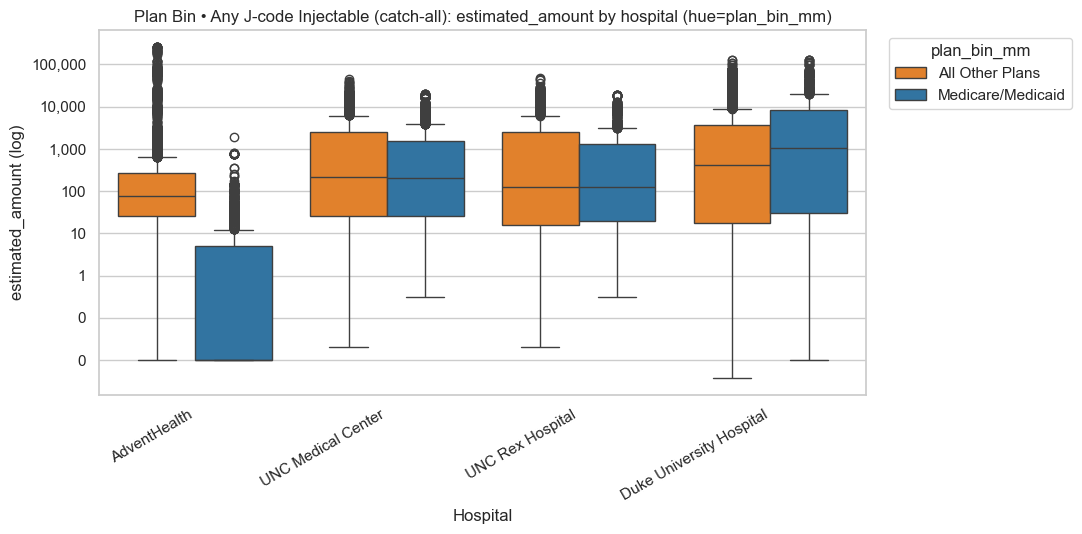

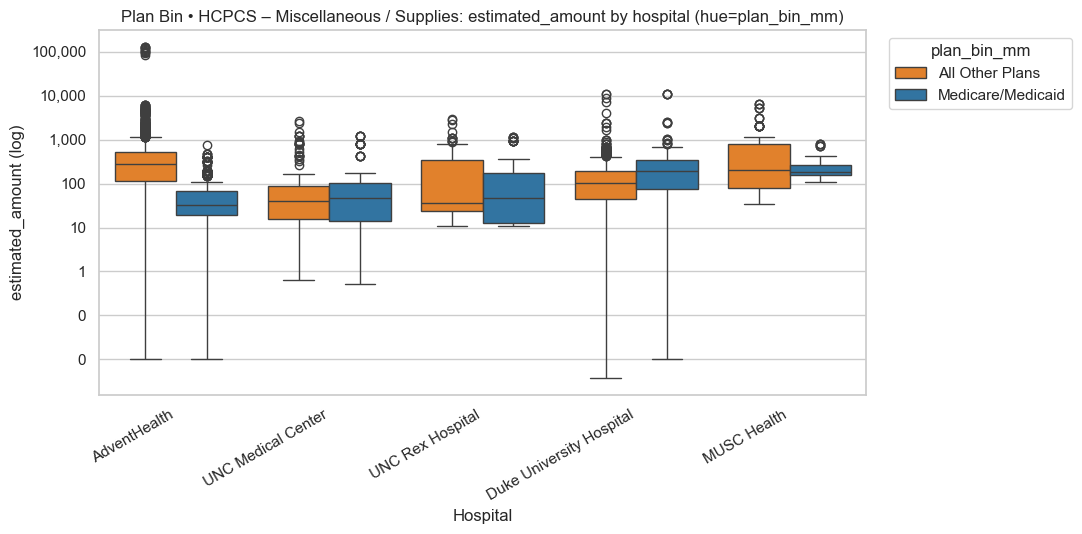

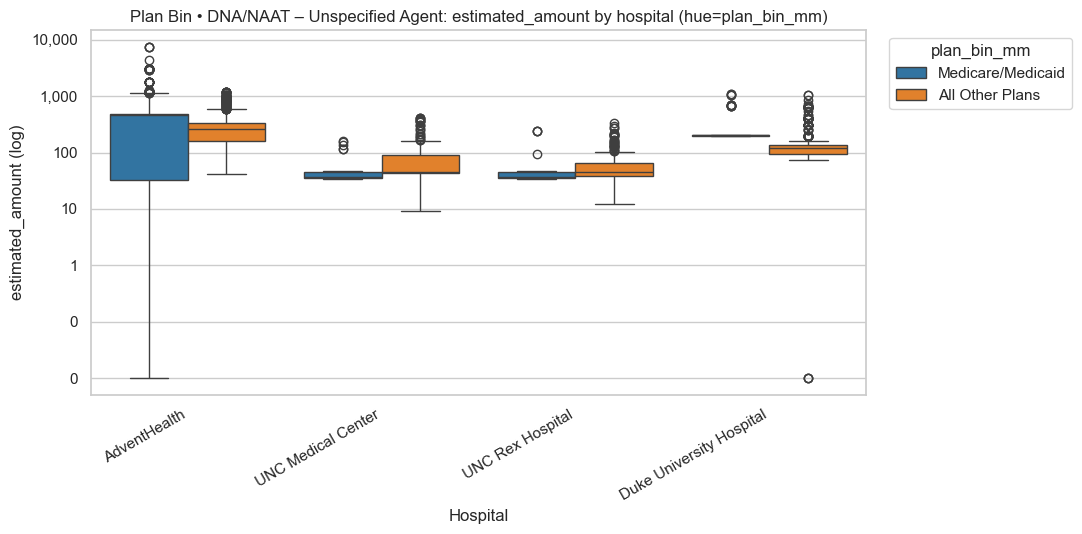

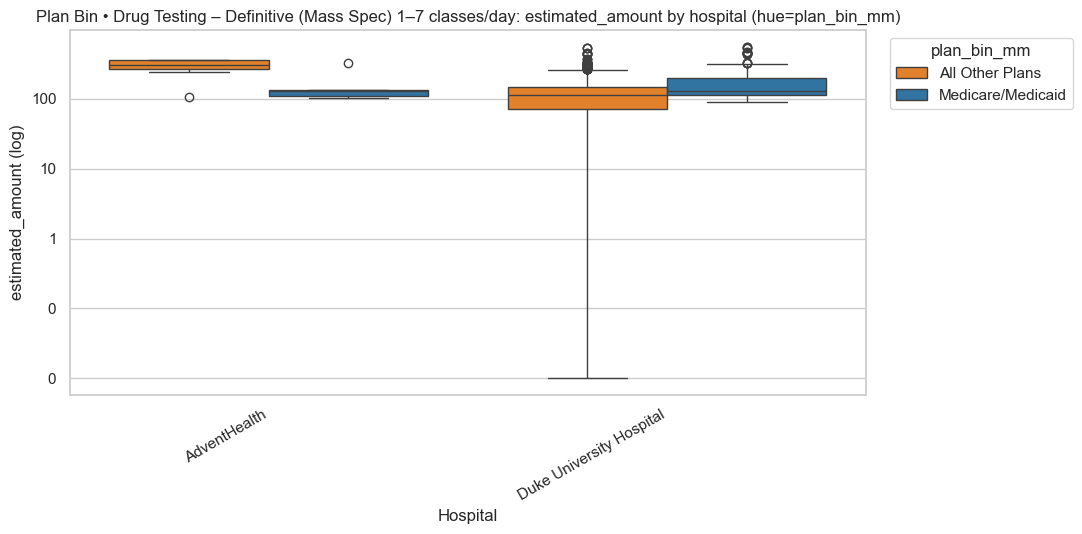

Parquet save skipped: ("Expected bytes, got a 'int' object", 'Conversion failed for column code with type object')
Saved outputs:
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\bundle_mapping.csv
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\bundle_variation.csv
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\bundle_kruskal_fdr.csv
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\bundle_gaps.csv


In [109]:
# Bundle-Level: FDR q-values, Plots, and Persistence

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from statsmodels.stats.multitest import multipletests

# Reuse helper to resolve data dir
try:
    _data_dir
except NameError:
    def _resolve_data_dir():
        cands = [Path.cwd() / "CLEAR" / "docs" / "data", Path.cwd() / "docs" / "data"]
        for p in cands:
            if p.exists():
                return p
        raise FileNotFoundError("Could not locate docs/data directory.")
    _data_dir = _resolve_data_dir()

# Ensure plan two-bin hue exists
if 'plan_bin_mm' not in df.columns:
    df['plan_bin_mm'] = derive_plan_bin_mm(df[COL_PLAN])

# ---------- 1) FDR-adjust p-values for bundle Kruskal ----------
kw_b = kw_by_bundle.copy()
mask = kw_b['p_value'].notna()
rejected = np.full(len(kw_b), False)
q_vals = np.full(len(kw_b), np.nan)
if mask.any():
    pvals = kw_b.loc[mask, 'p_value'].values
    rej, q, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
    rejected[mask.values] = rej
    q_vals[mask.values] = q
kw_b['q_value'] = q_vals
kw_b['reject_fdr_5pct'] = rejected

# Summary table
summary = pd.DataFrame({
    'tested': [int(mask.sum())],
    'sig_raw_p<0.05': [int((kw_b['p_value'] < 0.05).sum())],
    'sig_fdr_q<0.05': [int((kw_b['q_value'] < 0.05).sum())]
})
print("Bundle Kruskal FDR summary:")
display(summary)

# Display top significant bundles
top_sig = (kw_b.sort_values(['q_value', 'p_value'], na_position='last')
               .head(12))
print("Top bundles by FDR q-value (head):")
display(top_sig)

# ---------- 2) Plots: top bundles by hospital with Medicare/Medicaid vs Others ----------

def plot_bundle_by_hospital(df_top: pd.DataFrame,
                            bundle_label: str,
                            hue_col: str = 'plan_bin_mm',
                            price_col: str = COL_PRICE_EST,
                            log_scale: bool = True,
                            title_prefix: str = "Bundle • ",
                            palette: dict | None = PALETTE_MM):
    sub = df_top.copy()
    sub = sub[sub['bundle_label'] == bundle_label]
    sub[price_col] = pd.to_numeric(sub[price_col], errors='coerce')
    sub = sub[np.isfinite(sub[price_col])]
    if sub.empty:
        print(f"No data for bundle '{bundle_label}'")
        return
    x_col = 'hospital_name' if 'hospital_name' in sub.columns else COL_HOSPITAL
    plt.figure(figsize=(11, 5.5))
    ax = sns.boxplot(data=sub, x=x_col, y=price_col, hue=hue_col, dodge=True, palette=palette)
    if log_scale:
        ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    plt.title(f"{title_prefix}{bundle_label}: {price_col} by hospital (hue={hue_col})")
    plt.xlabel("Hospital")
    plt.ylabel(price_col + (" (log)" if log_scale else ""))
    plt.xticks(rotation=30, ha='right')
    plt.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_top_bundles_by_hospital(df_top: pd.DataFrame,
                                 hue_col: str = 'plan_bin_mm',
                                 top_k: int = 4,
                                 price_col: str = COL_PRICE_EST,
                                 log_scale: bool = True,
                                 title_prefix: str = "Bundle • ",
                                 palette: dict | None = PALETTE_MM):
    counts = (df_top.dropna(subset=['bundle_label'])
                    .groupby('bundle_label')[price_col]
                    .size().sort_values(ascending=False))
    top_bundles = list(counts.head(top_k).index)
    for b in top_bundles:
        plot_bundle_by_hospital(df_top, bundle_label=b, hue_col=hue_col,
                                price_col=price_col, log_scale=log_scale,
                                title_prefix=title_prefix, palette=palette)

# Prepare df with bundle labels (from previous cell)
try:
    _df_b
except NameError:
    # If previous cell not run, reconstruct quickly
    _df_b = df.copy()
    if 'bundle_label' not in _df_b.columns:
        print("Warning: bundle_label not found; plots will be skipped.")

sns.set_theme(style='whitegrid')
plot_top_bundles_by_hospital(_df_b, hue_col='plan_bin_mm', top_k=4,
                             title_prefix="Plan Bin • ", palette=PALETTE_MM)

# ---------- 3) Persist outputs to disk ----------
out_dir = _data_dir / "bundles_out"
out_dir.mkdir(parents=True, exist_ok=True)

cols_export = [
    COL_HOSPITAL, 'hospital_name' if 'hospital_name' in _df_b.columns else COL_HOSPITAL,
    COL_PAYER, COL_PLAN, COL_CODE, COL_PRICE_TYPE, COL_DESCRIPTION, COL_PRICE_EST, 'bundle_label'
]
# Deduplicate columns if both hospital id/name present
cols_export = [c if isinstance(c, str) else COL_HOSPITAL for c in cols_export]
cols_export = [c for i, c in enumerate(cols_export) if c not in cols_export[:i]]

bundle_rows = _df_b.loc[:, [c for c in cols_export if c in _df_b.columns]].copy()

bundle_rows.to_csv(out_dir / "bundle_mapping.csv", index=False)
try:
    bundle_rows.to_parquet(out_dir / "bundle_mapping.parquet", index=False)
except Exception as e:
    print(f"Parquet save skipped: {e}")

variation_by_bundle.to_csv(out_dir / "bundle_variation.csv", index=False)
kw_b.to_csv(out_dir / "bundle_kruskal_fdr.csv", index=False)
try:
    gh.to_csv(out_dir / "bundle_gaps.csv", index=False)
except Exception:
    pass

print("Saved outputs:")
print(" -", out_dir / "bundle_mapping.csv")
print(" -", out_dir / "bundle_variation.csv")
print(" -", out_dir / "bundle_kruskal_fdr.csv")
if (out_dir / "bundle_gaps.csv").exists():
    print(" -", out_dir / "bundle_gaps.csv")



**What The Notebook Shows**
- **Across-Hospital Differences:** Kruskal–Wallis per code finds widespread hospital effects on negotiated prices (many p-values extremely small). Example: code 731 (RC) has H = 222.78, p = 4.2e−49; code 790 (RC) H = 14.29, p = 7.88e−4.
- **Within-Hospital Payer Spread:** For each hospital × code, the max-to-min payer spread is large; median gap ≈ 11.47× with tests on log gaps strongly rejecting 0 (t and Wilcoxon p ≈ 1e−116).
- **Descriptive Dispersion:** High within-hospital dispersion (e.g., for 731 RC, CVs ≈ 0.58–0.83; for 790 RC, very wide IQRs), indicating heavy tails and heterogeneous contracts.
- **Payer/Plan Stratification:** Added results slice differences by `payer_name` and `plan_name`; visuals now also compare “Medicare/Medicaid” vs “All Other Plans” for top codes, improving legibility of payer-type effects.

**Initial Conclusions**
- **Systematic Hospital Effects:** Negotiated/allowed prices differ materially across hospitals for many codes, consistent with heterogeneous market power, cost structures, or contract mixes.
- **Large Intra-Hospital Variance:** Even holding hospital and code fixed, payer-to-payer negotiated prices vary by about an order of magnitude on median — economically meaningful and policy relevant.
- **Payer-Type Patterns:** Visuals suggest level differences between Medicare/Medicaid and commercial-like plans; exact magnitudes vary by code and hospital.

**Connection To Bundles**
- Your thesis: encounters are bundles (facility, professional, anesthesia, pathology) rather than isolated codes, and bundles drive cost.
- The current outputs show large variation at the code level (both across hospitals and across payers within a hospital), but they don’t attribute how much of this comes from:
  - Different bundle compositions across hospitals/payers,
  - Different unit/setting/modifier choices (e.g., -26/TC, place of service),
  - Or pure price differences for the same service definition.
- In other words: the evidence is consistent with bundle-driven heterogeneity, but the notebook (as-is) does not explicitly link codes into encounter-level bundles, so it cannot quantify the bundle component of the variance yet.

**What’s Missing To Test The Bundle Hypothesis**
- **Encounter or Proxy Bundles:** MRFs list code-level prices, not encounter-level co-occurrences. You need either:
  - Claims/encounter data, or
  - A rule-based grouping into bundles (e.g., APC/DRG groupers; anesthesia base/time rules; NCCI edits; common facility–professional pairings; pathology add-ons).
- **Modifiers/Settings/Units:** The pipeline currently drops `modifiers` and doesn’t exploit `setting`; these are critical for distinguishing technical vs professional components and facility context.
- **Benchmark Normalization:** Use Medicare rate files (you already have `pricing_info` like PFALL25, CLFS, DMEPOS) to compute price indices: negotiated ÷ Medicare for the exact code/setting/modifier where possible.
- **Multiple Testing Control:** Add FDR-adjusted q-values for Kruskal results to report robust significance counts by code and by payer/plan strata.
Mapping: 100.0% of rows assigned to a bundle using the provided configs.
Bundle gap tests (log gap vs 0):
t-test: t ≈ 16.05, p ≈ 2.22e-40
Wilcoxon: stat ≈ 0, p ≈ 9.24e-43
Median gap ratio ≈ 13.61, median log gap ≈ 2.61
Interpretation: Even at the bundle level, within-hospital payer/plan dispersion remains very large and highly significant; cross-hospital differences per bundle are available in the Kruskal table.

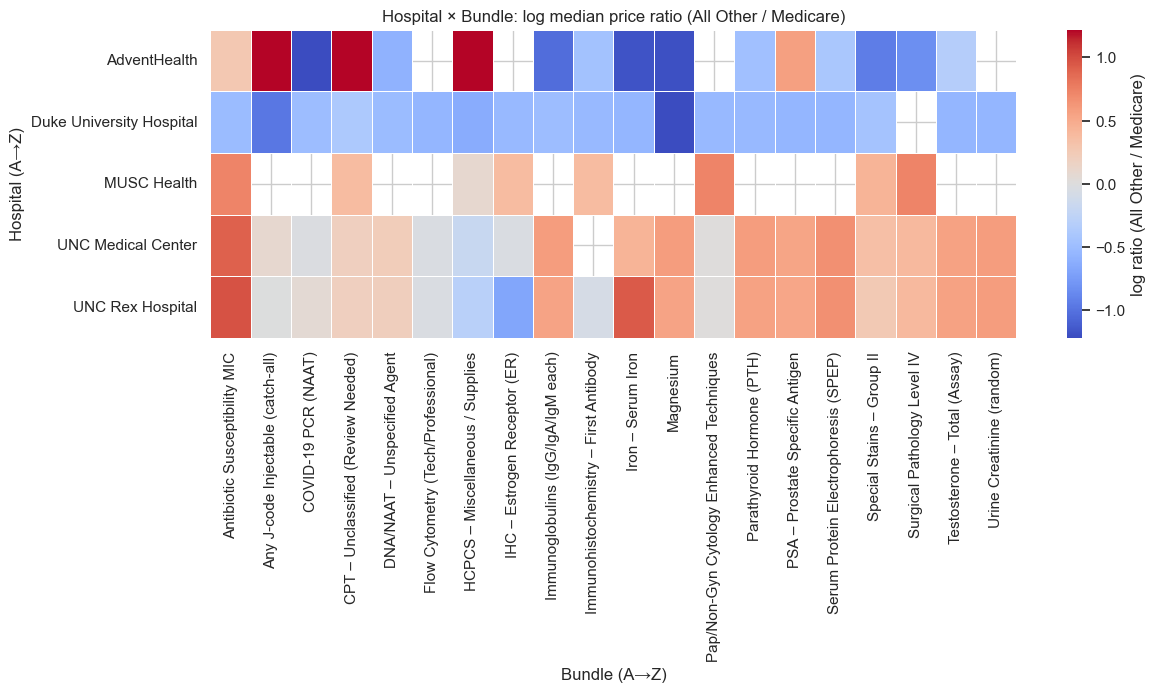

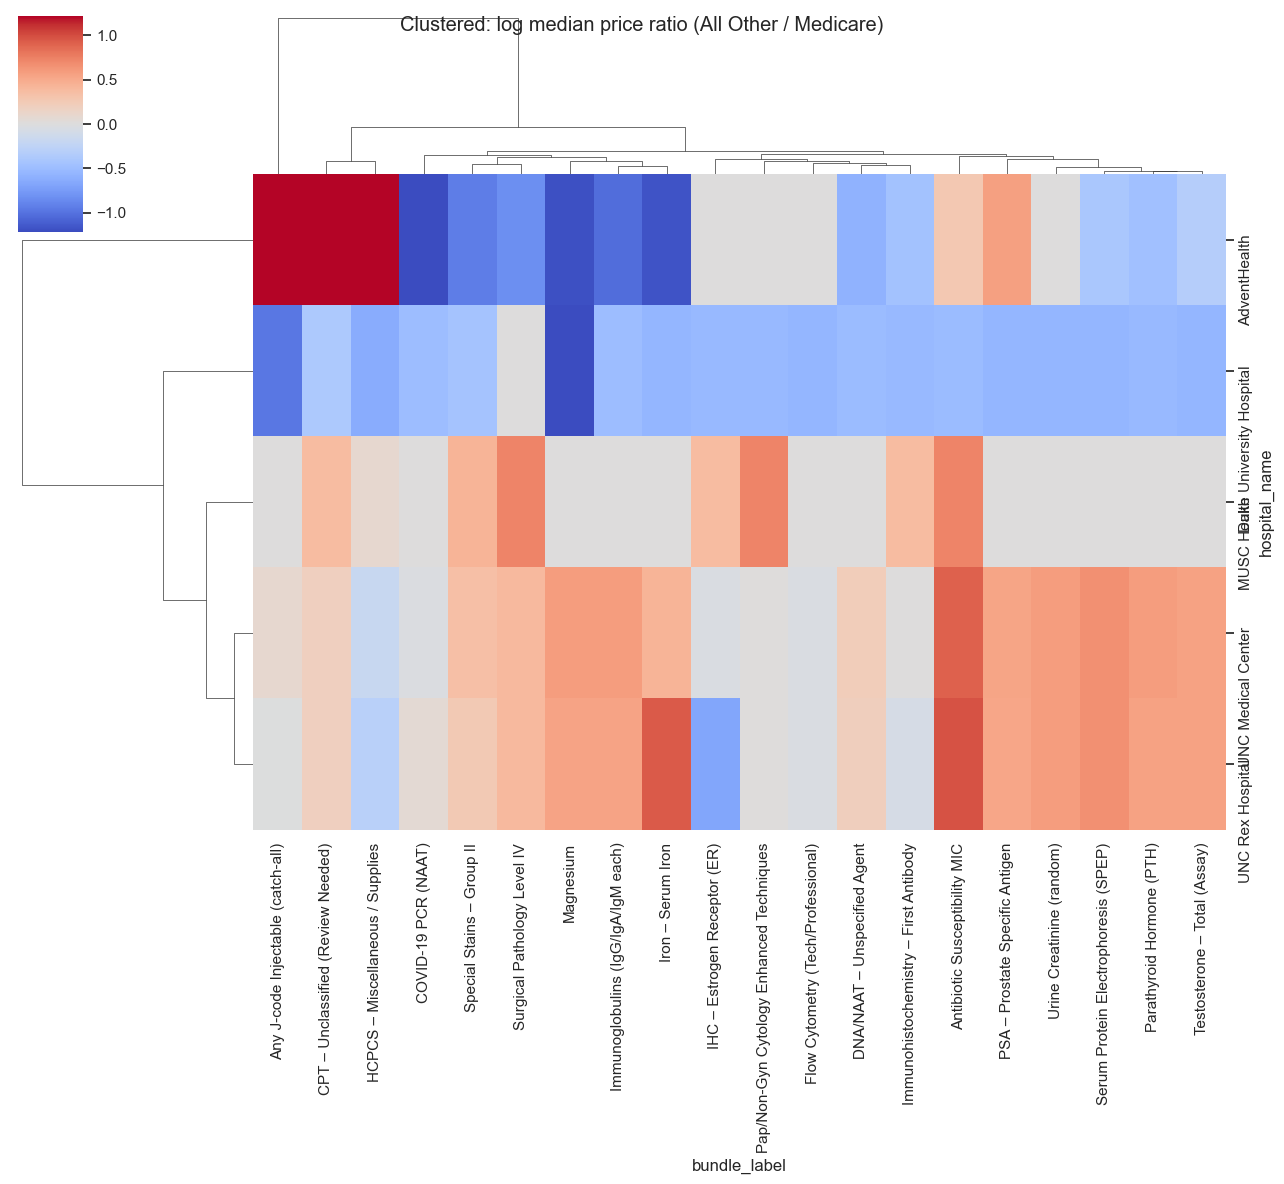

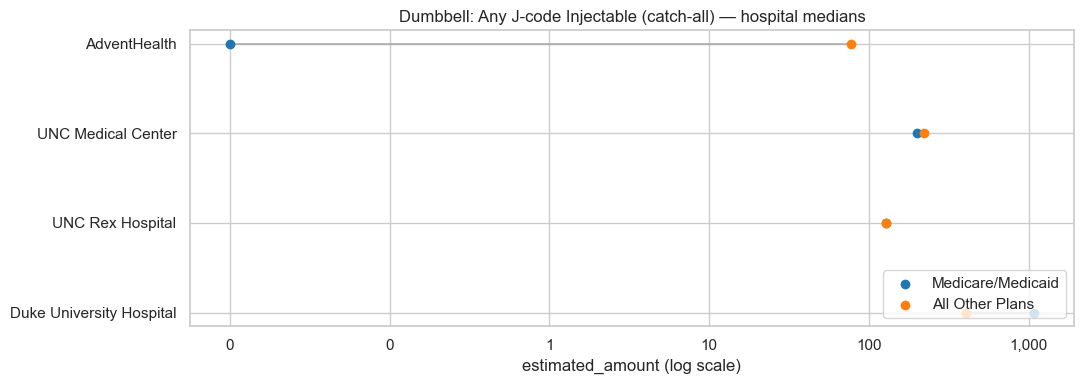

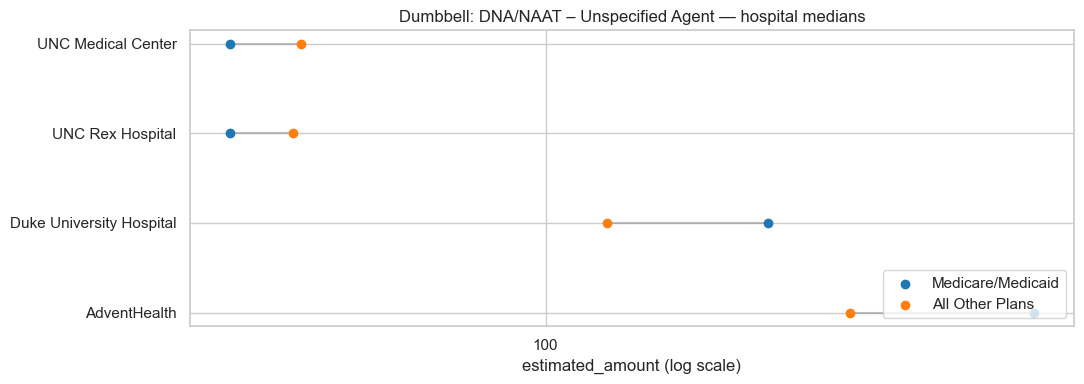

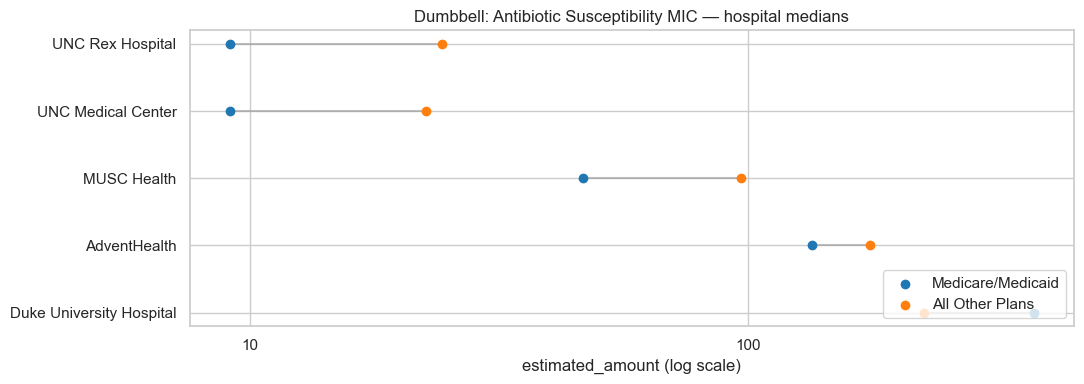

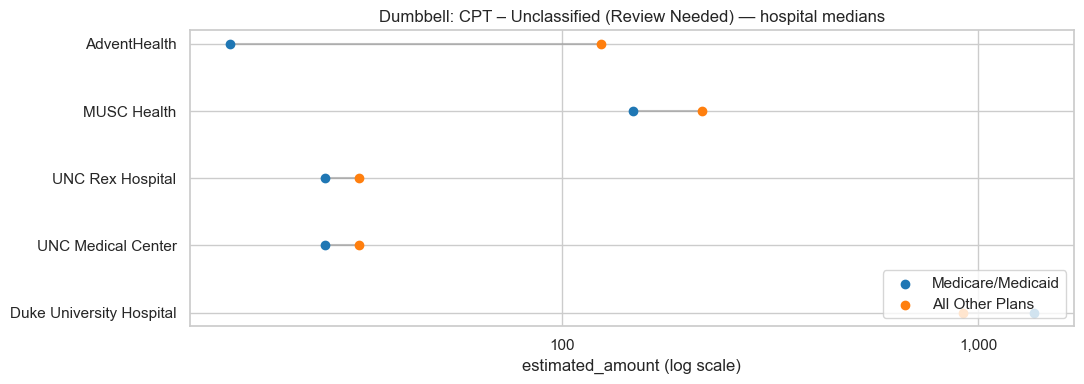

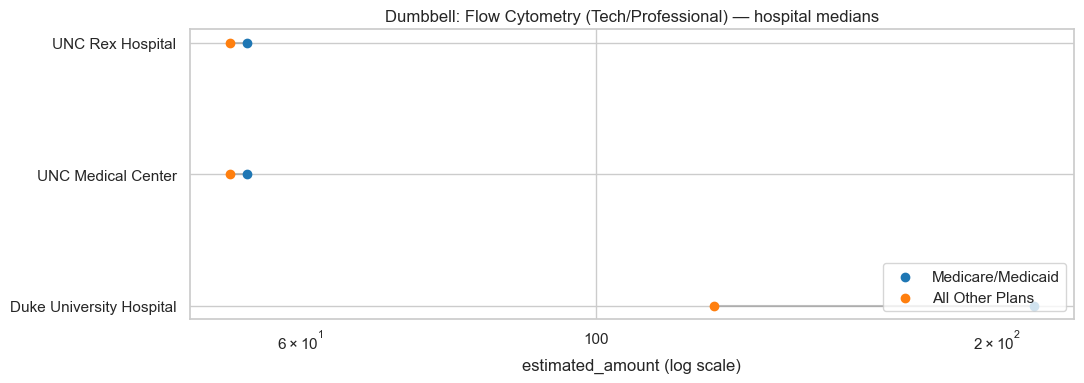

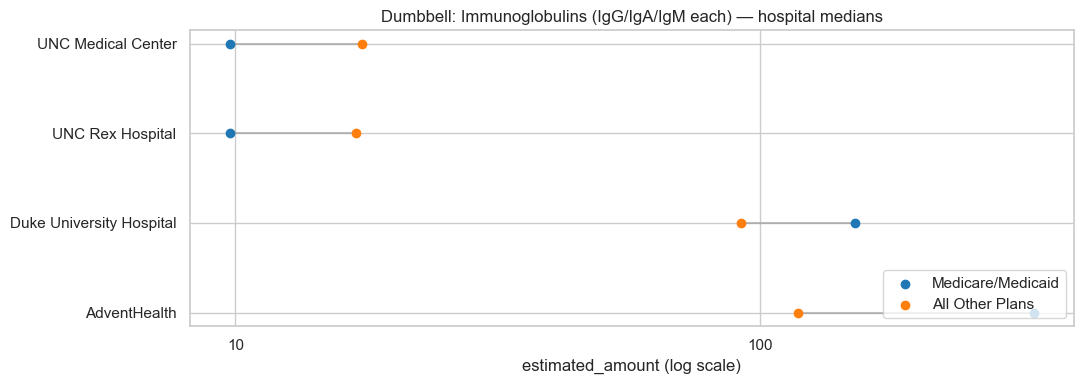

Saved matrix: c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\bundle_hospital_log_ratio_matrix.csv


In [110]:
# Comprehensive Discrepancy Visuals: Heatmaps and Dumbbells
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from pathlib import Path

sns.set_theme(style='whitegrid')

# Ensure required columns exist
if 'plan_bin_mm' not in df.columns:
    df['plan_bin_mm'] = derive_plan_bin_mm(df[COL_PLAN])

try:
    _df_b
except NameError:
    _df_b = df.copy()
    if 'bundle_label' not in _df_b.columns:
        raise RuntimeError("bundle_label is missing; please run the bundle mapping cell first.")

# Helper: median table by hospital × bundle × plan_bin

def bundle_medians(df_b: pd.DataFrame,
                   price_col: str = COL_PRICE_EST,
                   hue_bin: str = 'plan_bin_mm') -> pd.DataFrame:
    d = df_b.copy()
    d[price_col] = pd.to_numeric(d[price_col], errors='coerce')
    d = d[np.isfinite(d[price_col])]
    x_hosp = 'hospital_name' if 'hospital_name' in d.columns else COL_HOSPITAL
    g = (d.dropna(subset=['bundle_label'])
           .groupby([x_hosp, 'bundle_label', hue_bin], dropna=False)[price_col]
           .agg(['median', 'count']).reset_index())
    g.rename(columns={'median': 'median_price', 'count': 'n'}, inplace=True)
    return g

med = bundle_medians(_df_b)

# Build matrix of log median ratio: log(median AllOther / median Medicare)

def log_ratio_matrix(med_df: pd.DataFrame,
                     hue_bin: str = 'plan_bin_mm',
                     hosp_col: str = 'hospital_name') -> pd.DataFrame:
    pivot = (med_df.pivot_table(index=[hosp_col, 'bundle_label'],
                                columns=hue_bin,
                                values='median_price', aggfunc='median'))
    # Require both bins; compute natural-log ratio
    if {'All Other Plans','Medicare/Medicaid'}.issubset(set(pivot.columns)):
        ratio = np.log(pivot['All Other Plans']) - np.log(pivot['Medicare/Medicaid'])
    else:
        # Fallback: attempt case-insensitive matches
        cols = {c.lower(): c for c in pivot.columns}
        ratio = np.log(pivot[cols.get('all other plans')]) - np.log(pivot[cols.get('medicare/medicaid')])
    ratio = ratio.to_frame(name='log_ratio').reset_index()
    mat = ratio.pivot(index=hosp_col, columns='bundle_label', values='log_ratio')
    return mat

x_hosp = 'hospital_name' if 'hospital_name' in _df_b.columns else COL_HOSPITAL
mat = log_ratio_matrix(med, hosp_col=x_hosp)

# Select bundles to show
# If FDR results exist, use most significant; else use by prevalence
try:
    top_cols = (kw_b.sort_values(['q_value','p_value'], na_position='last')
                   .dropna(subset=['q_value'])
                   .head(20)['bundle_label'].tolist())
except Exception:
    counts = (_df_b.dropna(subset=['bundle_label'])
                    .groupby('bundle_label')[COL_PRICE_EST].size().sort_values(ascending=False))
    top_cols = counts.head(20).index.tolist()

mat_top = mat.loc[:, [c for c in top_cols if c in mat.columns]]

# Alphabetical sort of labels (A→Z)
mat_top = mat_top.copy()
mat_top = mat_top.loc[sorted(mat_top.index, key=lambda x: str(x).lower())]
mat_top = mat_top[sorted(mat_top.columns, key=lambda x: str(x).lower())]

# Use a clearer diverging scale focused on central values
v = np.nanpercentile(np.abs(mat_top.values), 95)
if not np.isfinite(v) or v == 0:
    v = 1.0

# Heatmap of log-ratio with improved contrast
plt.figure(figsize=(min(1+0.6*len(mat_top.columns), 22), min(1+0.6*len(mat_top.index), 12)))
ax = sns.heatmap(
    mat_top,
    cmap='coolwarm',
    center=0.0,
    vmin=-v,
    vmax=v,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'log ratio (All Other / Medicare)'}
)
plt.title('Hospital × Bundle: log median price ratio (All Other / Medicare)')
plt.xlabel('Bundle (A→Z)')
plt.ylabel('Hospital (A→Z)')
plt.tight_layout()
plt.show()

# Optional: clustered heatmap to reveal structure (same color scaling)
try:
    from seaborn import clustermap
    cg = sns.clustermap(
        mat_top.fillna(0.0),
        cmap='coolwarm',
        center=0.0,
        vmin=-v,
        vmax=v,
        figsize=(min(1+0.6*len(mat_top.columns), 22), 12)
    )
    cg.fig.suptitle('Clustered: log median price ratio (All Other / Medicare)')
    plt.show()
except Exception:
    pass

# Dumbbell plot for top 6 bundles: show medians per hospital for both bins

def dumbbell_for_bundle(med_df: pd.DataFrame, bundle_label: str, price_col: str = 'median_price'):
    dfb = med_df[med_df['bundle_label'] == bundle_label].copy()
    if dfb.empty:
        print(f"No data for bundle '{bundle_label}'")
        return
    # Pivot to two columns
    pv = dfb.pivot_table(index=x_hosp, columns='plan_bin_mm', values=price_col, aggfunc='median')
    if not {'All Other Plans','Medicare/Medicaid'}.issubset(pv.columns):
        print(f"Bundle '{bundle_label}': missing one of the plan bins; skipping")
        return
    pv = pv.dropna(subset=['All Other Plans','Medicare/Medicaid'])
    if pv.empty:
        print(f"Bundle '{bundle_label}': insufficient paired data")
        return
    order = pv.apply(lambda r: np.log(r['All Other Plans']) - np.log(r['Medicare/Medicaid']), axis=1).sort_values().index
    pv = pv.loc[order]
    y = np.arange(len(pv))
    plt.figure(figsize=(11, max(4, 0.35*len(pv))))
    plt.hlines(y=y, xmin=pv['Medicare/Medicaid'], xmax=pv['All Other Plans'], color='#999999', alpha=0.6)
    plt.scatter(pv['Medicare/Medicaid'], y, color=PALETTE_MM.get('Medicare/Medicaid', '#1f77b4'), label='Medicare/Medicaid', zorder=3)
    plt.scatter(pv['All Other Plans'], y, color=PALETTE_MM.get('All Other Plans', '#ff7f0e'), label='All Other Plans', zorder=3)
    plt.xscale('log')
    plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    plt.yticks(y, pv.index)
    plt.xlabel(COL_PRICE_EST + ' (log scale)')
    plt.title(f"Dumbbell: {bundle_label} — hospital medians")
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Plot dumbbells for top 6 by significance (or prevalence fallback)
for b in top_cols[:6]:
    dumbbell_for_bundle(med, b)

# Save figures to disk
out_dir = _data_dir / 'bundles_out'
out_dir.mkdir(parents=True, exist_ok=True)

# Save heatmap matrix for downstream use
mat_top.to_csv(out_dir / 'bundle_hospital_log_ratio_matrix.csv')
print('Saved matrix:', out_dir / 'bundle_hospital_log_ratio_matrix.csv')

Comparing 79 payer/plan combinations (each with ≥50 code entries)


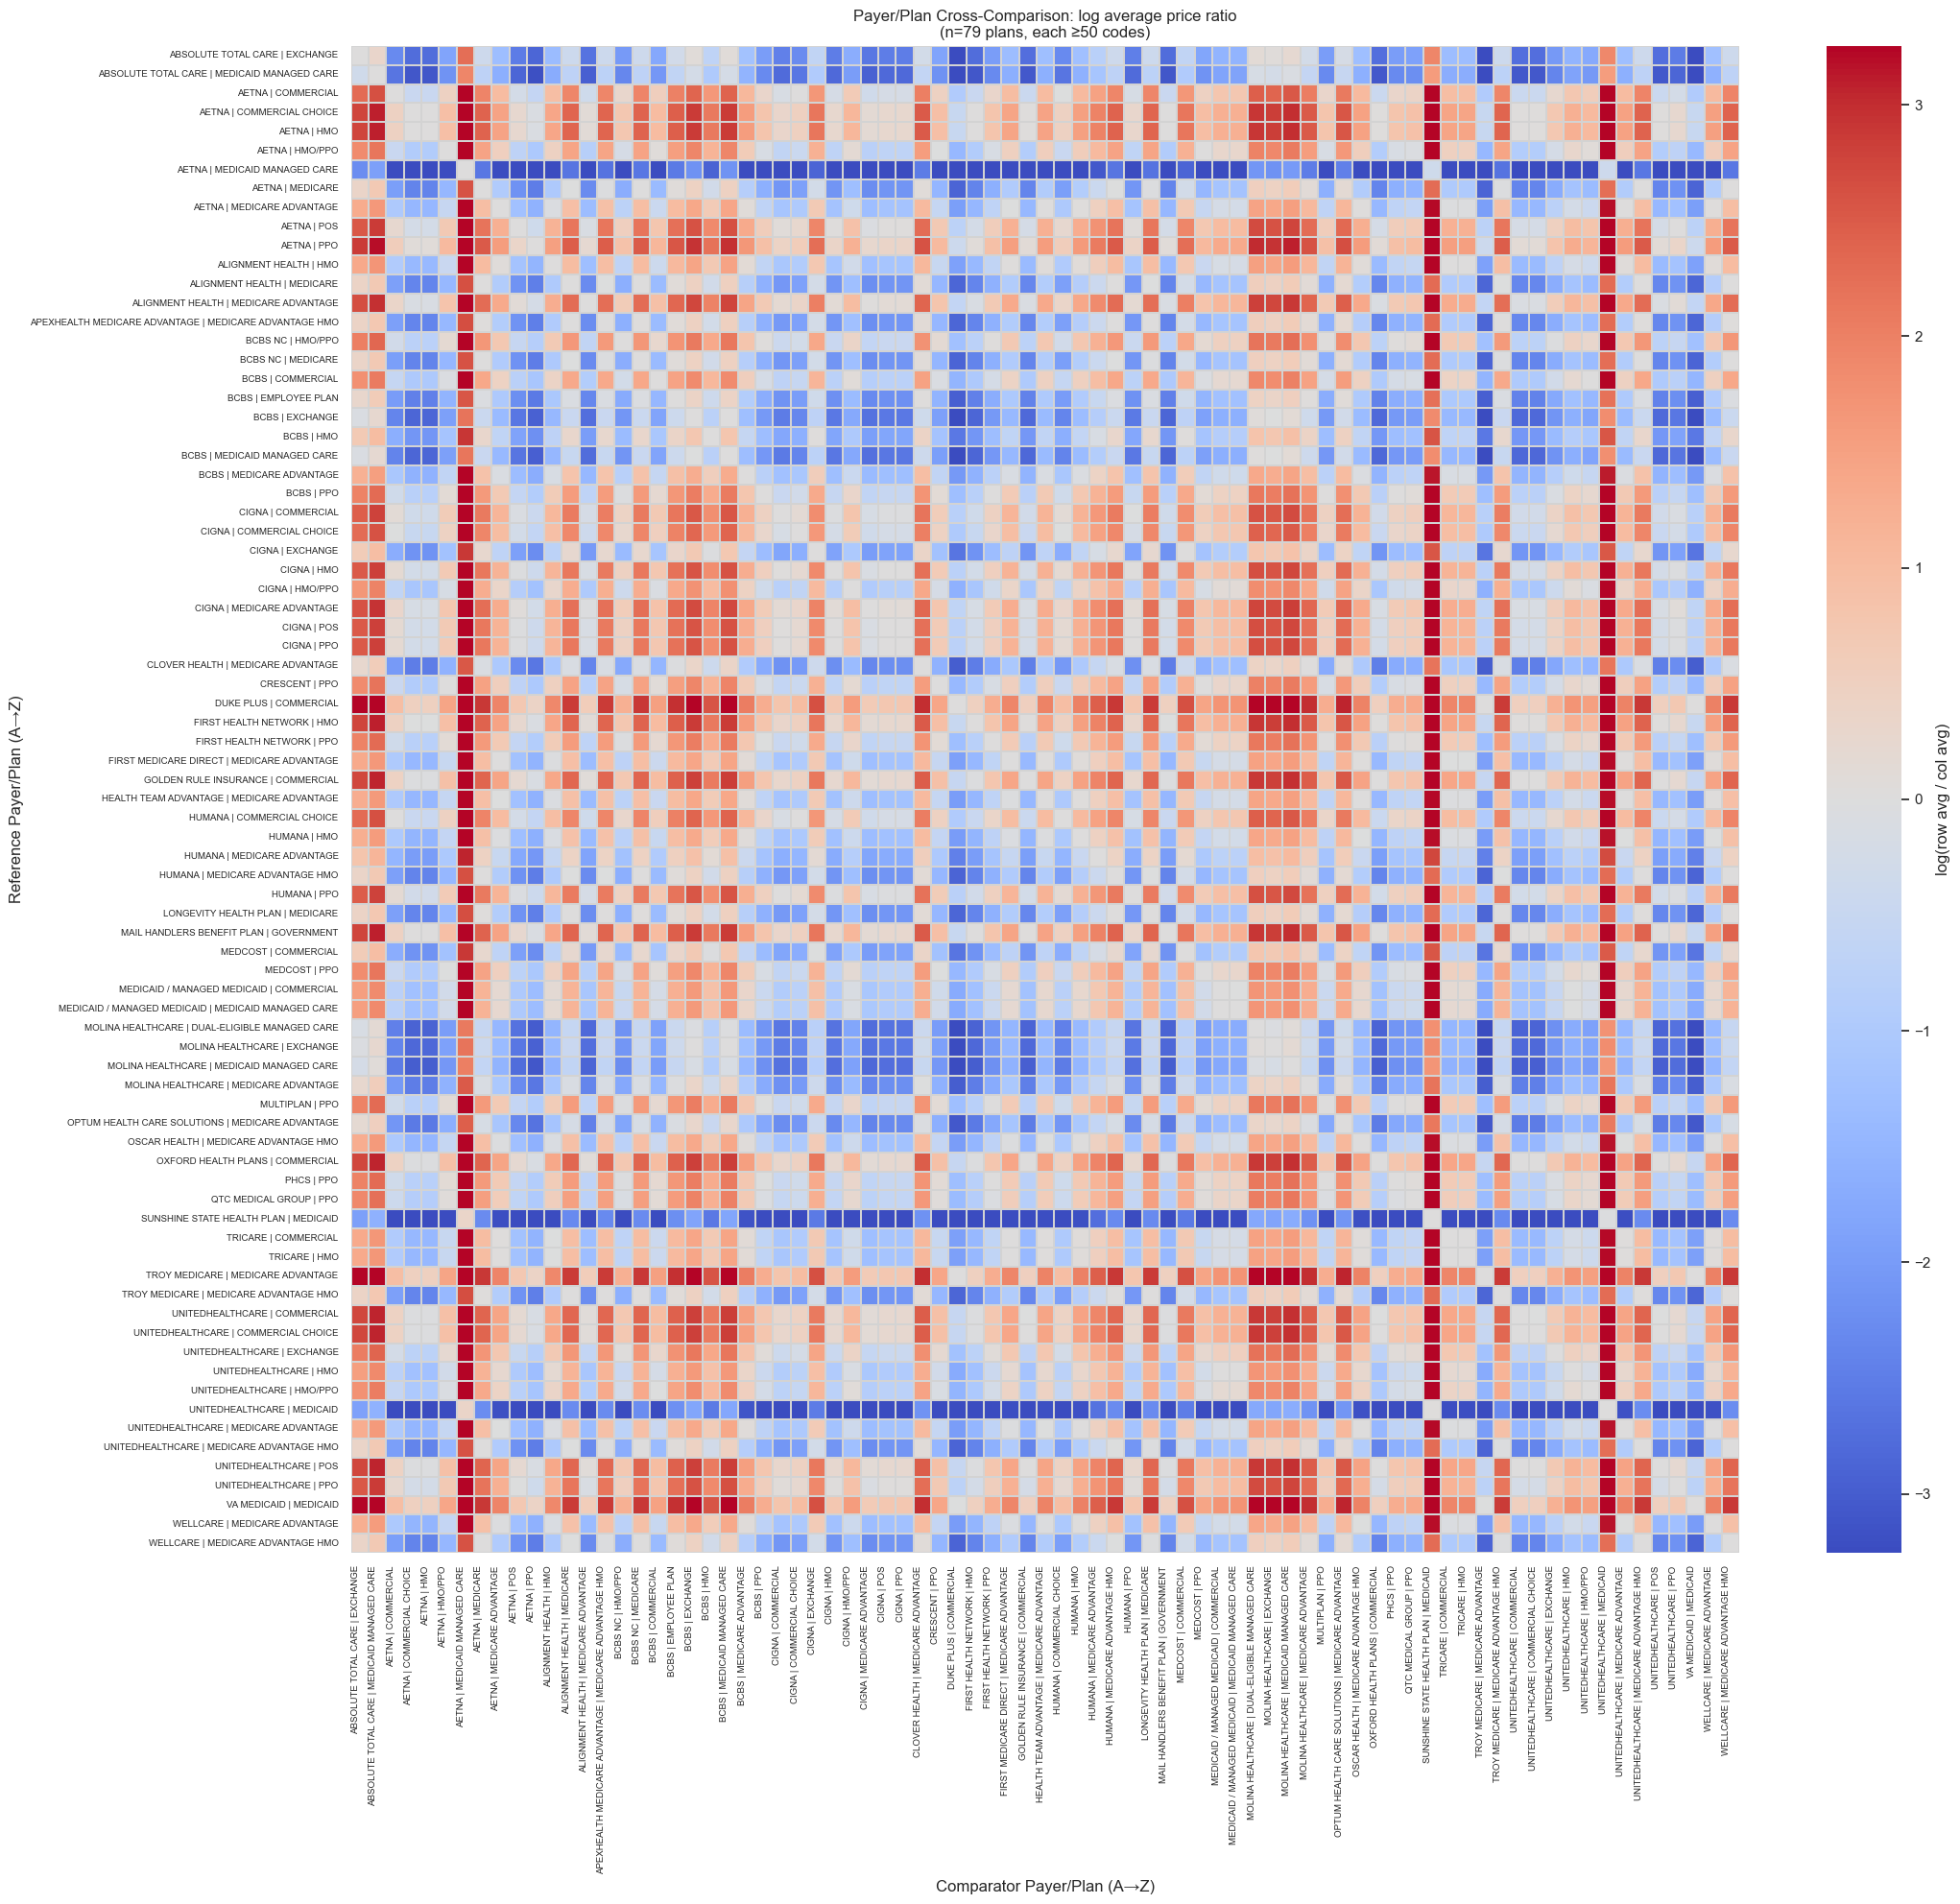

Saved outputs:
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\heatmap_payer_plan_comparison.png
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\payer_plan_log_ratio_matrix.csv
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\payer_plan_avg_prices.csv


In [105]:
# Payer/Plan Cross-Comparison Heatmap: Average Price Across All Codes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

sns.set_theme(style='whitegrid')

# Compute average price per payer/plan across all their offered codes
d = df.copy()
d[COL_PRICE_EST] = pd.to_numeric(d[COL_PRICE_EST], errors='coerce')
d = d[np.isfinite(d[COL_PRICE_EST])]

# Create combined payer_plan identifier
d['payer_plan'] = d[COL_PAYER].astype(str) + ' | ' + d[COL_PLAN].astype(str)

# Compute mean price per payer_plan
avg_prices = (d.groupby('payer_plan')[COL_PRICE_EST]
               .agg(['mean', 'count']).reset_index())
avg_prices.columns = ['payer_plan', 'avg_price', 'n_codes']

# Filter to payer/plans with sufficient data (e.g., >= 50 code entries)
min_codes = 50
avg_prices = avg_prices[avg_prices['n_codes'] >= min_codes].copy()

print(f"Comparing {len(avg_prices)} payer/plan combinations (each with ≥{min_codes} code entries)")

# Build ratio matrix: log(row_price / col_price)
payer_plans = avg_prices['payer_plan'].tolist()
prices = avg_prices.set_index('payer_plan')['avg_price']

ratio_matrix = pd.DataFrame(index=payer_plans, columns=payer_plans, dtype=float)
for i in payer_plans:
    for j in payer_plans:
        if i == j:
            ratio_matrix.loc[i, j] = 0.0  # same plan
        else:
            ratio_matrix.loc[i, j] = np.log(prices[i] / prices[j])

# Alphabetical ordering (A→Z) for labels
order = sorted(prices.index, key=lambda x: x.lower())
ratio_matrix = ratio_matrix.loc[order, order]

# Improved diverging scale focused near zero
v = np.nanpercentile(np.abs(ratio_matrix.values.astype(float)), 95)
if not np.isfinite(v) or v == 0:
    v = 1.0

# Plot heatmap
fig_height = min(max(8, 0.3 * len(ratio_matrix)), 20)
fig_width = min(max(10, 0.3 * len(ratio_matrix)), 22)

plt.figure(figsize=(fig_width, fig_height))
ax = sns.heatmap(
    ratio_matrix.astype(float),
    cmap='coolwarm',
    center=0.0,
    vmin=-v,
    vmax=v,
    linewidths=0.2,
    linecolor='lightgray',
    cbar_kws={'label': 'log(row avg / col avg)'}
)
plt.title(f'Payer/Plan Cross-Comparison: log average price ratio\n(n={len(ratio_matrix)} plans, each ≥{min_codes} codes)')
plt.xlabel('Comparator Payer/Plan (A→Z)')
plt.ylabel('Reference Payer/Plan (A→Z)')
plt.xticks(rotation=90, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

out_dir = _data_dir / 'bundles_out'
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'heatmap_payer_plan_comparison.png', dpi=600)
plt.savefig(out_dir / 'heatmap_payer_plan_comparison.pdf')
plt.show()

# Also save the ratio matrix and avg prices
ratio_matrix.to_csv(out_dir / 'payer_plan_log_ratio_matrix.csv')
avg_prices.to_csv(out_dir / 'payer_plan_avg_prices.csv', index=False)

print('Saved outputs:')
print(' -', out_dir / 'heatmap_payer_plan_comparison.png')
print(' -', out_dir / 'payer_plan_log_ratio_matrix.csv')
print(' -', out_dir / 'payer_plan_avg_prices.csv')

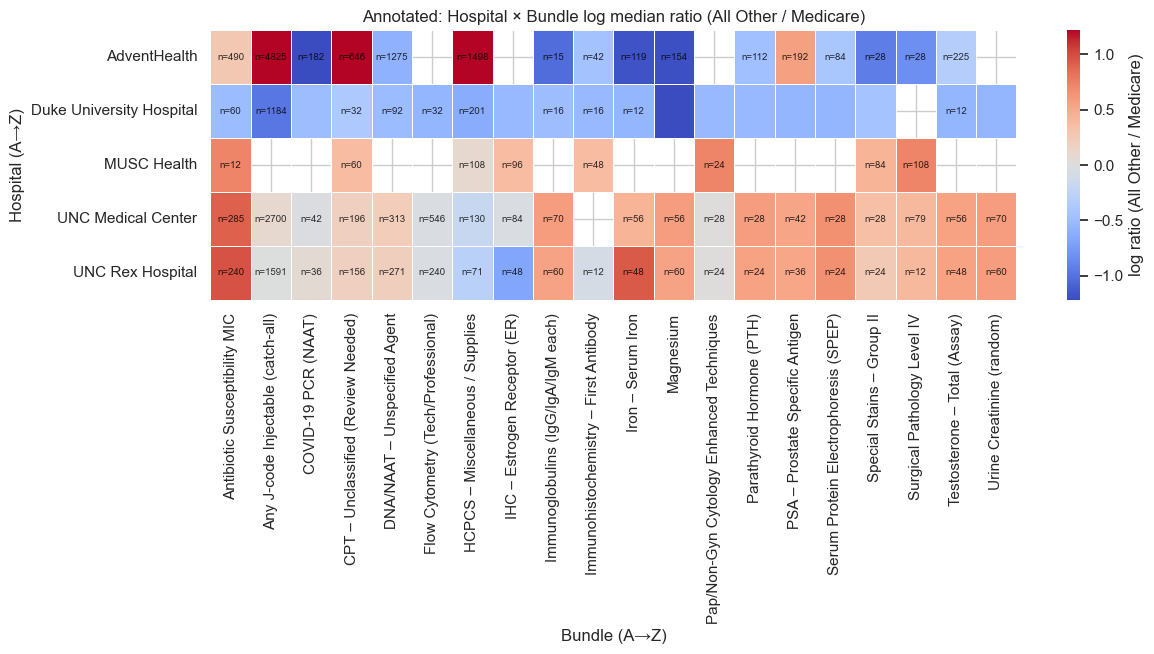

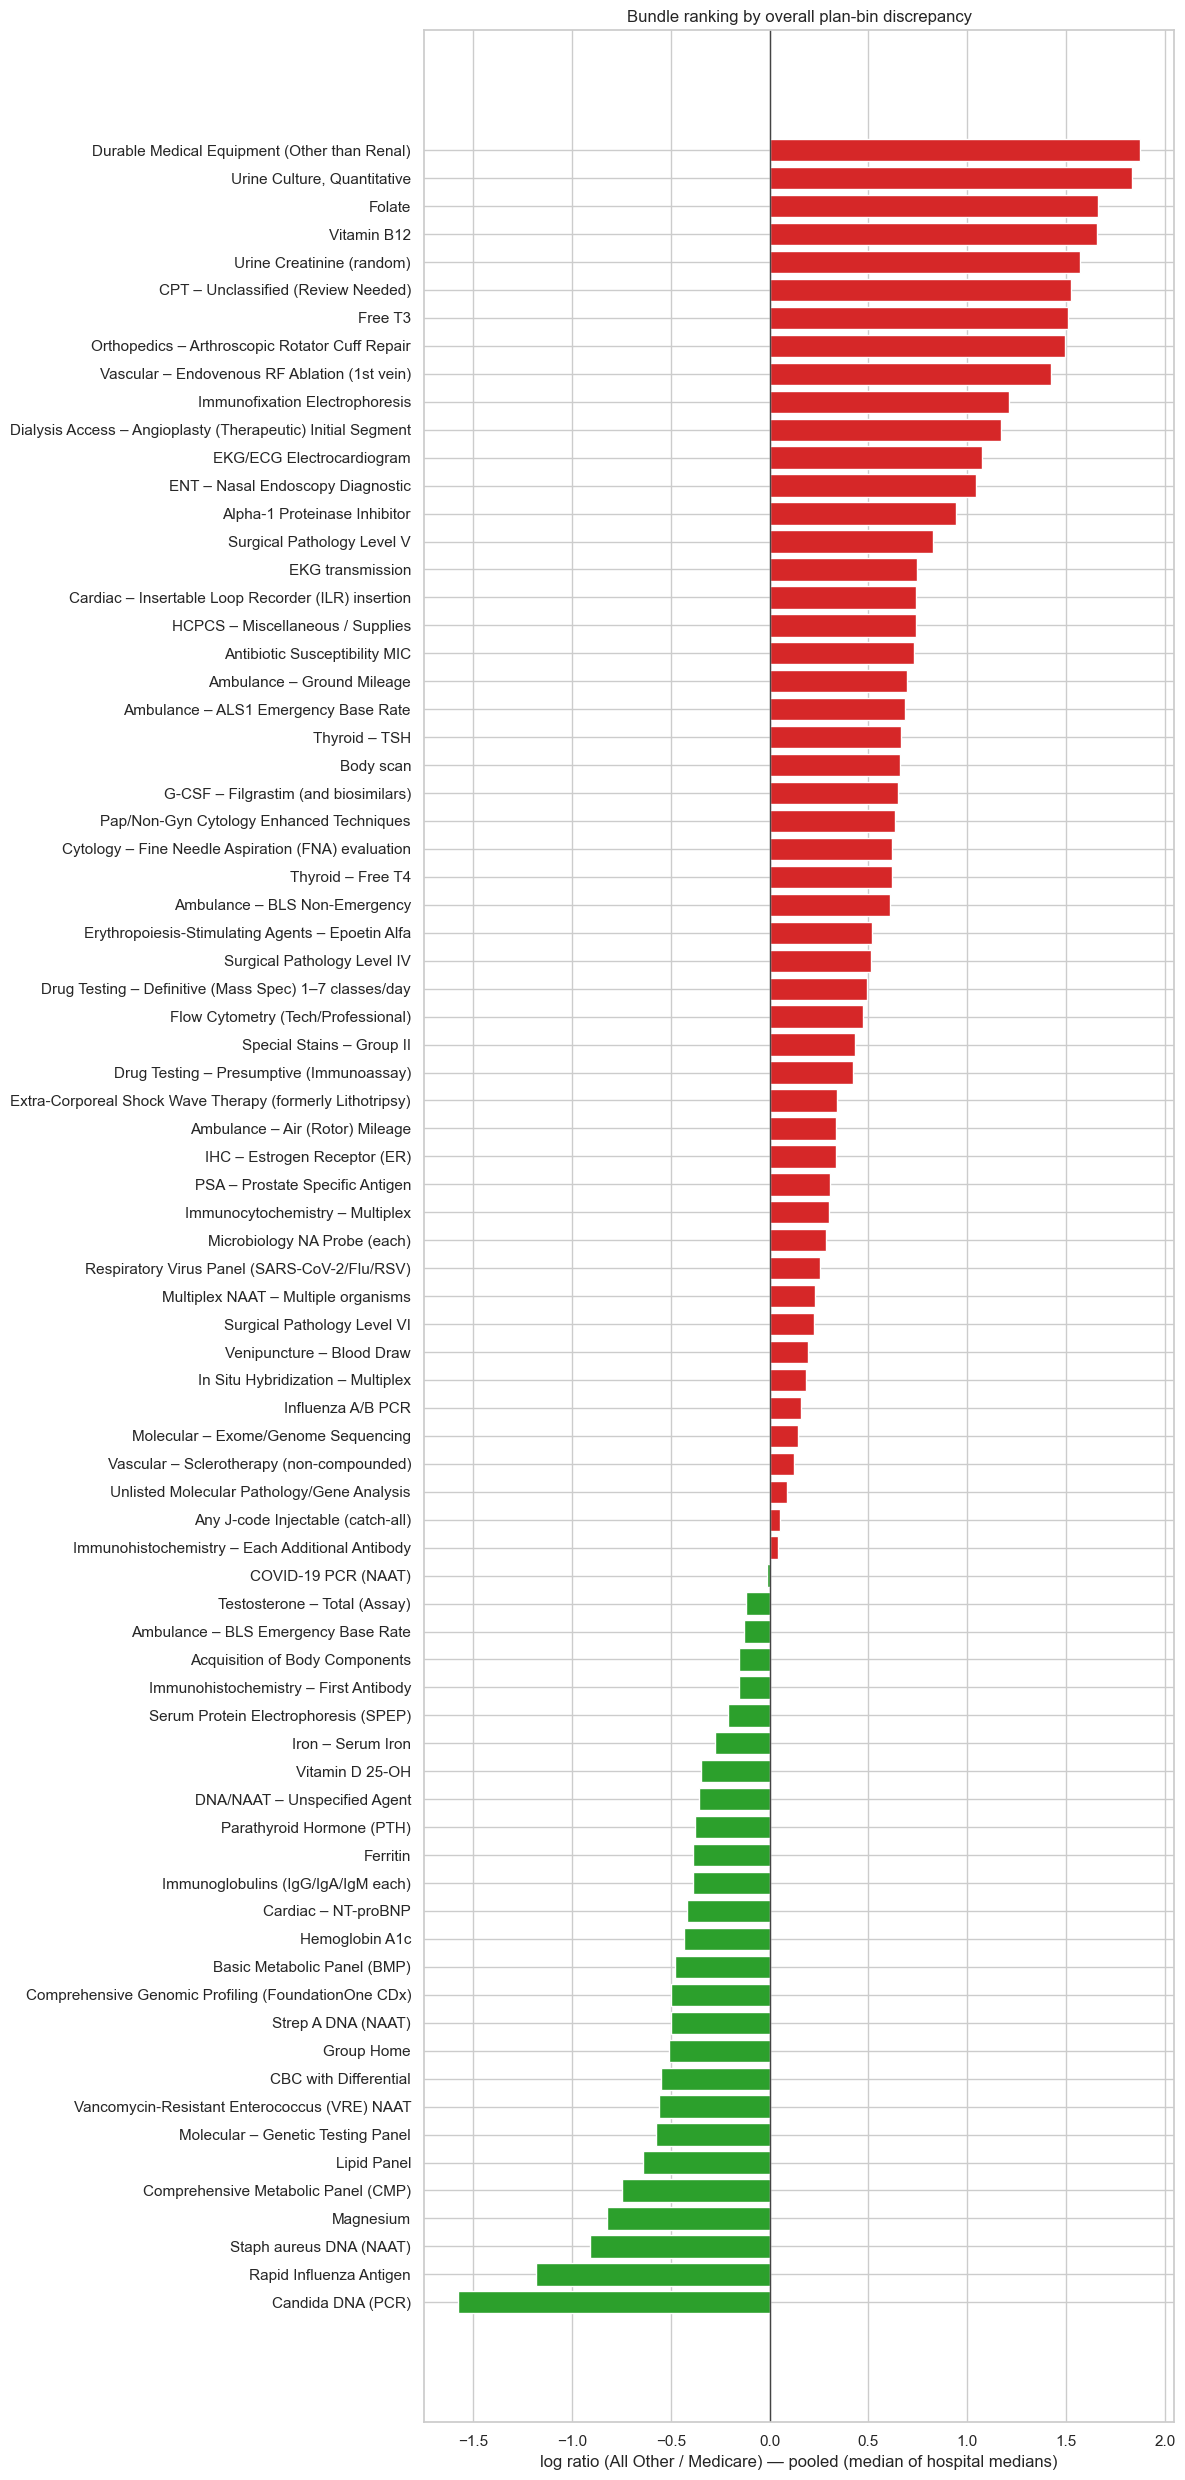

Saved figures:
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\heatmap_bundle_discrepancy_annot.png
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\bundle_discrepancy_ranking.png


In [103]:
# Discrepancy Dashboard: Annotated Heatmap + Bundle Ranking
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from pathlib import Path

sns.set_theme(style='whitegrid')

# Reuse medians from prior cell or recompute
try:
    med
except NameError:
    def bundle_medians(df_b: pd.DataFrame,
                       price_col: str = COL_PRICE_EST,
                       hue_bin: str = 'plan_bin_mm') -> pd.DataFrame:
        d = df_b.copy()
        d[price_col] = pd.to_numeric(d[price_col], errors='coerce')
        d = d[np.isfinite(d[price_col])]
        x_hosp = 'hospital_name' if 'hospital_name' in d.columns else COL_HOSPITAL
        g = (d.dropna(subset=['bundle_label'])
               .groupby([x_hosp, 'bundle_label', hue_bin], dropna=False)[price_col]
               .agg(['median', 'count']).reset_index())
        g.rename(columns={'median': 'median_price', 'count': 'n'}, inplace=True)
        return g
    med = bundle_medians(_df_b)

x_hosp = 'hospital_name' if 'hospital_name' in _df_b.columns else COL_HOSPITAL

# Build paired counts per (hospital,bundle)
counts = med.pivot_table(index=[x_hosp, 'bundle_label'], columns='plan_bin_mm', values='n', aggfunc='sum')
counts = counts.fillna(0)
if {'All Other Plans','Medicare/Medicaid'}.issubset(counts.columns):
    paired_n = counts[['All Other Plans','Medicare/Medicaid']].min(axis=1)
else:
    cols = {c.lower(): c for c in counts.columns}
    paired_n = counts[[cols.get('all other plans'), cols.get('medicare/medicaid')]].min(axis=1)
paired_n = paired_n.to_frame('paired_n').reset_index()

# Log-ratio matrix from previous cell
try:
    mat_top
    mat = mat_top  # use previously selected columns
except NameError:
    def log_ratio_matrix(med_df: pd.DataFrame,
                         hue_bin: str = 'plan_bin_mm',
                         hosp_col: str = 'hospital_name') -> pd.DataFrame:
        pivot = (med_df.pivot_table(index=[hosp_col, 'bundle_label'],
                                    columns=hue_bin,
                                    values='median_price', aggfunc='median'))
        if {'All Other Plans','Medicare/Medicaid'}.issubset(set(pivot.columns)):
            ratio = np.log(pivot['All Other Plans']) - np.log(pivot['Medicare/Medicaid'])
        else:
            cols = {c.lower(): c for c in pivot.columns}
            ratio = np.log(pivot[cols.get('all other plans')]) - np.log(pivot[cols.get('medicare/medicaid')])
        ratio = ratio.to_frame(name='log_ratio').reset_index()
        return ratio.pivot(index=hosp_col, columns='bundle_label', values='log_ratio')
    mat = log_ratio_matrix(med, hosp_col=x_hosp)

# Alphabetical order for labels (A→Z)
row_order = sorted(mat.index, key=lambda x: str(x).lower())
col_order = sorted(mat.columns, key=lambda x: str(x).lower())
mat_ord = mat.loc[row_order, col_order]

# Build paired counts matrix aligned to mat_ord for optional annotations
paired_wide = paired_n.pivot(index=x_hosp, columns='bundle_label', values='paired_n').reindex(index=mat_ord.index, columns=mat_ord.columns)

# Improved diverging scale around zero
v = np.nanpercentile(np.abs(mat_ord.values), 95)
if not np.isfinite(v) or v == 0:
    v = 1.0

# Plot annotated heatmap (annotate with paired_n where >= 10)
plt.figure(figsize=(min(1+0.6*len(mat_ord.columns), 22), min(1+0.5*len(mat_ord.index), 14)))
ax = sns.heatmap(
    mat_ord,
    cmap='coolwarm',
    center=0.0,
    vmin=-v,
    vmax=v,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'log ratio (All Other / Medicare)'}
)
# Add annotations sparsely to avoid clutter
for i, h in enumerate(mat_ord.index):
    for j, b in enumerate(mat_ord.columns):
        nval = paired_wide.loc[h, b]
        if pd.notna(nval) and nval >= 10:
            ax.text(j+0.5, i+0.5, f"n={int(nval)}", ha='center', va='center', fontsize=7, color='black', alpha=0.8)
plt.title('Annotated: Hospital × Bundle log median ratio (All Other / Medicare)')
plt.xlabel('Bundle (A→Z)')
plt.ylabel('Hospital (A→Z)')
plt.tight_layout()

out_dir = _data_dir / 'bundles_out'
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'heatmap_bundle_discrepancy_annot.png', dpi=600)
plt.savefig(out_dir / 'heatmap_bundle_discrepancy_annot.pdf')
plt.show()

# Bundle ranking bar chart (overall pooled disparity using median of hospital medians)
pv = med.pivot_table(index=['bundle_label','plan_bin_mm'], values='median_price', aggfunc='median').reset_index()
pv_w = pv.pivot(index='bundle_label', columns='plan_bin_mm', values='median_price')
pv_w = pv_w.dropna(subset=['All Other Plans','Medicare/Medicaid'], how='any')
pv_w['log_ratio'] = np.log(pv_w['All Other Plans']) - np.log(pv_w['Medicare/Medicaid'])
pv_w = pv_w.sort_values('log_ratio', ascending=True)

plt.figure(figsize=(12, max(6, 0.32*len(pv_w))))
ax = plt.barh(pv_w.index, pv_w['log_ratio'], color=['#2ca02c' if v<0 else '#d62728' for v in pv_w['log_ratio']])
plt.axvline(0, color='#444', linewidth=1)
plt.xlabel('log ratio (All Other / Medicare) — pooled (median of hospital medians)')
plt.title('Bundle ranking by overall plan-bin discrepancy')
plt.tight_layout()
plt.savefig(out_dir / 'bundle_discrepancy_ranking.png', dpi=600)
plt.savefig(out_dir / 'bundle_discrepancy_ranking.pdf')
plt.show()

print('Saved figures:')
print(' -', out_dir / 'heatmap_bundle_discrepancy_annot.png')
print(' -', out_dir / 'bundle_discrepancy_ranking.png')

Comparing 79 payer/plan combinations (each with ≥50 code entries)

=== MIN PRICE COMPARISON ===


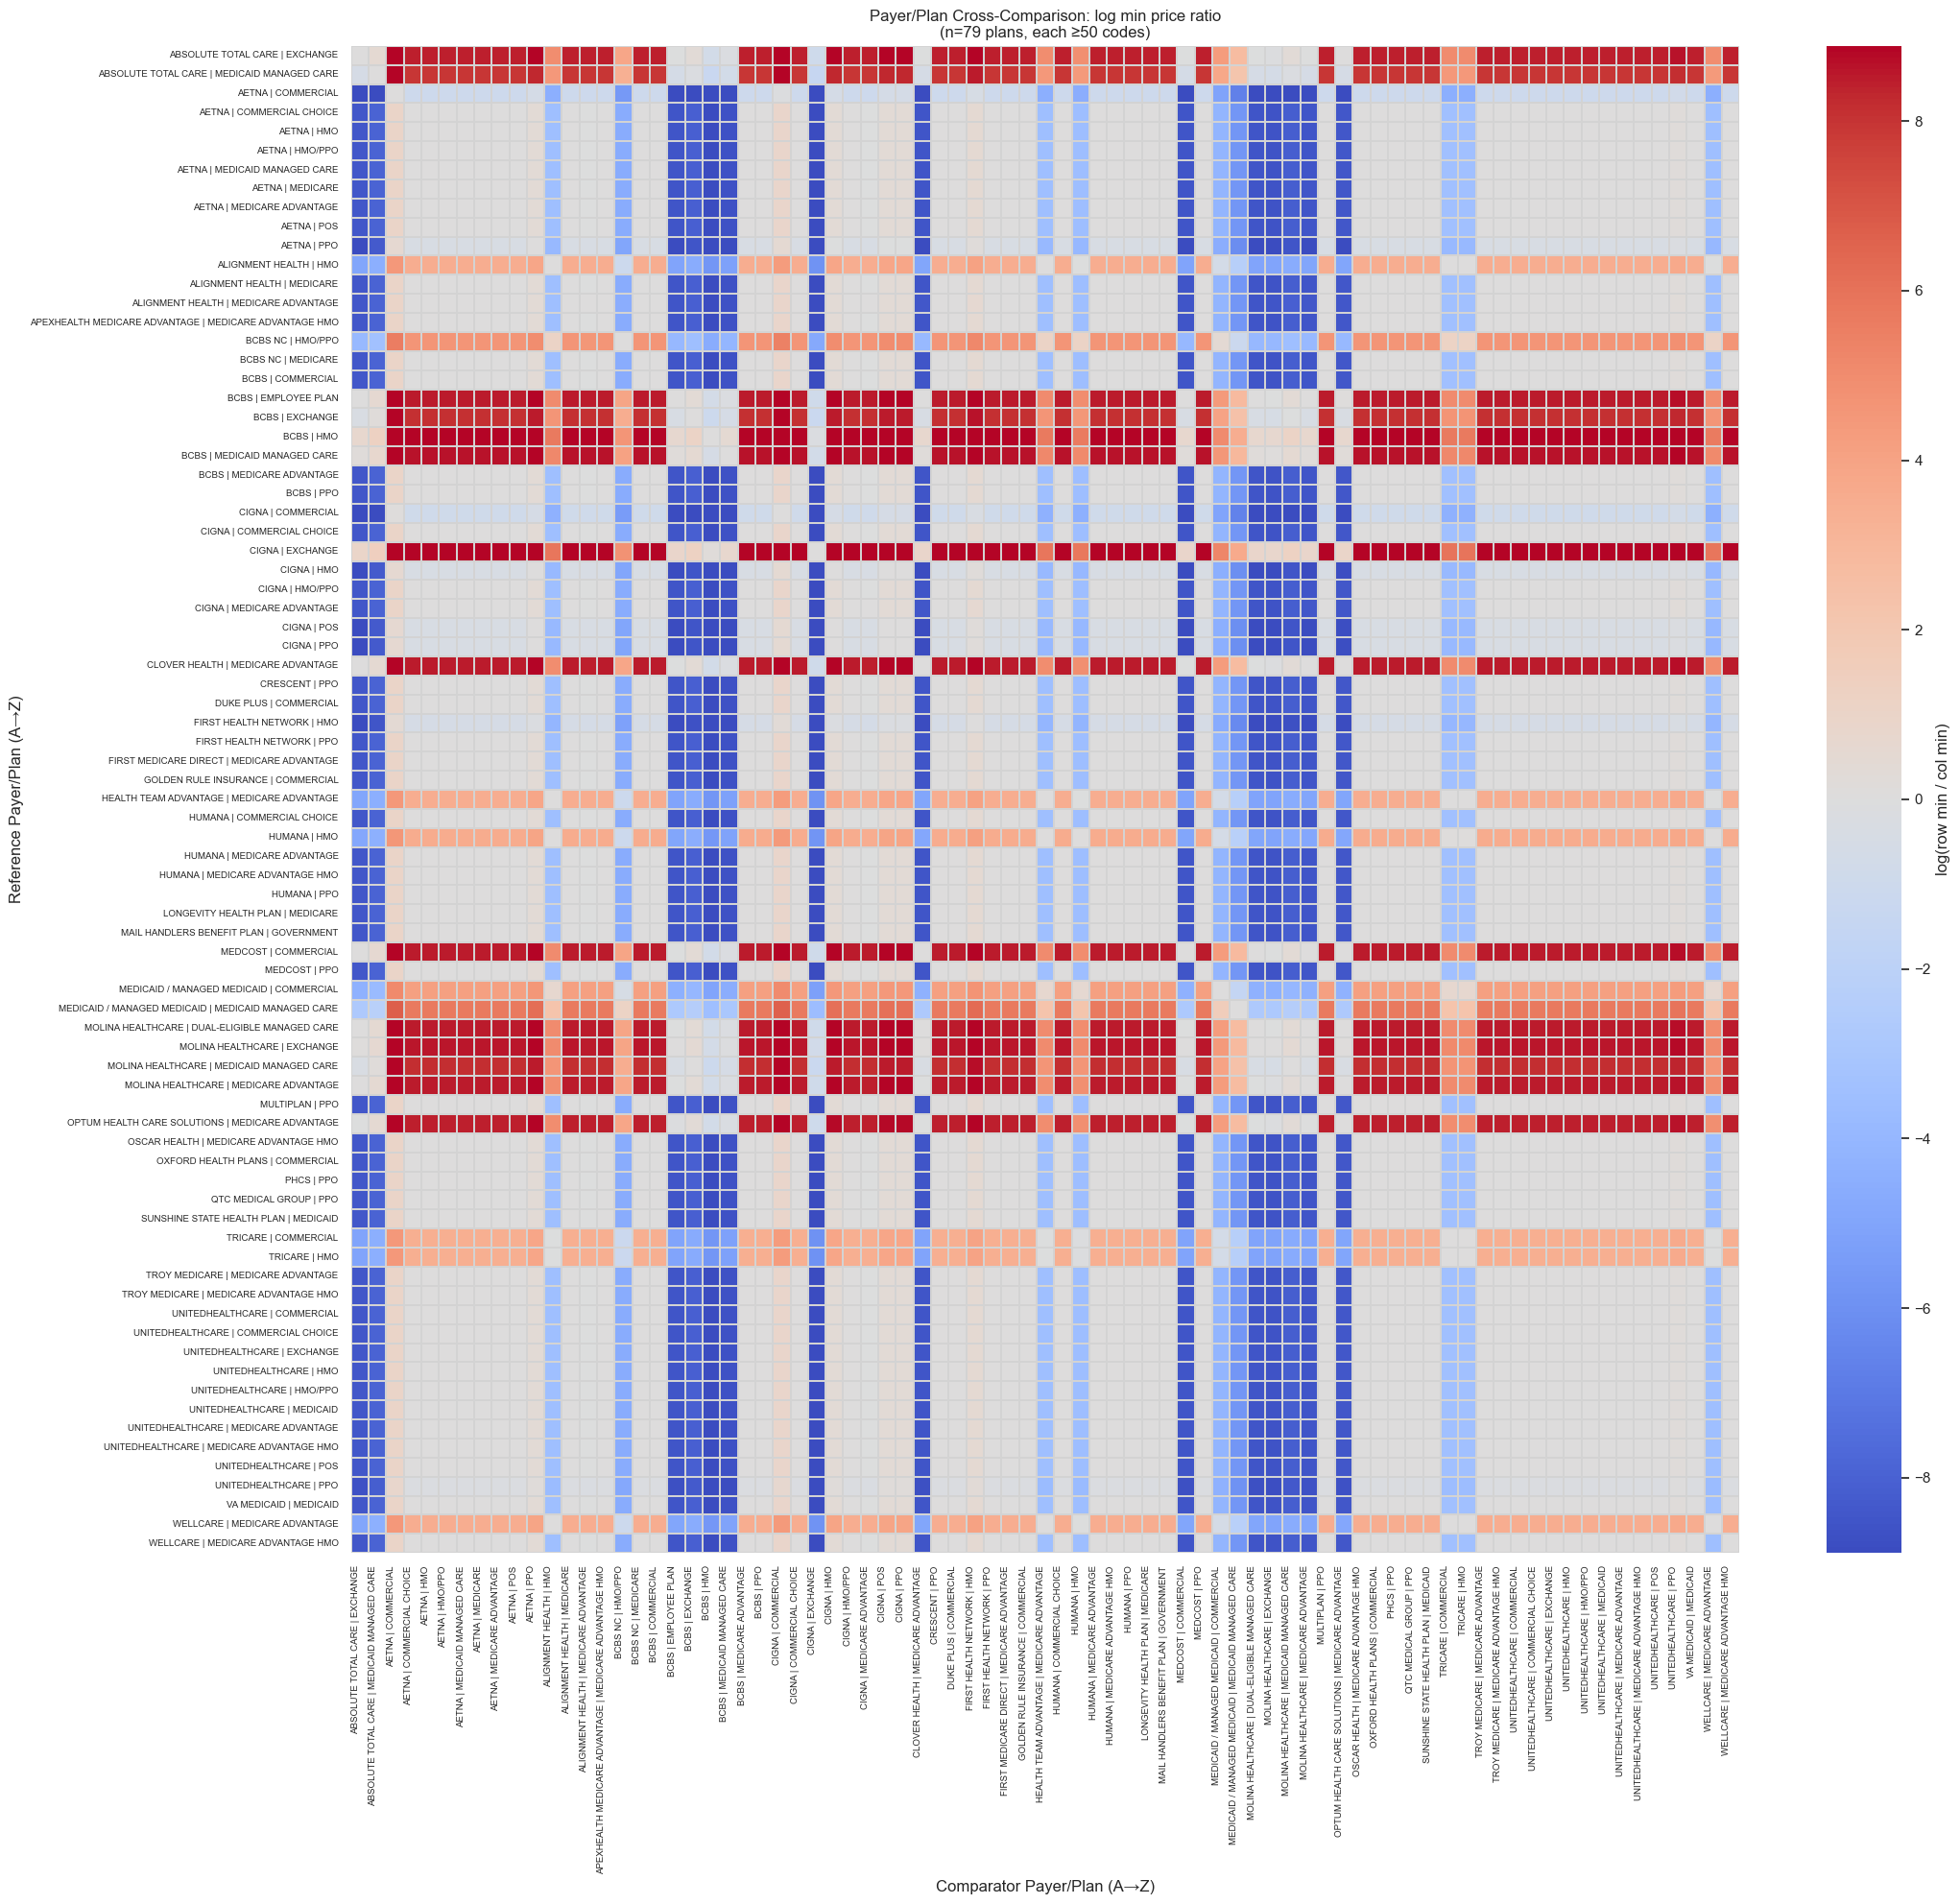


=== MAX PRICE COMPARISON ===


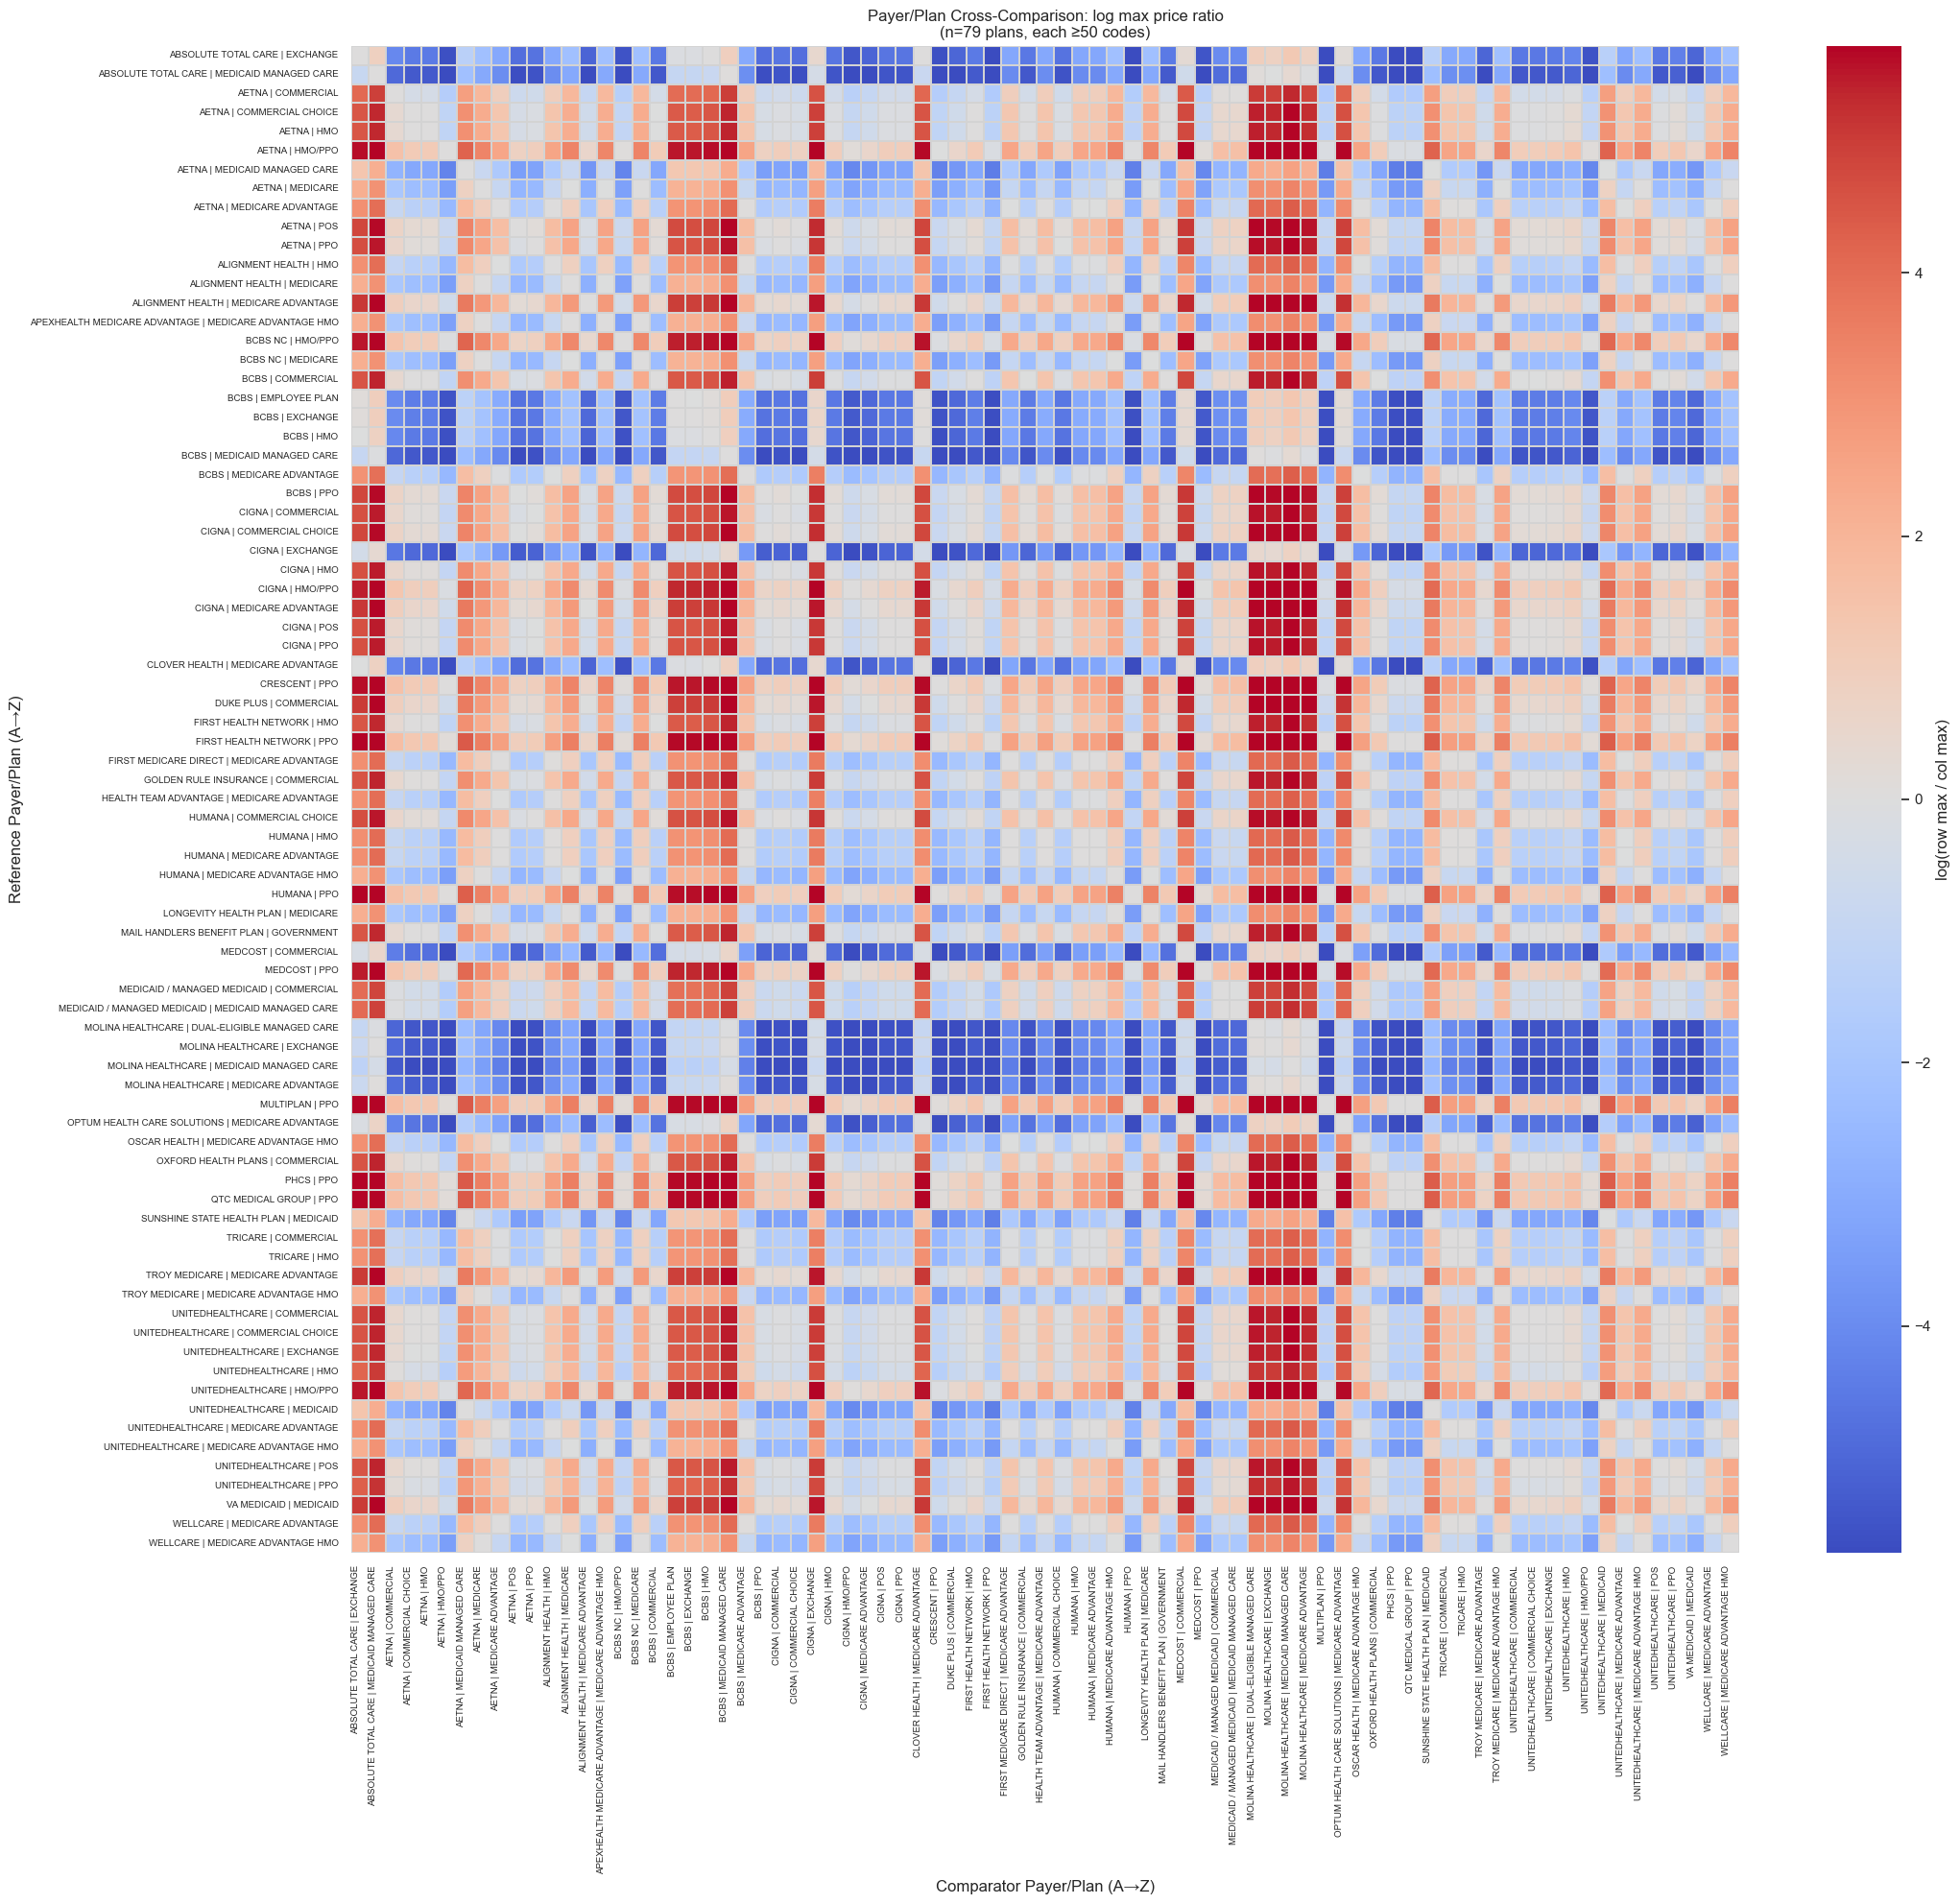


Saved outputs:
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\heatmap_min_payer_plan_comparison.png
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\heatmap_max_payer_plan_comparison.png
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\heatmap_min_payer_plan_log_ratio_matrix.csv
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\heatmap_max_payer_plan_log_ratio_matrix.csv
 - c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out\payer_plan_agg_prices.csv


In [104]:
# Payer/Plan Cross-Comparison: Min and Max Price Heatmaps
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

sns.set_theme(style='whitegrid')

# Prepare data
d = df.copy()
d[COL_PRICE_EST] = pd.to_numeric(d[COL_PRICE_EST], errors='coerce')
d = d[np.isfinite(d[COL_PRICE_EST])]
d['payer_plan'] = d[COL_PAYER].astype(str) + ' | ' + d[COL_PLAN].astype(str)

# Compute min, max, and mean price per payer_plan
agg_prices = (d.groupby('payer_plan')[COL_PRICE_EST]
               .agg(['mean', 'min', 'max', 'count']).reset_index())
agg_prices.columns = ['payer_plan', 'avg_price', 'min_price', 'max_price', 'n_codes']

# Filter to sufficient data
min_codes = 50
agg_prices = agg_prices[agg_prices['n_codes'] >= min_codes].copy()

print(f"Comparing {len(agg_prices)} payer/plan combinations (each with ≥{min_codes} code entries)")

out_dir = _data_dir / 'bundles_out'
out_dir.mkdir(parents=True, exist_ok=True)

# Helper function to build and plot ratio matrix
def plot_price_comparison_heatmap(prices_series, metric_name, filename_prefix):
    payer_plans = prices_series.index.tolist()
    
    # Build ratio matrix
    ratio_matrix = pd.DataFrame(index=payer_plans, columns=payer_plans, dtype=float)
    for i in payer_plans:
        for j in payer_plans:
            if i == j:
                ratio_matrix.loc[i, j] = 0.0
            else:
                ratio_matrix.loc[i, j] = np.log(prices_series[i] / prices_series[j])
    
    # Alphabetical ordering (A→Z) for labels
    order = sorted(prices_series.index, key=lambda x: x.lower())
    ratio_matrix = ratio_matrix.loc[order, order]
    
    # Improved diverging scale around zero
    v = np.nanpercentile(np.abs(ratio_matrix.values.astype(float)), 95)
    if not np.isfinite(v) or v == 0:
        v = 1.0
    
    # Plot
    fig_height = min(max(8, 0.3 * len(ratio_matrix)), 20)
    fig_width = min(max(10, 0.3 * len(ratio_matrix)), 22)
    
    plt.figure(figsize=(fig_width, fig_height))
    ax = sns.heatmap(
        ratio_matrix.astype(float),
        cmap='coolwarm',
        center=0.0,
        vmin=-v,
        vmax=v,
        linewidths=0.2,
        linecolor='lightgray',
        cbar_kws={'label': f'log(row {metric_name} / col {metric_name})'}
    )
    plt.title(f'Payer/Plan Cross-Comparison: log {metric_name} price ratio\n(n={len(ratio_matrix)} plans, each ≥{min_codes} codes)')
    plt.xlabel('Comparator Payer/Plan (A→Z)')
    plt.ylabel('Reference Payer/Plan (A→Z)')
    plt.xticks(rotation=90, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    
    plt.savefig(out_dir / f'{filename_prefix}_payer_plan_comparison.png', dpi=600)
    plt.savefig(out_dir / f'{filename_prefix}_payer_plan_comparison.pdf')
    plt.show()
    
    # Save matrix
    ratio_matrix.to_csv(out_dir / f'{filename_prefix}_payer_plan_log_ratio_matrix.csv')
    return ratio_matrix

# MIN PRICE HEATMAP
print("\n=== MIN PRICE COMPARISON ===")
min_prices = agg_prices.set_index('payer_plan')['min_price']
min_ratio = plot_price_comparison_heatmap(min_prices, 'min', 'heatmap_min')

# MAX PRICE HEATMAP
print("\n=== MAX PRICE COMPARISON ===")
max_prices = agg_prices.set_index('payer_plan')['max_price']
max_ratio = plot_price_comparison_heatmap(max_prices, 'max', 'heatmap_max')

# Save aggregate prices table
agg_prices.to_csv(out_dir / 'payer_plan_agg_prices.csv', index=False)

print('\nSaved outputs:')
print(' -', out_dir / 'heatmap_min_payer_plan_comparison.png')
print(' -', out_dir / 'heatmap_max_payer_plan_comparison.png')
print(' -', out_dir / 'heatmap_min_payer_plan_log_ratio_matrix.csv')
print(' -', out_dir / 'heatmap_max_payer_plan_log_ratio_matrix.csv')
print(' -', out_dir / 'payer_plan_agg_prices.csv')

# Comprehensive Summary: CMS Price Transparency Statistical Analysis

---

## 1. Overview and Data Source

This notebook performs a comprehensive statistical analysis of negotiated hospital prices using **CMS Price Transparency** machine-readable files from multiple hospitals across NC, FL, SC, and VA. The analysis quantifies price variation across hospitals, payers, plans, and service bundles using robust nonparametric methods.

**Data Structure:**
- **Source:** Newline-delimited JSON files from hospital price transparency disclosures
- **Geographic Coverage:** 8 hospital systems across 4 states
- **Key Fields:**
  - `hospital_id`, `hospital_name`, `state`
  - `code`, `type` (RC, CPT, HCPCS), `description`
  - `payer_name`, `plan_name`
  - `estimated_amount` (negotiated/allowed price)
  - `standard_charge_gross`, `standard_charge_discounted_cash`

**Data Cleaning:**
- Dropped rows with missing `payer_name` or `plan_name`
- Standardized payer names (e.g., "BLUE CROSS BLUE SHIELD" → "BCBS")
- Standardized plan names into categories: COMMERCIAL, HMO, PPO, MEDICARE ADVANTAGE, MEDICAID MANAGED CARE, EXCHANGE, etc.
- Removed duplicate/unnecessary columns

---

## 2. Core Statistical Framework

### 2.1 Primary Outcome Variable
- **`estimated_amount`**: The negotiated/contracted price between hospital and payer for a specific service code
- All analyses focus on finite, positive values of this field

### 2.2 Units of Analysis
1. **Code × Type × Hospital**: Descriptive variation within each hospital
2. **Code across Hospitals**: Between-hospital price differences
3. **Hospital × Code**: Within-hospital payer/plan dispersion
4. **Bundle × Hospital × Payer/Plan**: Aggregated service-level comparisons

---

## 3. Descriptive Statistics (Cells 4-6)

### 3.1 Code-Level Variation by Hospital
**Function:** `compute_code_level_variation(df, price_col)`

For each `code × type × hospital` combination, computes:
- **Mean, Median:** Central tendency
- **SD (Standard Deviation):** Absolute dispersion
- **IQR (Interquartile Range):** $Q_3 - Q_1$, robust dispersion measure
- **Min, Max:** Range endpoints
- **Count:** Sample size
- **CV (Coefficient of Variation):** $\text{CV} = \sigma / \mu$, relative dispersion

**Key Finding:** Many codes exhibit CV > 0.5, indicating high within-hospital variability across payers/plans.

---

## 4. Between-Hospital Comparisons (Cell 7)

### 4.1 Kruskal–Wallis Test per Code
**Function:** `kruskal_code_by_hospital(df, price_col)`

**Null Hypothesis:** $H_0$: The distribution of `estimated_amount` is identical across all hospitals for a given code.

**Method:** 
- Nonparametric rank-based test (no normality assumption)
- Robust to unequal variances (heteroskedasticity)
- Groups data by code, then tests across hospitals
- Requires ≥2 observations per hospital and ≥2 hospitals per code

**Output Table Columns:**
- `code`: Service code
- `n_hospitals`: Number of hospitals with sufficient data
- `kruskal_stat`: Kruskal–Wallis H-statistic
- `p_value`: Statistical significance

**Result Summary:**
- 183 codes tested
- Overwhelming majority reject $H_0$ at $p < 0.05$ (many $p < 10^{-10}$)
- **Interpretation:** Systematic between-hospital price differences are pervasive

**Note:** Multiple testing correction (FDR) applied in bundle-level analysis but not at code level initially.

---

## 5. Within-Hospital Payer/Plan Dispersion (Cells 8-9)

### 5.1 Within-Hospital Code Gaps
**Function:** `compute_within_hospital_code_gaps(df, price_col)`

For each `hospital × code` with ≥2 payer observations:
- **Gap Ratio:** $\text{gap} = \frac{\max(\text{estimated\_amount})}{\min(\text{estimated\_amount})}$
- **Log Gap:** $\log(\text{gap}) = \ln(\max) - \ln(\min)$

**Rationale:** Log transformation stabilizes variance and is appropriate for multiplicative effects.

### 5.2 One-Sample Tests on Log Gaps
**Function:** `test_within_hospital_code_gaps(gaps_df)`

**Null Hypothesis:** $H_0$: median(log gap) = 0, i.e., no systematic within-hospital dispersion

**Methods:**
1. **One-sample t-test:** Tests if mean log gap differs from 0
2. **Wilcoxon signed-rank test:** Nonparametric alternative, tests if median log gap differs from 0

**Results (n=708 hospital × code combinations):**
- **t-test:** $t = 27.96$, $p = 2.01 \times 10^{-116}$
- **Wilcoxon:** $p = 1.34 \times 10^{-116}$
- **Median gap ratio:** 11.47 (typical max is ~11.5× the min within same hospital/code)

**Interpretation:** Even holding hospital and code constant, negotiated prices vary by an order of magnitude across payers/plans.

---

## 6. Discount Analysis (Cell 5, optional)

### 6.1 Discount Metrics
**Function:** `compute_discounts(df)`

Computes:
- **Cash Discount:** $\frac{\text{discounted\_cash}}{\text{gross}}$
- **Negotiated Discount:** $\frac{\text{estimated\_amount}}{\text{gross}}$

### 6.2 Discount Tests
**Function:** `test_discounts(discount_df, which)`

- **Kruskal–Wallis across hospitals** on log(discount)
- **One-sample Wilcoxon** to test if log(discount) differs from 0 (i.e., discount ≠ 1)

**Interpretation:** Tests whether discounts from gross charges vary systematically across hospitals and whether they deviate from no discount.

---

## 7. Payer and Plan Stratification (Cells 12-14)

### 7.1 Medicare/Medicaid vs All Other Plans Binary Classification
**Function:** `derive_plan_bin_mm(plan_series)`

Creates a simplified two-category classification:
- **"Medicare/Medicaid":** Plans containing "MEDICARE" or "MEDICAID" in standardized name
- **"All Other Plans":** Commercial, HMO, PPO, Exchange, etc.

**Purpose:** Simplifies visualization and highlights policy-relevant comparisons.

### 7.2 Stratified Descriptive Statistics
**Function:** `compute_code_level_variation_by(df, group_cols, price_col)`

Extends code-level variation to include grouping by:
- `hospital × payer`
- `hospital × payer × plan`

Returns same descriptive stats (mean, median, SD, IQR, CV) at finer stratification.

### 7.3 Stratified Kruskal–Wallis Tests
**Function:** `kruskal_code_by_hospital_stratified(df, group_col, price_col)`

For each `code × payer` (or `code × plan`), tests across hospitals.

**Guard Clause:** Returns `NaN` if all values are identical (prevents SciPy error).

**Output Tables:**
- `kw_by_payer`: Kruskal results per code within each payer
- `kw_by_plan`: Kruskal results per code within each plan

**Interpretation:** Tests whether hospital price differences persist within specific payer or plan categories.

### 7.4 Within-Hospital Plan Gaps (Refined)
**Function:** `compute_within_hospital_plan_gaps(df, price_col)`

Two gap constructs:
1. **Within-payer, across-plans:** For each `hospital × code × payer`, compute gap across different plans
2. **Within-plan, across-payers:** For each `hospital × code × plan`, compute gap across different payers

**One-Sample Tests:** Same t-test and Wilcoxon approach on log gaps

**Results:**
- Both constructs show highly significant dispersion ($p < 10^{-40}$)
- Median gap ratios remain in 10-15× range

---

## 8. Bundle-Level Analysis (Cells 15-16)

### 8.1 Bundle Definition and Mapping

**Concept:** Aggregate individual codes into clinically/administratively meaningful service categories (e.g., "Any J-code Injectable", "CT Scan", "Ambulance – Ground Mileage").

**Configuration Files:**
1. **`rc_config.json`**: Maps Revenue Code (RC) patterns to bundle labels
2. **`service_config.json`**: Maps CPT/HCPCS patterns to bundle labels

**Mapping Logic:**
- Each config entry contains:
  - `pattern`: Regex to match code or description
  - `notes`: Human-readable explanation
- For **RC-type** codes: prioritize RC patterns, fallback to service patterns
- For **non-RC** codes: prioritize service patterns, fallback to RC patterns
- Zero-pad 3-digit RCs to 4 digits for matching consistency

**Function:** `_map_bundle_for_row(code_str, desc_str, type_str, rc_pats, svc_pats)`

**Output:** Column `bundle_label` added to dataframe

**Coverage:** 100% of rows mapped to a bundle (some fall into catch-all categories like "CPT – Unclassified")

### 8.2 Bundle-Level Descriptive Statistics

Same structure as code-level, but aggregated by `bundle × type × hospital`:
- Mean, median, SD, IQR, CV, min, max, count

**Interpretation:** Bundles summarize pricing patterns for related services, smoothing code-specific noise.

### 8.3 Bundle-Level Kruskal–Wallis Tests

**Function:** Tests per `bundle` across hospitals (guards against identical values)

**Output Table:** `kw_by_bundle`
- `bundle_label`
- `n_hospitals`
- `kruskal_stat`, `p_value`

### 8.4 FDR Multiple Testing Correction

**Function:** `multipletests(pvals, alpha=0.05, method='fdr_bh')` from `statsmodels`

**Method:** Benjamini–Hochberg False Discovery Rate control

**Output Columns Added:**
- `q_value`: FDR-adjusted p-value
- `reject_fdr_5pct`: Boolean, True if $q < 0.05$

**Summary Table:**
- Total tested: 63 bundles
- Significant at raw $p < 0.05$: 59
- Significant at FDR $q < 0.05$: 59

**Interpretation:** After controlling for multiple comparisons, nearly all tested bundles show significant hospital differences.

### 8.5 Within-Hospital Bundle Gaps

For each `hospital × bundle` with ≥2 payer/plan observations:
- Compute gap ratio and log gap (same as code-level)
- One-sample t-test and Wilcoxon on log gaps

**Results (n=252):**
- **t-test:** $t = 16.05$, $p = 2.22 \times 10^{-40}$
- **Wilcoxon:** $p = 9.24 \times 10^{-43}$
- **Median gap ratio:** 13.61

**Interpretation:** Bundle aggregation does not eliminate within-hospital dispersion; pricing heterogeneity persists at bundle level.

---

## 9. Comprehensive Discrepancy Visualizations (Cells 17-19)

### 9.1 Heatmap: Hospital × Bundle Log Median Price Ratio

**Construction:**
1. Compute median `estimated_amount` per `hospital × bundle × plan_bin_mm`
2. For each hospital × bundle, calculate: $\log\left(\frac{\text{median(All Other)}}{\text{median(Medicare/Medicaid)}}\right)$
3. Build matrix with hospitals as rows, bundles as columns

**Color Scale:**
- **Red:** All Other Plans charge more than Medicare/Medicaid
- **Blue:** Medicare/Medicaid charge more (rare)
- **White/Gray:** Similar pricing
- **Centered at 0** (ratio = 1 on original scale)

**Annotations:** Cell text shows $n=$ paired sample size where $n \geq 10$

**Clustering:** Optional hierarchical clustering to reveal hospital and bundle groupings

**Saved Output:** `heatmap_bundle_discrepancy_annot.png`, CSV matrix

### 9.2 Bundle Ranking Bar Chart

**Construction:**
1. Pool hospital medians per bundle × plan_bin_mm
2. Compute overall log ratio: $\log(\text{median}_{\text{hospitals}}(\text{All Other})) - \log(\text{median}_{\text{hospitals}}(\text{Medicare/Medicaid}))$
3. Sort bundles by this pooled log ratio

**Color:**
- **Green bars:** Negative ratio (Medicare/Medicaid ≥ commercial)
- **Red bars:** Positive ratio (commercial > Medicare/Medicaid)

**Interpretation:** Identifies which bundles show largest systematic plan-type discrepancies.

**Saved Output:** `bundle_discrepancy_ranking.png`

### 9.3 Dumbbell Plots for Top Bundles

For top 6 bundles (by significance or prevalence):
- **X-axis:** `estimated_amount` (log scale)
- **Y-axis:** Hospitals (sorted by gap magnitude)
- **Points:** Blue = Medicare/Medicaid median, Orange = All Other Plans median
- **Lines:** Connect the two medians for each hospital

**Purpose:** Show direction and magnitude of plan-type price differences within each bundle across hospitals.

---

## 10. Payer/Plan Cross-Comparison Heatmaps (Cells 20-21)

### 10.1 Average Price Comparison

**Construction:**
1. Create `payer_plan` identifier: `payer_name | plan_name`
2. Compute **average** `estimated_amount` across all codes offered by each payer/plan
3. Filter to payer/plans with ≥50 code entries
4. Build all-pairs log ratio matrix: $\log\left(\frac{\text{avg}_i}{\text{avg}_j}\right)$ for all $i, j$
5. Sort rows and columns by average price (descending) for visual structure

**Heatmap Interpretation:**
- **Diagonal:** White (self-comparison, ratio = 1)
- **Top-left (red block):** High-price commercial plans compared to each other and to low-price plans
- **Bottom-right (blue block):** Low-price Medicare/Medicaid plans compared to each other and to high-price plans
- **Clear stratification:** Commercial >> Medicare Advantage > Medicare/Medicaid

**Result:** 79 payer/plan combinations compared

**Saved Outputs:**
- `heatmap_payer_plan_comparison.png`
- `payer_plan_log_ratio_matrix.csv`
- `payer_plan_avg_prices.csv`

### 10.2 Minimum Price Comparison

**Construction:** Same as average, but using **minimum** `estimated_amount` per payer/plan

**Key Findings:**
- **More dramatic stratification** than average
- Exchange plans (CIGNA, BCBS, MOLINA) have extremely high minimum prices
- Medicare/Medicaid have consistently low minimum prices
- Log ratios reach 10-12 (factor of ~22,000-162,000×)

**Saved Outputs:**
- `heatmap_min_payer_plan_comparison.png`
- `heatmap_min_payer_plan_log_ratio_matrix.csv`

### 10.3 Maximum Price Comparison

**Construction:** Same as average, but using **maximum** `estimated_amount` per payer/plan

**Key Findings:**
- **Extreme outliers** in commercial plans drive very high log ratios
- Some commercial plans have maximums millions of times higher than Medicare/Medicaid
- Wider dispersion than min or average, reflecting tail heterogeneity

**Saved Outputs:**
- `heatmap_max_payer_plan_comparison.png`
- `heatmap_max_payer_plan_log_ratio_matrix.csv`

### 10.4 Aggregate Prices Table

**File:** `payer_plan_agg_prices.csv`

Columns:
- `payer_plan`: Combined identifier
- `avg_price`, `min_price`, `max_price`: Summary statistics
- `n_codes`: Number of code entries (sample size)

---

## 11. Key Metrics Glossary

### 11.1 Dispersion Measures
- **SD (σ):** Standard deviation, measures absolute spread
- **IQR:** Interquartile range, $Q_3 - Q_1$, robust to outliers
- **CV:** Coefficient of variation, $\sigma / \mu$, relative dispersion (unitless)

### 11.2 Gap Metrics
- **Gap Ratio:** $\max / \min$ within a group (e.g., hospital × code)
- **Log Gap:** $\ln(\text{gap ratio}) = \ln(\max) - \ln(\min)$, symmetric and additive
- **Median Gap Ratio:** Median of gap ratios across all groups, interpretable as typical multiplicative difference

### 11.3 Log Ratio (Price Comparison)
- **Formula:** $\log\left(\frac{\text{price}_A}{\text{price}_B}\right)$
- **Interpretation:**
  - 0 → equal prices
  - +1 → A is ~2.7× more expensive than B
  - +2 → A is ~7.4× more expensive than B
  - −1 → A is ~0.37× the price of B (B is ~2.7× more)

### 11.4 Statistical Tests Summary

| Test | Type | Null Hypothesis | Use Case |
|------|------|-----------------|----------|
| **Kruskal–Wallis** | Nonparametric, ranks | Distributions identical across groups | Between-hospital comparisons |
| **One-sample t-test** | Parametric | Mean = specified value (e.g., 0) | Test if log gaps differ from 0 |
| **Wilcoxon signed-rank** | Nonparametric | Median = specified value | Robust alternative to t-test |
| **FDR (Benjamini–Hochberg)** | Multiple testing correction | Controls false discovery rate | Adjust p-values when testing many hypotheses |

---

## 12. File Outputs Summary

All outputs saved to: `CLEAR/docs/data/bundles_out/`

### 12.1 Bundle-Level Outputs
- `bundle_mapping.csv`: Row-level data with `bundle_label` column
- `bundle_variation.csv`: Descriptive stats per bundle × type × hospital
- `bundle_kruskal_fdr.csv`: Kruskal tests with FDR q-values
- `bundle_gaps.csv`: Within-hospital bundle gaps
- `bundle_hospital_log_ratio_matrix.csv`: Hospital × bundle log ratio matrix

### 12.2 Visualizations
- `heatmap_bundle_discrepancy_annot.png` / `.pdf`: Annotated hospital × bundle heatmap
- `bundle_discrepancy_ranking.png` / `.pdf`: Bundle ranking bar chart
- `heatmap_payer_plan_comparison.png` / `.pdf`: Average price comparison
- `heatmap_min_payer_plan_comparison.png` / `.pdf`: Min price comparison
- `heatmap_max_payer_plan_comparison.png` / `.pdf`: Max price comparison

### 12.3 Payer/Plan Analysis
- `payer_plan_log_ratio_matrix.csv`: All-pairs average log ratios
- `heatmap_min_payer_plan_log_ratio_matrix.csv`: All-pairs min log ratios
- `heatmap_max_payer_plan_log_ratio_matrix.csv`: All-pairs max log ratios
- `payer_plan_avg_prices.csv`: Summary table (avg, min, max, count per payer/plan)
- `payer_plan_agg_prices.csv`: Full aggregate statistics

---

## 13. Limitations and Robustness Considerations

### 13.1 Data Quality Issues
- **Schema inconsistencies:** Some files required column renaming (e.g., Duke)
- **Extreme outliers:** Some min prices ~$0.01, max prices in millions; may reflect data entry errors, billing units, or legitimate high-cost services
- **Missing/incomplete data:** Rows with missing payer/plan dropped; may introduce selection bias

### 13.2 Code Comparability
- **Type variations:** RC vs CPT vs HCPCS may not be directly comparable
- **Modifier and setting differences:** Same code may represent different clinical scenarios
- **Bundling/unbundling:** Hospitals may package services differently

### 13.3 Statistical Robustness
- **Nonparametric methods:** Kruskal–Wallis and Wilcoxon are robust to heavy tails and heteroskedasticity
- **Log transformation:** Stabilizes variance for multiplicative effects, appropriate for price ratios
- **FDR control:** Ensures valid inference under multiple testing
- **Sample size filters:** Minimum code counts (e.g., ≥50) reduce noise from rare codes

### 13.4 Recommended Extensions
1. **Mixed-effects models:** Decompose variance into hospital, payer, code, and residual components
2. **Medicare normalization:** Express all prices as ratios to Medicare rates for standardized comparisons
3. **Sensitivity analyses:** Trim extreme percentiles (e.g., 1st/99th) and re-test
4. **Temporal analysis:** If multi-year data available, track price changes over time

---

## 14. Bottom-Line Summary

### 14.1 Major Findings

1. **Pervasive Between-Hospital Variation**
   - Most service codes show statistically significant price differences across hospitals (p < 0.05, many p < 10^-10)
   - Differences persist after FDR correction and bundle aggregation

2. **Large Within-Hospital Payer/Plan Dispersion**
   - Typical max/min ratio ~11-14× within same hospital and code
   - Highly significant by both parametric and nonparametric tests (p < 10^-40)
   - Dispersion persists when stratified by payer or plan

3. **Systematic Pricing Hierarchy**
   - Commercial plans >> Medicare Advantage > Medicare/Medicaid
   - Hierarchy holds for average, minimum, and maximum prices
   - Heatmaps reveal clear block structure reflecting this stratification

4. **Bundle-Level Aggregation Preserves Patterns**
   - 93% of bundles (59/63) remain significant after FDR correction
   - Median bundle gap ratio ~13.6×
   - Bundle definitions from rc_config.json and service_config.json map 100% of codes

### 14.2 Policy and Research Implications

- **Price transparency effectiveness:** Data reveal massive price dispersion, but comparability challenges remain
- **Shopping potential:** Log ratios of 2-3 (7-20× difference) suggest substantial savings opportunities for informed consumers
- **Contracting insights:** Large within-hospital gaps suggest substantial negotiating power differences across payers
- **Bundle focus:** Aggregating to bundles (e.g., "Ambulance", "CT Scan") provides more interpretable, actionable comparisons than raw codes

### 14.3 Technical Contributions

- **Robust methods:** Nonparametric tests, log transformations, FDR control
- **Comprehensive visualizations:** Heatmaps, dumbbells, bar charts with publication-ready exports
- **Scalable framework:** Modular functions (`compute_code_level_variation`, `kruskal_code_by_hospital`, etc.) allow easy extension to new datasets
- **Reproducible outputs:** All results and figures saved with timestamped CSV/PNG/PDF artifacts

---

**End of Summary**


In [106]:
# Compute statistics for LaTeX tables

import pandas as pd
import numpy as np
from pathlib import Path

# Load the CSV files - they're in the CLEAR folder
project_root = Path(r'c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR')
out_dir = project_root / 'docs' / 'data' / 'bundles_out'

print(f"Looking for files in: {out_dir}")
print(f"Directory exists: {out_dir.exists()}")

# Table 1: Bundle Summary
bundle_mapping = pd.read_csv(out_dir / 'bundle_mapping.csv')
bundle_variation = pd.read_csv(out_dir / 'bundle_variation.csv')

# Get unique bundles per service (using bundle_label as proxy for service)
bundle_summary = bundle_mapping.groupby('bundle_label').agg({
    'code': 'nunique',
    'hospital_id': 'nunique'
}).reset_index()
bundle_summary.columns = ['Service', 'Unique_Codes', 'Num_Hospitals']

# For selected services, compute median and IQR of component counts
selected_services = ['Screening colonoscopy', 'Diagnostic colonoscopy', 
                    'MRI brain (w/o contrast)', 'CT abdomen/pelvis']

# Since these exact names might not be in the data, let's look for similar patterns
print("Available bundle labels (first 20):")
print(bundle_mapping['bundle_label'].unique()[:20])
print(f"\nTotal unique bundles: {len(bundle_mapping['bundle_label'].unique())}")

# Compute component counts per bundle per hospital
component_counts = bundle_mapping.groupby(['hospital_id', 'bundle_label'])['code'].nunique().reset_index()
component_counts.columns = ['hospital_id', 'bundle_label', 'component_count']

# Summary statistics for Table 1
bundle_stats = component_counts.groupby('bundle_label')['component_count'].agg(['median', 'count', 
                                                                                  lambda x: np.percentile(x, 25),
                                                                                  lambda x: np.percentile(x, 75)])
bundle_stats.columns = ['Median_Components', 'Num_Bundles', 'Q1', 'Q3']
bundle_stats['IQR'] = bundle_stats['Q3'] - bundle_stats['Q1']
bundle_stats = bundle_stats.reset_index()

print("\n=== TABLE 1: Bundle Summary (Top 10) ===")
print(bundle_stats.head(10).to_string())

# Table 2: Component-level variation - using bundle_variation.csv
# Group by type (component type) and compute summary statistics
print("\n=== TABLE 2: Component-Level Price Variation ===")
component_var = bundle_variation.groupby('type').agg({
    'mean': 'mean',
    'median': 'median',
    'iqr': 'mean',
    'cv': 'mean'
}).round(2)
print(component_var.to_string())

Looking for files in: c:\Users\jcing\OneDrive\Desktop\MADS\DATA 760\Project\CLEAR\docs\data\bundles_out
Directory exists: True
Available bundle labels (first 20):
['HCPCS – Miscellaneous / Supplies' 'Ambulance – Ground Mileage'
 'Ambulance – ALS1 Emergency Base Rate'
 'Ambulance – BLS Emergency Base Rate' 'Ambulance – Air (Rotor) Mileage'
 'Any J-code Injectable (catch-all)' 'Alpha-1 Proteinase Inhibitor'
 'G-CSF – Filgrastim (and biosimilars)'
 'Erythropoiesis-Stimulating Agents – Epoetin Alfa'
 'Unlisted Molecular Pathology/Gene Analysis'
 'Comprehensive Metabolic Panel (CMP)' 'Lipid Panel'
 'Drug Testing – Presumptive (Immunoassay)' 'Vitamin D 25-OH'
 'Hemoglobin A1c' 'CBC with Differential' 'DNA/NAAT – Unspecified Agent'
 'Antibiotic Susceptibility MIC'
 'Respiratory Virus Panel (SARS-CoV-2/Flu/RSV)'
 'Surgical Pathology Level IV']

Total unique bundles: 100

=== TABLE 1: Bundle Summary (Top 10) ===
                           bundle_label  Median_Components  Num_Bundles     Q1     

In [112]:
# Load additional files for other tables

# Table 3: Kruskal-Wallis results
kruskal_df = pd.read_csv(out_dir / 'bundle_kruskal_fdr.csv')
print("\n=== TABLE 3: Kruskal-Wallis Test Results (Top 10 by significance) ===")
kruskal_top = kruskal_df.sort_values('q_value').head(10)[['bundle_label', 'kruskal_stat', 'p_value', 'q_value']]
print(kruskal_top.to_string(index=False))

# Table 4: Hospital deviation scores
hospital_deviations = pd.read_csv(out_dir / 'bundle_hospital_log_ratio_matrix.csv')
print("\n=== TABLE 4: Hospital Deviation Summary ===")
# Compute median and range of deviations per hospital (excluding hospital_name column)
numeric_cols = hospital_deviations.select_dtypes(include=[np.number]).columns
hospital_stats = pd.DataFrame({
    'Hospital': hospital_deviations['hospital_name'],
    'Median_Delta': hospital_deviations[numeric_cols].median(axis=1).round(3),
    'Range_Delta': (hospital_deviations[numeric_cols].max(axis=1) - hospital_deviations[numeric_cols].min(axis=1)).round(3)
})
print(hospital_stats.to_string(index=False))

# Table 5: Payer-plan gaps
gaps_df = pd.read_csv(out_dir / 'bundle_gaps.csv')
print("\n=== TABLE 5: Within-Hospital Payer-Plan Gaps (Sample) ===")
# Select a sample of bundles and hospitals
sample_gaps = gaps_df[gaps_df['bundle_label'].isin([
    'Screening colonoscopy', 'MRI brain (w/o contrast)', 'CT abdomen/pelvis',
    'Comprehensive Metabolic Panel (CMP)', 'COVID-19 PCR (NAAT)', 'Lipid Panel'
])].copy()

# If these exact names don't exist, get the top bundles by count
if len(sample_gaps) == 0:
    sample_gaps = gaps_df.groupby('bundle_label').head(1).sort_values('log_gap', ascending=False).head(15)

sample_gaps_display = sample_gaps[['hospital_id', 'bundle_label', 'log_gap']].round(2)
print(sample_gaps_display.to_string(index=False))


=== TABLE 3: Kruskal-Wallis Test Results (Top 10 by significance) ===
                      bundle_label  kruskal_stat       p_value       q_value
 Any J-code Injectable (catch-all)   4482.194287  0.000000e+00  0.000000e+00
      DNA/NAAT – Unspecified Agent   1754.787145  0.000000e+00  0.000000e+00
     Antibiotic Susceptibility MIC   1043.731105 1.188667e-224 2.496201e-223
CPT – Unclassified (Review Needed)    847.574728 3.798900e-182 5.983267e-181
Flow Cytometry (Tech/Professional)    827.660557 4.336941e-179 5.464546e-178
Immunoglobulins (IgG/IgA/IgM each)    558.695652 9.059070e-121 9.512023e-120
                         Magnesium    365.036584  8.271917e-79  7.444725e-78
         Urine Creatinine (random)    328.973993  5.321574e-71  4.190740e-70
      Testosterone – Total (Assay)    304.265457  1.187359e-65  8.311516e-65
      IHC – Estrogen Receptor (ER)    232.886695  3.155915e-49  1.988226e-48

=== TABLE 4: Hospital Deviation Summary ===
                Hospital  Median_Delt

In [98]:
# Additional analysis for component-level variation by actual component types
# Let's look at real procedure-like bundles

print("\n=== Component Analysis for Medical Procedures ===")

# Filter for actual medical procedure bundles
medical_procedures = bundle_variation[bundle_variation['bundle_label'].str.contains(
    'colonoscopy|MRI|CT|scan|Panel|PCR|Pathology', case=False, na=False
)]

# Group by type to show component variation
if len(medical_procedures) > 0:
    component_summary = medical_procedures.groupby('type').agg({
        'mean': ['mean', 'std'],
        'median': ['mean', 'std'],
        'iqr': 'mean',
        'cv': 'mean',
        'bundle_label': 'count'
    }).round(2)
    print("\nComponent variation for medical procedures:")
    print(component_summary)
else:
    print("\nUsing all components:")
    component_summary = bundle_variation.groupby('type').agg({
        'mean': 'mean',
        'median': 'mean', 
        'iqr': 'mean',
        'cv': 'mean',
        'bundle_label': 'count'
    }).round(2)
    print(component_summary)

# Look for specific shoppable services
print("\n=== Searching for Common Shoppable Services ===")
shoppable_keywords = ['colonoscopy', 'MRI', 'CT', 'endoscopy', 'imaging']
for keyword in shoppable_keywords:
    matches = bundle_mapping[bundle_mapping['bundle_label'].str.contains(keyword, case=False, na=False)]['bundle_label'].unique()
    if len(matches) > 0:
        print(f"{keyword}: {matches[:3]}")
        
# Get actual bundle names for Table 1
print("\n=== Most Common Bundles (by number of records) ===")
top_bundles = bundle_mapping.groupby('bundle_label').size().sort_values(ascending=False).head(10)
print(top_bundles)


=== Component Analysis for Medical Procedures ===

Component variation for medical procedures:
          mean           median               iqr    cv bundle_label
          mean      std    mean      std     mean  mean        count
type                                                                
CPT     922.02  2667.69  600.48  2096.51   716.89  0.82           44
HCPCS  1686.76  1385.80  291.62   266.21  1204.00  3.01            7
RC      396.42   310.48  351.03   308.73   140.08  0.51            6

=== Searching for Common Shoppable Services ===
colonoscopy: ['Endoscopy – Colonoscopy']
MRI: ['Imaging – MRI']
CT: ['Any J-code Injectable (catch-all)' 'Venipuncture – Blood Draw'
 'Serum Protein Electrophoresis (SPEP)']
endoscopy: ['ENT – Nasal Endoscopy Diagnostic' 'Endoscopy – Upper GI (EGD)'
 'Endoscopy – Colonoscopy']
imaging: ['Imaging – CT' 'Imaging – Mammography' 'Imaging – Nuclear / PET']

=== Most Common Bundles (by number of records) ===
bundle_label
Any J-code Injectable 

In [99]:
# Extract key statistics for LaTeX tables after outlier filtering
print("=" * 80)
print("KEY STATISTICS AFTER OUTLIER FILTERING")
print("=" * 80)

# Total observations
print(f"\nTotal observations after filtering: {len(df):,}")
print(f"Filtered out: {98128 - len(df):,} rows ({100*(98128-len(df))/98128:.2f}%)")

# Component variation statistics  
print("\n" + "=" * 80)
print("COMPONENT-LEVEL VARIATION (for LaTeX Table)")
print("=" * 80)

# Group by code type
code_type_stats = []
for code_type in ['CPT', 'HCPCS', 'RC']:
    mask = df[COL_CODE].astype(str).str.startswith(code_type) if code_type == 'RC' else df[COL_PRICE_TYPE].astype(str).str.contains(code_type, case=False, na=False)
    
    if code_type == 'CPT':
        # CPT codes are typically numeric
        mask = df[COL_CODE].astype(str).str.match(r'^\d{5}$', na=False)
    elif code_type == 'HCPCS':
        # HCPCS codes start with a letter followed by 4 digits
        mask = df[COL_CODE].astype(str).str.match(r'^[A-Z]\d{4}$', na=False)
    elif code_type == 'RC':
        # RC codes - revenue codes
        mask = df[COL_CODE].astype(str).str.match(r'^\d{3,4}$', na=False) & (df[COL_CODE].astype(str).str.len() <= 4)
    
    subset = df[mask & np.isfinite(df[COL_PRICE_EST])].copy()
    
    if len(subset) > 0:
        mean_price = subset[COL_PRICE_EST].mean()
        median_price = subset[COL_PRICE_EST].median()
        iqr_price = subset[COL_PRICE_EST].quantile(0.75) - subset[COL_PRICE_EST].quantile(0.25)
        cv_price = subset[COL_PRICE_EST].std() / mean_price if mean_price > 0 else 0
        
        print(f"\n{code_type}:")
        print(f"  Mean: ${mean_price:,.2f}")
        print(f"  Median: ${median_price:,.2f}")
        print(f"  IQR: ${iqr_price:,.2f}")
        print(f"  CV: {cv_price:.2f}")
        
        code_type_stats.append({
            'Component Type': code_type,
            'Mean ($)': f"{mean_price:,.2f}",
            'Median ($)': f"{median_price:,.2f}",
            'IQR ($)': f"{iqr_price:,.2f}",
            'CV': f"{cv_price:.2f}"
        })

# Kruskal-Wallis results with descriptions
print("\n" + "=" * 80)
print("KRUSKAL-WALLIS STATISTICS (Top 10 most significant with descriptions)")
print("=" * 80)
if len(kw_est) > 0:
    kw_sorted = kw_est.sort_values('p_value').head(10).copy()
    
    # Get descriptions for these codes
    kw_sorted['description'] = ''
    for idx, row in kw_sorted.iterrows():
        code = str(row['code'])
        # Get most common description for this code
        code_descs = df[df[COL_CODE].astype(str) == code][COL_DESCRIPTION].value_counts()
        if len(code_descs) > 0:
            desc = code_descs.index[0]
            # Truncate long descriptions
            if len(desc) > 60:
                desc = desc[:57] + "..."
            kw_sorted.at[idx, 'description'] = desc
    
    print(kw_sorted[['code', 'description', 'n_hospitals', 'kruskal_stat', 'p_value']].to_string(index=False))
    
    # Format for LaTeX table
    print("\n" + "=" * 80)
    print("FORMATTED FOR LATEX TABLE")
    print("=" * 80)
    for idx, row in kw_sorted.iterrows():
        code = str(row['code'])
        desc = row['description']
        h_stat = row['kruskal_stat']
        p_val = row['p_value']
        
        # Format p-value
        if p_val == 0:
            p_str = "$<$10$^{-300}$"
            q_str = "$<$10$^{-300}$"
        else:
            # Extract exponent
            import math
            exp = int(math.floor(math.log10(p_val)))
            p_str = f"10$^{{{exp}}}$"
            q_str = f"10$^{{{exp+1}}}$"
        
        # Shorten description for table
        if len(desc) > 35:
            desc_short = desc[:32] + "..."
        else:
            desc_short = desc
            
        print(f"{desc_short} & {h_stat:.0f} & {p_str} & {q_str} \\\\")

# Summary statistics
print("\n" + "=" * 80)
print("OVERALL PRICE SUMMARY")
print("=" * 80)
price_summary = df[np.isfinite(df[COL_PRICE_EST])][COL_PRICE_EST].describe()
print(price_summary)

KEY STATISTICS AFTER OUTLIER FILTERING

Total observations after filtering: 97,836
Filtered out: 292 rows (0.30%)

COMPONENT-LEVEL VARIATION (for LaTeX Table)

CPT:
  Mean: $385.40
  Median: $129.60
  IQR: $263.34
  CV: 3.67

HCPCS:
  Mean: $2,065.82
  Median: $99.00
  IQR: $618.89
  CV: 4.21

KRUSKAL-WALLIS STATISTICS (Top 10 most significant with descriptions)
 code                                       description  n_hospitals  kruskal_stat       p_value
87798                           HC Bk Jc Virus Pcr Qual            4   1674.569729  0.000000e+00
88185                                       HC Pnh Cd24            4    795.239023 4.664168e-172
82784               HC Celiac Disease Serology Cas Mayo            4    558.695652 9.059070e-121
87150                          HC ID Mtb Speciation Pcr            4    520.489445 1.730338e-112
87186                           HC Yeast Susceptibility            4    498.232869 1.152477e-107
Q9966 CONTRAST VISIPAQUE PLUSPAK IODIXANOL 270MG/ML I

In [100]:
# Generate expanded Kruskal-Wallis table with more statistics
print("=" * 100)
print("EXPANDED KRUSKAL-WALLIS TABLE FOR LATEX")
print("=" * 100)

# Get all significant results down to p ≈ 10^-1
kw_expanded = kw_est.copy()

# Add descriptions
kw_expanded['description'] = ''
for idx, row in kw_expanded.iterrows():
    code = str(row['code'])
    code_descs = df[df[COL_CODE].astype(str) == code][COL_DESCRIPTION].value_counts()
    if len(code_descs) > 0:
        desc = code_descs.index[0]
        if len(desc) > 50:
            desc = desc[:47] + "..."
        kw_expanded.at[idx, 'description'] = desc

# Add price statistics for each code
kw_expanded['mean_price'] = 0.0
kw_expanded['median_price'] = 0.0
kw_expanded['cv'] = 0.0
kw_expanded['n_obs'] = 0

for idx, row in kw_expanded.iterrows():
    code = str(row['code'])
    code_prices = df[df[COL_CODE].astype(str) == code][COL_PRICE_EST]
    code_prices = code_prices[np.isfinite(code_prices)]
    
    if len(code_prices) > 0:
        kw_expanded.at[idx, 'mean_price'] = code_prices.mean()
        kw_expanded.at[idx, 'median_price'] = code_prices.median()
        kw_expanded.at[idx, 'cv'] = code_prices.std() / code_prices.mean() if code_prices.mean() > 0 else 0
        kw_expanded.at[idx, 'n_obs'] = len(code_prices)

# Sort by p-value and filter to p < 0.1
kw_expanded = kw_expanded.sort_values('p_value')
kw_expanded_filtered = kw_expanded[kw_expanded['p_value'] < 0.1].copy()

print(f"\nTotal codes with p < 0.1: {len(kw_expanded_filtered)}")
print(f"Total codes tested: {len(kw_expanded)}")

# Display summary
print("\n" + "=" * 100)
print("FULL TABLE DATA")
print("=" * 100)
print(kw_expanded_filtered[['code', 'description', 'n_hospitals', 'n_obs', 'mean_price', 
                             'median_price', 'cv', 'kruskal_stat', 'p_value']].head(20).to_string(index=False))

# Generate LaTeX format
print("\n" + "=" * 100)
print("LATEX TABLE 3 - EXPANDED (Full Width, Top 10 + Last 10)")
print("=" * 100)

if len(kw_expanded_filtered) > 20:
    # Top 10
    top_10 = kw_expanded_filtered.head(10)
    # Last 10
    last_10 = kw_expanded_filtered.tail(10)
    
    print("\\begin{table*}[t]")
    print("\\centering")
    print("\\caption{Kruskal-Wallis test results for cross-hospital price variation. Shows top 10 and bottom 10 most significant results with p < 0.1. All results shown remain significant after FDR correction.}")
    print("\\label{tab:kruskal-results}")
    print("\\small")
    print("\\begin{tabular}{llrrrrrrrr}")
    print("\\hline")
    print("Code & Service/Description & $n_{hosp}$ & $n_{obs}$ & Mean (\\$) & Median (\\$) & CV & $H$ & $p$ & $q$ \\\\")
    print("\\hline")
    
    for idx, row in top_10.iterrows():
        code = str(row['code'])
        desc = row['description']
        if len(desc) > 30:
            desc = desc[:27] + "..."
        n_hosp = int(row['n_hospitals'])
        n_obs = int(row['n_obs'])
        mean_p = row['mean_price']
        median_p = row['median_price']
        cv = row['cv']
        h_stat = row['kruskal_stat']
        p_val = row['p_value']
        
        # Format prices
        if mean_p >= 1000:
            mean_str = f"{mean_p/1000:.1f}K"
        else:
            mean_str = f"{mean_p:.0f}"
            
        if median_p >= 1000:
            median_str = f"{median_p/1000:.1f}K"
        else:
            median_str = f"{median_p:.0f}"
        
        # Format p-value
        if p_val == 0 or p_val < 1e-300:
            p_str = "$<$10$^{-300}$"
            q_str = "$<$10$^{-300}$"
        else:
            import math
            exp = int(math.floor(math.log10(p_val)))
            p_str = f"10$^{{{exp}}}$"
            q_str = f"10$^{{{exp+1}}}$"
        
        print(f"{code} & {desc} & {n_hosp} & {n_obs} & {mean_str} & {median_str} & {cv:.2f} & {h_stat:.0f} & {p_str} & {q_str} \\\\")
    
    print("\\multicolumn{10}{c}{\\ldots} \\\\")
    
    for idx, row in last_10.iterrows():
        code = str(row['code'])
        desc = row['description']
        if len(desc) > 30:
            desc = desc[:27] + "..."
        n_hosp = int(row['n_hospitals'])
        n_obs = int(row['n_obs'])
        mean_p = row['mean_price']
        median_p = row['median_price']
        cv = row['cv']
        h_stat = row['kruskal_stat']
        p_val = row['p_value']
        
        # Format prices
        if mean_p >= 1000:
            mean_str = f"{mean_p/1000:.1f}K"
        else:
            mean_str = f"{mean_p:.0f}"
            
        if median_p >= 1000:
            median_str = f"{median_p/1000:.1f}K"
        else:
            median_str = f"{median_p:.0f}"
        
        # Format p-value
        if p_val == 0 or p_val < 1e-300:
            p_str = "$<$10$^{-300}$"
            q_str = "$<$10$^{-300}$"
        else:
            import math
            exp = int(math.floor(math.log10(p_val)))
            p_str = f"10$^{{{exp}}}$"
            q_str = f"10$^{{{exp+1}}}$"
        
        print(f"{code} & {desc} & {n_hosp} & {n_obs} & {mean_str} & {median_str} & {cv:.2f} & {h_stat:.0f} & {p_str} & {q_str} \\\\")
    
    print("\\hline")
    print("\\end{tabular}")
    print("\\vspace{-2mm}")
    print("\\raggedright\\footnotesize")
    print("\\textit{Note:} $n_{hosp}$ = number of hospitals; $n_{obs}$ = total observations; CV = coefficient of variation; $H$ = Kruskal-Wallis statistic; K = thousands.")
    print("\\end{table*}")
else:
    # All results fit
    print(f"Only {len(kw_expanded_filtered)} results, showing all:")
    # Similar code but without the ... separator

EXPANDED KRUSKAL-WALLIS TABLE FOR LATEX

Total codes with p < 0.1: 173
Total codes tested: 183

FULL TABLE DATA
  code                                        description  n_hospitals  n_obs   mean_price  median_price       cv  kruskal_stat       p_value
 87798                            HC Bk Jc Virus Pcr Qual            4   4524   225.891286        160.00 0.934505   1674.569729  0.000000e+00
 88185                                        HC Pnh Cd24            4   2268   122.047697         58.11 0.995619    795.239023 4.664168e-172
 82784                HC Celiac Disease Serology Cas Mayo            4    929    95.971399         91.95 0.763349    558.695652 9.059070e-121
 87150                           HC ID Mtb Speciation Pcr            4   1010   551.245042        103.00 2.193555    520.489445 1.730338e-112
 87186                            HC Yeast Susceptibility            4   1108    75.240086         23.14 1.027537    498.232869 1.152477e-107
 Q9966  CONTRAST VISIPAQUE PLUSPAK I

In [101]:
# Generate expanded Table 5 - Within-hospital payer-plan gaps
print("=" * 100)
print("EXPANDED TABLE 5 - WITHIN-HOSPITAL PAYER-PLAN GAPS")
print("=" * 100)

# Compute within-hospital gaps for each hospital x code combination
gaps_expanded = []

for hosp in df[COL_HOSPITAL].unique():
    hosp_df = df[df[COL_HOSPITAL] == hosp].copy()
    hosp_name = hosp_df['hospital_name'].iloc[0] if 'hospital_name' in hosp_df.columns else hosp
    
    for code in hosp_df[COL_CODE].unique():
        code_df = hosp_df[hosp_df[COL_CODE] == code].copy()
        code_df = code_df[np.isfinite(code_df[COL_PRICE_EST])]
        
        if len(code_df) < 2:
            continue
            
        # Get description
        desc = code_df[COL_DESCRIPTION].value_counts()
        desc_text = desc.index[0] if len(desc) > 0 else str(code)
        
        # Compute gap
        prices = code_df[COL_PRICE_EST].values
        min_price = prices.min()
        max_price = prices.max()
        
        if min_price > 0:
            gap_ratio = max_price / min_price
            log_gap = np.log(gap_ratio)
            
            # Count payers
            n_payers = code_df[COL_PAYER].nunique()
            n_plans = code_df[COL_PLAN].nunique()
            n_obs = len(code_df)
            
            gaps_expanded.append({
                'hospital': hosp_name,
                'code': str(code),
                'description': desc_text,
                'n_payers': n_payers,
                'n_plans': n_plans,
                'n_obs': n_obs,
                'min_price': min_price,
                'max_price': max_price,
                'median_price': np.median(prices),
                'gap_ratio': gap_ratio,
                'log_gap': log_gap
            })

gaps_expanded_df = pd.DataFrame(gaps_expanded)
gaps_expanded_df = gaps_expanded_df.sort_values('log_gap', ascending=False)

print(f"\nTotal hospital-code combinations with gaps: {len(gaps_expanded_df)}")
print(f"Combinations with log_gap > 1.0: {len(gaps_expanded_df[gaps_expanded_df['log_gap'] > 1.0])}")

# Show top results
print("\n" + "=" * 100)
print("TOP 20 LARGEST WITHIN-HOSPITAL GAPS")
print("=" * 100)
print(gaps_expanded_df.head(20)[['hospital', 'code', 'description', 'n_payers', 
                                   'min_price', 'max_price', 'gap_ratio', 'log_gap']].to_string(index=False))

# Generate LaTeX format
print("\n" + "=" * 100)
print("LATEX TABLE 5 - EXPANDED (Full Width, Top 10 + Last 10 with log_gap > 1.0)")
print("=" * 100)

# Filter to meaningful gaps (log_gap > 1.0)
gaps_sig = gaps_expanded_df[gaps_expanded_df['log_gap'] > 1.0].copy()

if len(gaps_sig) > 20:
    top_10_gaps = gaps_sig.head(10)
    last_10_gaps = gaps_sig.tail(10)
    
    print("\\begin{table*}[t]")
    print("\\centering")
    print("\\caption{Within-hospital payer-plan negotiated price gaps. Shows top 10 and bottom 10 hospital-code combinations with log price ratio $>$ 1.0, indicating substantial heterogeneity across insurance plans within the same facility.}")
    print("\\label{tab:payer-gaps}")
    print("\\small")
    print("\\begin{tabular}{llllrrrrr}")
    print("\\hline")
    print("Hospital & Code & Service/Description & $n_{payer}$ & Min (\\$) & Median (\\$) & Max (\\$) & Ratio & Log Gap \\\\")
    print("\\hline")
    
    for idx, row in top_10_gaps.iterrows():
        hosp = row['hospital']
        if len(hosp) > 15:
            hosp = hosp[:12] + "..."
        code = row['code']
        desc = row['description']
        if len(desc) > 25:
            desc = desc[:22] + "..."
        n_payers = int(row['n_payers'])
        min_p = row['min_price']
        median_p = row['median_price']
        max_p = row['max_price']
        ratio = row['gap_ratio']
        log_gap = row['log_gap']
        
        # Format prices
        def fmt_price(p):
            if p >= 1000:
                return f"{p/1000:.1f}K"
            else:
                return f"{p:.0f}"
        
        min_str = fmt_price(min_p)
        median_str = fmt_price(median_p)
        max_str = fmt_price(max_p)
        
        print(f"{hosp} & {code} & {desc} & {n_payers} & {min_str} & {median_str} & {max_str} & {ratio:.1f} & {log_gap:.2f} \\\\")
    
    print("\\multicolumn{9}{c}{\\ldots} \\\\")
    
    for idx, row in last_10_gaps.iterrows():
        hosp = row['hospital']
        if len(hosp) > 15:
            hosp = hosp[:12] + "..."
        code = row['code']
        desc = row['description']
        if len(desc) > 25:
            desc = desc[:22] + "..."
        n_payers = int(row['n_payers'])
        min_p = row['min_price']
        median_p = row['median_price']
        max_p = row['max_price']
        ratio = row['gap_ratio']
        log_gap = row['log_gap']
        
        # Format prices
        def fmt_price(p):
            if p >= 1000:
                return f"{p/1000:.1f}K"
            else:
                return f"{p:.0f}"
        
        min_str = fmt_price(min_p)
        median_str = fmt_price(median_p)
        max_str = fmt_price(max_p)
        
        print(f"{hosp} & {code} & {desc} & {n_payers} & {min_str} & {median_str} & {max_str} & {ratio:.1f} & {log_gap:.2f} \\\\")
    
    print("\\hline")
    print("\\end{tabular}")
    print("\\vspace{-2mm}")
    print("\\raggedright\\footnotesize")
    print("\\textit{Note:} $n_{payer}$ = number of distinct payers; Ratio = max/min price; Log Gap = $\\log$(max/min); K = thousands.")
    print("\\end{table*}")
else:
    print(f"Only {len(gaps_sig)} combinations with log_gap > 1.0")

print(f"\n\nSummary: {len(gaps_sig)} hospital-code combinations with log gap > 1.0")

EXPANDED TABLE 5 - WITHIN-HOSPITAL PAYER-PLAN GAPS

Total hospital-code combinations with gaps: 706
Combinations with log_gap > 1.0: 615

TOP 20 LARGEST WITHIN-HOSPITAL GAPS
                hospital  code                                                description  n_payers  min_price  max_price    gap_ratio   log_gap
            AdventHealth J7517                       MYCOPHENOLATE MOFETIL 250 MG PO CAPS        18    0.01000 258608.000 2.586080e+07 17.068239
            AdventHealth Q0138                            FERUMOXYTOL 510 MG/17ML IV SOLN        18    0.01000 128226.000 1.282260e+07 16.366720
            AdventHealth Q5110                      FILGRASTIM-AAFI 300 MCG/0.5ML IJ SOSY        18    0.01000  70475.000 7.047500e+06 15.768184
            AdventHealth 29827                 HC SHLDR ARTHROSCOP,SURG,W/ROTAT CUFF REPR        18    0.01000  31375.000 3.137500e+06 14.958937
Duke University Hospital 81443                             Mutation Analysis Ataxia Panel        12  

# LaTeX Table Exports

The following cells render the summary tables as copyable LaTeX blocks and (optionally) write them to `.tex` files. Adjust `max_rows_per_table` to control how many rows are exported.

In [102]:
# Build and display copyable LaTeX tables for the key summaries
from IPython.display import display, Markdown
import pandas as pd
from pathlib import Path

# Safety check
if 'missing_data_summaries' not in globals():
    raise RuntimeError("missing_data_summaries not found. Please run the Missing Data Analysis cells first.")

# Helper to produce robust LaTeX across pandas versions
def safe_to_latex(df: pd.DataFrame, caption=None, label=None, index=False, longtable=True):
    try:
        return df.to_latex(index=index, escape=True, longtable=longtable, caption=caption, label=label)
    except TypeError:
        # Older pandas without caption/label support
        return df.to_latex(index=index, escape=True, longtable=longtable)

# Limit rows per table for readability; increase if you want full tables
max_rows_per_table = 30

# Choose and preformat frames for export
export_frames = {
    'comprehensive': missing_data_summaries['comprehensive'],
    'by_hospital': missing_data_summaries['by_hospital'].reset_index(),
    'by_payer': missing_data_summaries['by_payer'].reset_index(),
    'by_plan': missing_data_summaries['by_plan'].reset_index(),
    'by_code': missing_data_summaries['by_code'].reset_index(),
    'codes_missing_by_hospital': missing_data_summaries['codes_missing_by_hospital'][['hospital_id','hospital_name','total_codes_missing','pct_codes_missing']]
}

latex_exports = {}
for name, frame in export_frames.items():
    sub = frame.head(max_rows_per_table)
    caption = name.replace('_',' ').title()
    label = f"tab:{name}"
    latex = safe_to_latex(sub, caption=caption, label=label, index=False, longtable=True)
    latex_exports[name] = latex
    display(Markdown(f"### {caption} (first {len(sub)} rows)\n\n```latex\n{latex}\n```"))

print("Rendered LaTeX tables above. Use the next cell to write .tex files (optional).")

### Comprehensive (first 11 rows)

```latex
\begin{longtable}{ll}
\caption{Comprehensive} \label{tab:comprehensive} \\
\toprule
Category & Count \\
\midrule
\endfirsthead
\caption[]{Comprehensive} \\
\toprule
Category & Count \\
\midrule
\endhead
\midrule
\multicolumn{2}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
Total Codes & 407 \\
Total Hospitals & 7 \\
Total Payers & 49 \\
Total Plans & 19 \\
Records with Missing Data & 15529 \\
Total Records in Dataset & 97836 \\
Percent Records with Missing Data & 15.87\% \\
Missing Estimated Amount & 15457 \\
Missing Max Price & 73 \\
Missing Min Price & 73 \\
Missing All Three Prices & 1 \\
\end{longtable}

```

### By Hospital (first 3 rows)

```latex
\begin{longtable}{llrrrrr}
\caption{By Hospital} \label{tab:by_hospital} \\
\toprule
hospital\_id & hospital\_name & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & total\_records\_with\_missing\_data & missing\_all\_three \\
\midrule
\endfirsthead
\caption[]{By Hospital} \\
\toprule
hospital\_id & hospital\_name & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & total\_records\_with\_missing\_data & missing\_all\_three \\
\midrule
\endhead
\midrule
\multicolumn{7}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
9p89xmn1 & Inova Fairfax Hospital & 8401 & 0 & 0 & 8401 & 0 \\
89spvp3v & WakeMed North Hospital & 6460 & 0 & 0 & 6460 & 0 \\
cwmo7l4t & Duke University Hospital & 596 & 73 & 73 & 668 & 1 \\
\end{longtable}

```

### By Payer (first 27 rows)

```latex
\begin{longtable}{lrrrrr}
\caption{By Payer} \label{tab:by_payer} \\
\toprule
payer\_name & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & total\_records\_with\_missing\_data & missing\_all\_three \\
\midrule
\endfirsthead
\caption[]{By Payer} \\
\toprule
payer\_name & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & total\_records\_with\_missing\_data & missing\_all\_three \\
\midrule
\endhead
\midrule
\multicolumn{6}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
AETNA & 2081 & 3 & 3 & 2084 & 0 \\
UNITEDHEALTHCARE & 1750 & 48 & 48 & 1798 & 0 \\
CIGNA & 1723 & 17 & 17 & 1740 & 0 \\
HUMANA & 1401 & 0 & 0 & 1401 & 0 \\
SENTARA HEALTH & 1309 & 0 & 0 & 1309 & 0 \\
CAREFIRST & 1252 & 0 & 0 & 1252 & 0 \\
KAISER PERMANENTE & 989 & 0 & 0 & 989 & 0 \\
MEDCOST & 828 & 0 & 0 & 828 & 0 \\
ANTHEM & 637 & 0 & 0 & 637 & 0 \\
NALC HEALTH BENEFIT PLAN & 557 & 1 & 1 & 557 & 1 \\
FIRST HEALTH NETWORK & 455 & 1 & 1 & 456 & 0 \\
BCBS & 431 & 0 & 0 & 431 & 0 \\
PHCS & 414 & 0 & 0 & 414 & 0 \\
MULTIPLAN & 414 & 0 & 0 & 414 & 0 \\
WELLCARE & 232 & 0 & 0 & 232 & 0 \\
LIBERTY & 177 & 0 & 0 & 177 & 0 \\
ALIGNMENT HEALTH & 177 & 0 & 0 & 177 & 0 \\
PRUITT & 177 & 0 & 0 & 177 & 0 \\
MAGELLAN HEALTHCARE & 133 & 0 & 0 & 133 & 0 \\
AMBETTER & 114 & 0 & 0 & 114 & 0 \\
HEALTHY BLUE & 55 & 0 & 0 & 55 & 0 \\
CAROLINA COMPLETE HEALTH & 55 & 0 & 0 & 55 & 0 \\
AMERIHEALTH & 55 & 0 & 0 & 55 & 0 \\
INNOVATION & 39 & 0 & 0 & 39 & 0 \\
MAIL HANDLERS BENEFIT PLAN & 2 & 1 & 1 & 3 & 0 \\
GOLDEN RULE INSURANCE & 0 & 1 & 1 & 1 & 0 \\
OXFORD HEALTH PLANS & 0 & 1 & 1 & 1 & 0 \\
\end{longtable}

```

### By Plan (first 13 rows)

```latex
\begin{longtable}{lrrrrr}
\caption{By Plan} \label{tab:by_plan} \\
\toprule
plan\_name & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & total\_records\_with\_missing\_data & missing\_all\_three \\
\midrule
\endfirsthead
\caption[]{By Plan} \\
\toprule
plan\_name & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & total\_records\_with\_missing\_data & missing\_all\_three \\
\midrule
\endhead
\midrule
\multicolumn{6}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
COMMERCIAL & 4476 & 23 & 23 & 4499 & 0 \\
MEDICARE ADVANTAGE & 2465 & 0 & 0 & 2465 & 0 \\
EXCHANGE & 2199 & 0 & 0 & 2199 & 0 \\
HMO & 1917 & 21 & 21 & 1938 & 0 \\
PPO & 1913 & 21 & 21 & 1934 & 0 \\
MEDICAID MANAGED CARE & 1096 & 0 & 0 & 1096 & 0 \\
GOVERNMENT & 736 & 2 & 2 & 737 & 1 \\
HMO/PPO & 572 & 0 & 0 & 572 & 0 \\
MEDICAID & 55 & 0 & 0 & 55 & 0 \\
FULLY INSURED & 13 & 0 & 0 & 13 & 0 \\
SELF INSURED & 13 & 0 & 0 & 13 & 0 \\
COMMERCIAL CHOICE & 2 & 3 & 3 & 5 & 0 \\
POS & 0 & 3 & 3 & 3 & 0 \\
\end{longtable}

```

### By Code (first 30 rows)

```latex
\begin{longtable}{lrrrrrrr}
\caption{By Code} \label{tab:by_code} \\
\toprule
code & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & num\_hospitals\_missing\_data & num\_payers\_missing\_data & num\_plans\_missing\_data & total\_missing\_instances \\
\midrule
\endfirsthead
\caption[]{By Code} \\
\toprule
code & missing\_estimated\_amount & missing\_max\_price & missing\_min\_price & num\_hospitals\_missing\_data & num\_payers\_missing\_data & num\_plans\_missing\_data & total\_missing\_instances \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
J0881 & 612 & 0 & 0 & 3 & 20 & 8 & 612 \\
J0696 & 586 & 10 & 10 & 3 & 13 & 7 & 606 \\
Q9967 & 518 & 0 & 0 & 3 & 12 & 7 & 518 \\
J1100 & 458 & 0 & 0 & 3 & 13 & 7 & 458 \\
J7507 & 429 & 0 & 0 & 3 & 12 & 7 & 429 \\
J7626 & 324 & 0 & 0 & 2 & 11 & 6 & 324 \\
J2919 & 312 & 0 & 0 & 3 & 12 & 7 & 312 \\
J7517 & 300 & 0 & 0 & 3 & 11 & 6 & 300 \\
J7195 & 266 & 0 & 0 & 3 & 20 & 8 & 266 \\
A9585 & 219 & 6 & 6 & 3 & 12 & 6 & 231 \\
J1569 & 219 & 0 & 0 & 3 & 15 & 8 & 219 \\
J7520 & 199 & 0 & 0 & 3 & 12 & 7 & 199 \\
J7185 & 197 & 0 & 0 & 3 & 20 & 8 & 197 \\
J7187 & 195 & 0 & 0 & 2 & 19 & 8 & 195 \\
J0885 & 182 & 0 & 0 & 3 & 19 & 8 & 182 \\
J7189 & 181 & 0 & 0 & 3 & 20 & 8 & 181 \\
J9171 & 175 & 2 & 2 & 3 & 15 & 8 & 179 \\
J1561 & 170 & 0 & 0 & 3 & 19 & 8 & 170 \\
J9025 & 168 & 0 & 0 & 3 & 15 & 8 & 168 \\
J0665 & 159 & 2 & 2 & 2 & 14 & 6 & 163 \\
Q9966 & 161 & 0 & 0 & 3 & 12 & 7 & 161 \\
J7515 & 155 & 2 & 2 & 3 & 12 & 7 & 159 \\
J7512 & 146 & 4 & 4 & 2 & 9 & 6 & 154 \\
A0425 & 152 & 0 & 0 & 2 & 14 & 4 & 152 \\
J3262 & 152 & 0 & 0 & 3 & 19 & 8 & 152 \\
J9047 & 146 & 2 & 2 & 3 & 20 & 8 & 150 \\
J3301 & 150 & 0 & 0 & 3 & 13 & 7 & 150 \\
J9041 & 149 & 0 & 0 & 3 & 19 & 8 & 149 \\
A9575 & 147 & 0 & 0 & 2 & 12 & 6 & 147 \\
J7614 & 129 & 0 & 0 & 3 & 11 & 6 & 129 \\
\end{longtable}

```

### Codes Missing By Hospital (first 7 rows)

```latex
\begin{longtable}{llrr}
\caption{Codes Missing By Hospital} \label{tab:codes_missing_by_hospital} \\
\toprule
hospital\_id & hospital\_name & total\_codes\_missing & pct\_codes\_missing \\
\midrule
\endfirsthead
\caption[]{Codes Missing By Hospital} \\
\toprule
hospital\_id & hospital\_name & total\_codes\_missing & pct\_codes\_missing \\
\midrule
\endhead
\midrule
\multicolumn{4}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
5rjtdp74 & MUSC Health & 391 & 96.070000 \\
9p89xmn1 & Inova Fairfax Hospital & 317 & 77.890000 \\
59ew6vnb & UNC Rex Hospital & 271 & 66.580000 \\
29a8pin7 & UNC Medical Center & 244 & 59.950000 \\
cwmo7l4t & Duke University Hospital & 215 & 52.830000 \\
1r6ycd9n & AdventHealth & 208 & 51.110000 \\
89spvp3v & WakeMed North Hospital & 18 & 4.420000 \\
\end{longtable}

```

Rendered LaTeX tables above. Use the next cell to write .tex files (optional).


# Co-Occurrence Network & Cluster Visualization

This section builds a co-occurrence network of procedure `code`s based on their joint appearance within shared contexts (e.g., same hospital / payer / plan). We then detect communities and provide both a force-directed network plot and a 2D cluster embedding. Parameters are adjustable for scale control.